In [1]:
%%html
<!-- TOC sidebar: works in classic Jupyter; requires Trusted notebook -->
<style>
  /* Push notebook to the right so sidebar doesn't overlap */
  #notebook-container { margin-left: 280px !important; }
  .container #notebook-container { margin-left: 280px !important; }
  /* JupyterLab fallback (if opened there) */
  .jp-Notebook, .jp-NotebookPanel-notebook { margin-left: 280px !important; }

  #nb-toc{
    position:fixed; top:80px; left:18px; width:240px;
    max-height:calc(100vh - 110px); overflow:auto;
    padding:14px 12px; border:1px solid #e6e6e6; border-radius:10px;
    background:#fff; box-shadow:0 2px 10px rgba(0,0,0,.06);
    z-index:9999; font:14px/1.25 system-ui,-apple-system,"Segoe UI",Roboto,"Helvetica Neue",Arial,"Noto Sans","Liberation Sans",sans-serif;
  }
  #nb-toc h3{margin:0 0 8px;font-size:15px;font-weight:700;}
  #nb-toc ul{list-style:none;margin:0;padding:0;}
  #nb-toc li{margin:6px 0;}
  #nb-toc a{display:block;padding:4px 6px;border-radius:6px;text-decoration:none;color:#1f2937;}
  #nb-toc a:hover{background:#f3f4f6;}
  #nb-toc a.active{background:#e5f0ff;color:#0b57d0;font-weight:600;}

  /* Anchor offset so headings aren’t hidden by toolbar */
  .toc-anchor::before{content:"";display:block;height:75px;margin-top:-75px;visibility:hidden;}
</style>

<nav id="nb-toc">
  <h3>Contents</h3>
  <ul>
    <li><a href="#setup-imports">Setup & imports</a></li>
    <li><a href="#load-peek">Load data & quick peek</a></li>
    <li><a href="#utils">Utilities (safe filename · coercion · suffix families)</a></li>
    <li><a href="#pdctrl">Manual PD vs Control comparisons</a></li>

    <li><a href="#delta">Delta computation (P1–P3, v0–v2)</a></li>
    <li><a href="#auto-deltas">Automatic deltas across families (V1 & V2)</a></li>
    <li><a href="#progression">Progression composite (MCID rules) + summary</a></li>
    <li><a href="#by-progression">Comparisons by progression (numeric & categorical)</a></li>
    <li><a href="#impute">NaN audit & KNN imputation (≤34% missing)</a></li>
    <li><a href="#quick-figs">Quick figs (safe filename
                                          
                                          <script>
/* Hide the input of the cell that produced the TOC, and push the TOC lower */
(function () {
  var TOC_TOP_PX = 20;  // <- cambia este número para bajar/subir el TOC

  var toc = document.getElementById('nb-toc');
  if (!toc) return;

  // 1) Bajar el TOC
  toc.style.top = TOC_TOP_PX + 'px';

  // 2) Ocultar la "input area" de la celda que contiene este output
  //    (funciona en Jupyter clásico y JupyterLab)
  var el = toc;
  // Busca el contenedor .cell (clásico)
  while (el && !el.classList.contains('cell')) el = el.parentElement;
  if (!el) {
    // JupyterLab: busca wrapper alternativo
    el = toc.closest('.jp-Cell') || toc.closest('.jp-Notebook-cell');
  }
  if (el) {
    var input = el.querySelector('.input') || el.querySelector('.jp-Cell-inputWrapper');
    if (input) input.style.display = 'none';
  }
})();
</script>

## OCTA Parkinson analysis (public version)

Author: Ana Jimena Hernández-Medrano, MD, MPS in Data Science

License: MIT

Note on privacy: do NOT publish any file with PHI/PII. Share synthetic data only.


### What this notebook does

1.   Load & inspect data
   *   Loads octa_parkinson3.xlsx, prints shapes, and lists columns; normalizes key identifiers.

2.   Unit-of-analysis sanity check
   *   Confirms that each row is an eye; reports unique patients and eyes-per-patient distribution.

3.   Suffix family discovery
   *   Audits column suffixes (e.g., V0/v0/EPv0/Cv0/.v0) to map visit pairs consistently.

4.   PD vs Control comparisons (manual pairs)
   *   Uses your curated PD–Control pairs to compute deltas and run non-parametric tests (Mann–Whitney U), with Bonferroni correction.

5.   Automatic visit deltas
   *   Builds change scores across visits:

      -   P1–P3: delta_*p13 (e.g., DCentP1 - DCentP3)

      -   v0–v2: delta_<base>2 across families (V0→V2, v0→v2, EPv0→EPv2, Cv0→Cv2, .v0→.v2)

          Logs any missing pairs to help catch naming inconsistencies.

6.   Progression composite (MCID-based)
   *   Constructs a binary progression_composite from v0→v2 thresholds (UPDRS parts, HY, etc.).

7.   Group comparisons by progression

   *   Numeric: Mann–Whitney U (means/SDs printed).

   *   Categorical: Fisher’s exact or Chi-square (contingency tables printed).

8.   Missingness audit & imputation
   *   Reports %NaN per variable; applies KNN imputation (k=5) only to variables under the preset missingness threshold.

9.   Feature screening on P1–P3 deltas
   *   Standardizes features and computes Random Forest importance + ANOVA F; produces a combined score and Top-15 plot.

10.   Multicollinearity check (VIF)
   *   Computes VIF (with constant) for the selected delta features and saves a sorted table.

11.   Patient-level modeling (aggregated)
   *   Aggregates eyes → patient: predictors/covariates by mean, outcome by max.
   *   Fits per-feature Logit models adjusted for age and disease duration; exports coefficients.

12.   Focused model
   *   Fits Logit(progression) ~ PapPInfEPv0 + Edad + AñosSx, reports VIF, model summary, ORs with 95% CI, and saves a tidy table.

13.   Model diagnostics & visuals

   *   ROC/AUC with Youden’s J optimal cutoff; confusion matrices at 0.5 and optimal thresholds.

   *   Logistic curve: progression probability vs. BIPVP (PapPInfEPv0) holding covariates at their means; styled figure.
      
14.   Reproducible outputs
   *   Saves derived tables to data/derived/ and figures to figures/ only (no raw PHI/PII).

<!-- ======= TOC SIDEBAR (paste in a Markdown cell) ======= -->
<style>
  /* Layout: push notebook to the right so the sidebar doesn't overlap */
  #notebook-container, .container:not(.sidebar-pinned) #notebook-container,
  .jp-Notebook, .jp-NotebookPanel-notebook { margin-left: 280px !important; }

  /* Sidebar */
  #nb-toc {
    position: fixed;
    top: 80px;          /* leave room for Jupyter toolbar */
    left: 18px;
    width: 240px;
    max-height: calc(100vh - 100px);
    overflow:auto;
    padding: 14px 12px;
    border: 1px solid #e6e6e6;
    border-radius: 10px;
    background: #fff;
    box-shadow: 0 2px 10px rgba(0,0,0,.05);
    z-index: 9999;
    font-family: system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial, "Noto Sans", "Liberation Sans", sans-serif;
    font-size: 14px;
    line-height: 1.25;
  }
  #nb-toc h3 {
    margin: 0 0 8px 0; font-size: 15px; font-weight: 700;
  }
  #nb-toc ul { list-style: none; margin: 0; padding: 0; }
  #nb-toc li { margin: 6px 0; }
  #nb-toc a {
    text-decoration: none;
    color: #1f2937;
    display: block;
    padding: 4px 6px;
    border-radius: 6px;
  }
  #nb-toc a:hover { background: #f3f4f6; }
  #nb-toc a.active { background: #e5f0ff; color: #0b57d0; font-weight: 600; }

  /* Anchor offset so headings are not hidden under top toolbar when linked */
  .toc-anchor::before {
    content: "";
    display: block;
    height: 75px;      /* offset height */
    margin-top: -75px; /* negative of the height */
    visibility: hidden;
  }
</style>

<nav id="nb-toc">
  <h3>Contents</h3>
  <ul> 
    <li><a href="#setup-imports">Setup & imports</a></li>
    <li><a href="#load-peek">Load data & quick peek</a></li>
    <li><a href="#utils">Utilities (safe filename · coercion · suffix families)</a></li>
    <li><a href="#pdctrl">Manual PD vs Control comparisons</a></li>
    <li><a href="#auto-deltas">Automatic deltas across families (V1 & V2)</a></li>
    <li><a href="#progression">Progression composite (MCID rules) + summary</a></li>
    <li><a href="#by-progression">Comparisons by progression (numeric & categorical)</a></li>
    <li><a href="#impute">NaN audit & KNN imputation (≤34% missing)</a></li>
    <li><a href="#quick-figs">Quick figs (safe filenames) & wrap-up</a></li>
    <li><a href="#screen">Feature selection (P1 / Pv0) — RF + ANOVA F</a></li>
    <li><a href="#vif-deltas">VIF check (selected deltas)</a></li>
    <li><a href="#patientlogreg"      >Patient-level logistic regression</a></li>  
    <li><a href="#sanity"      >Sanity checks</a></li>
    <li><a href="#delta"       >Delta computation (P1–P3, v0–v2)</a></li>
    <li><a href="#screen"      >Feature screening (RF + ANOVA F)</a></li>
    <li><a href="#vif-deltas"  >VIF on selected deltas</a></li>
    <li><a href="#setup"       >Setup (helpers & outputs)</a></li>
    <li><a href="#patient"     >Patient-level table (aggregation)</a></li>
    <li><a href="#perlogit"    >Per-variable logistic models</a></li>
    <li><a href="#focus"       >Focused model: PapPInfEPv0 + covariates</a></li>
    <li><a href="#roc"         >ROC/AUC + Youden & confusion</a></li>
    <li><a href="#ttest-eye"   >Eye-level t-test (optional)</a></li>
    <li><a href="#curve"       >Logistic curve (BIPVP)</a></li>
  </ul>
</nav>

<script>
  // Smooth scrolling for in-page anchors
  document.querySelectorAll('#nb-toc a[href^="#"]').forEach(a => {
    a.addEventListener('click', function(e) {
      e.preventDefault();
      const id = this.getAttribute('href').slice(1);
      const el = document.getElementById(id);
      if (!el) return;
      window.scrollTo({ top: el.getBoundingClientRect().top + window.pageYOffset - 70, behavior: 'smooth' });
      history.replaceState(null, "", '#' + id);
    });
  });

  // Highlight the current section while scrolling
  const links = Array.from(document.querySelectorAll('#nb-toc a[href^="#"]'));
  const targets = links
    .map(l => document.getElementById(l.getAttribute('href').slice(1)))
    .filter(Boolean);

  function onScroll() {
    const y = window.scrollY + 80; // top offset
    let active = null;
    for (const t of targets) {
      if (t.offsetTop <= y) active = t;
    }
    links.forEach(l => l.classList.remove('active'));
    if (active) {
      const id = active.getAttribute('id');
      const activeLink = document.querySelector(`#nb-toc a[href="#${id}"]`);
      if (activeLink) activeLink.classList.add('active');
    }
  }
  document.addEventListener('scroll', onScroll, { passive: true });
  onScroll();
</script>
<!-- ======= /TOC SIDEBAR ======= -->

<div id="setup-imports" class="toc-anchor"></div>

## Setup & imports

In [2]:
# Imports & configuration (single source of truth for the notebook)

import os, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats / tests
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, ttest_ind
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ML / preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score

# --- Plot defaults for public readability ---
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.grid"] = True

# --- Output folders (created if missing) ---
OUT_DERIVED = "data/derived"
OUT_FIGS    = "figures"
os.makedirs(OUT_DERIVED, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

# (Optional) Tidy warnings in public notebooks
warnings.filterwarnings("ignore")

# (Optional) print versions for reproducibility
print(
    "Versions -> pandas:", pd.__version__,
    "| numpy:", np.__version__,
    "| statsmodels:", sm.__version__
)

/Users/Jimena/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Versions -> pandas: 2.2.2 | numpy: 1.24.3 | statsmodels: 0.14.0


<div id="load-peek" class="toc-anchor"></div>

## Load data & quick peek

In [3]:
# === Load data + de-identify safely (public-repo friendly) ====================
# - Loads the Excel file.
# - If the first column is used as "record id / name" it will be the index (index_col=0).
#   You can set index_col=None if you prefer to keep ALL columns as columns.
# - Pseudonymizes patient names into PatientID and drops any PII columns (names, DOB).
# - Resets to a clean integer index so no names remain in the index either.
# - Puts PatientID first and prints a quick PII audit.

DATA_PATH = "octa_parkinson3.xlsx"
df = pd.read_excel(DATA_PATH, index_col=0)   # set index_col=None if you don't want the first column as index
orig_shape = df.shape

# ---- Configuration for de-identification -------------------------------------
NAME_CANDIDATES = ("NombrePaciente", "NombreControl")  # possible name fields in your file
DOB_COLS        = ("FechaNac",)                        # PHI to drop (we already have 'Edad')

# Use an environment variable for the salt so you never commit a real secret.
# On your machine: export PII_SALT="some_private_random_string"
SALT = os.getenv("PII_SALT", "CHANGE_ME_FOR_PUBLIC_RUNS")

def make_pid(value: object, *, salt: str = SALT) -> str | float:
    """Return a stable, pseudo-anonymous patient ID like ID_3F9A7B21 from a name string.
    Uses a SHA-256 salted hash (first 8 hex chars). Empty/missing -> NaN."""
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return np.nan
    return "ID_" + hashlib.sha256((salt + s).encode("utf-8")).hexdigest()[:8].upper()

# ---- 1) If the *index* holds a name, move it back to a column ----------------
if df.index.name in NAME_CANDIDATES:
    # Bring index back as a column (e.g., 'NombrePaciente'), then keep a clean RangeIndex
    df = df.reset_index()

# ---- 2) Build PatientID from whichever name column exists --------------------
# Prefer 'NombrePaciente'; fill missing from 'NombreControl' if present.
name_series = None
if "NombrePaciente" in df.columns:
    name_series = df["NombrePaciente"].astype(str)

if "NombreControl" in df.columns:
    if name_series is None:
        name_series = df["NombreControl"].astype(str)
    else:
        # Fill blanks in 'NombrePaciente' with 'NombreControl'
        name_series = name_series.where(name_series.str.strip().ne(""),
                                        df["NombreControl"].astype(str))

if name_series is not None:
    df["PatientID"] = name_series.apply(make_pid)
else:
    # Fallback: no name columns found (should be rare) → deterministic string IDs
    df["PatientID"] = pd.Series(range(len(df)), index=df.index).astype(str)

# ---- 3) Drop PII/PHI columns and ensure a clean integer index ----------------
drop_cols = [c for c in (*NAME_CANDIDATES, *DOB_COLS) if c in df.columns]
df.drop(columns=drop_cols, inplace=True, errors="ignore")
df.reset_index(drop=True, inplace=True)

# ---- 4) Put PatientID first for convenience ---------------------------------
front = [c for c in ["PatientID", "Genero", "Ojo", "Edad"] if c in df.columns]
df = df[front + [c for c in df.columns if c not in front]]

# ---- 5) Quick PII audit ------------------------------------------------------
pii_regex = re.compile(r"(nombre|control|nac|apellido|tel|correo|email)", re.I)
suspect_cols = [c for c in df.columns if pii_regex.search(c)]

print(f"Loaded shape: {orig_shape} → after de-identification: {df.shape}")
if SALT == "CHANGE_ME_FOR_PUBLIC_RUNS":
    print("Note: Using default PII_SALT. For stable, non-guessable IDs, set env var PII_SALT.")

print("Potential PII-like columns still present:",
      "None detected" if not suspect_cols else suspect_cols)

# Safe preview (now the index is numeric and names are gone)
display(df.head(6))

# Optional: print all column names (useful to verify naming patterns)
for col in df.columns:
    print(col)

Loaded shape: (56, 332) → after de-identification: (56, 331)
Note: Using default PII_SALT. For stable, non-guessable IDs, set env var PII_SALT.
Potential PII-like columns still present: ['PapilaDenControl', 'PapPerfuCOntrol', 'PExternaC1', 'PExternaC2', 'PExternaC3']


,PatientID,Genero,Ojo,Edad,AgudezaP,AgudezaC,AVEP,AVC,PIOEP,PIOC,...,PESupC3,PEInfC1,PEInfC2,PEInfC3,PENasalC1,PENasalC2,PENasalC3,PETempC1,PETempC2,PETempC3
0,ID_17D78676,0,Derecho,47,0.10,0.10,20/25,20/25,13,12,...,48.3,49.0,49.6,49.6,48.5,48.7,48.7,44.7,45.4,45.4
1,ID_17D78676,0,Izquierdo,47,0.10,0.18,20/25,20/30,12,11,...,44.7,47.6,47.6,47.6,46.8,46.8,46.8,44.9,44.9,44.9
2,ID_03B30771,1,Derecho,59,0.18,0.30,20/30,20/40,11,11,...,46.5,45.4,45.4,45.4,49.5,49.5,43.2,48.6,48.6,48.6
3,ID_03B30771,1,Izquierdo,59,0.18,0.40,20/30,20/50,13,11,...,48.3,47.7,47.7,47.3,38.3,38.3,38.3,49.3,49.3,49.3
4,ID_51B8AF89,0,Derecho,75,0.10,0.00,20/25,20/20,11,11,...,44.4,45.5,45.4,41.0,48.9,48.7,47.9,37.1,37.0,41.3
5,ID_51B8AF89,0,Izquierdo,75,0.30,0.18,20/40,20/30,10,11,...,46.9,48.7,48.7,48.7,49.2,49.1,49.1,45.0,45.0,45.0


PatientID
Genero
Ojo
Edad
AgudezaP
AgudezaC
AVEP 
AVC
PIOEP
PIOC
AñoSintomas
Edadiiniciosintoma
AñosSx
AñoDx
AñosDx
Ladoinicio
LDV0
DoLDV0
LDV1
DoLDV1
LDV2
DoLDV2
ADopV0
DoADopV0
ADopV1
DoADopV1
ADopV2
DoADopV2
IMAOV0
IMAOV1
IMAOV2
COMTV0
COMTV1
COMTV2
UPDRS1V0
UPDRS1V1
UPDRS1V2
UPDRS2V0
UPDRS2V1
UPDRS2V2
UPDRS3V0
UPDRS3V1
UPDRS3V2
UPDRS4V0
UPDRS4V1
UPDRS4V2
HYV0
HYV1
HYV2
Progresion
UPDRST.v0
UPDRST.v1
UPDRST.v2
UPDRST.v0_A
MoCAv1
deterioro
MoCAv2
NMSTotalV0
NMSTotalV1
NMSTotalV2
DCentP1
DCentP2
DCentP3
DinterP1
DinterP2
DinterP3
DextP1
DextP2
DextP3
DtotP1
DtotP2
DtotP3
CentralDP1
CentralDP2
CentralDP3
DISupP1
DISupP2
DISupP3
DiinfP1
DiinfP2
DiinfP3
DINasP1
DINasP2
DINasP3
DITempP1
DITempP2
DITempP3
DESupP1
DESupP2
DESupP3
DEInfP1
DEInfP2
DEInfP3
DENasalP1
DENasalP2
DENasalP3
DETempP1
DETempP2
DETempP3
PCentralP1
PCentralP2
PCentralP3
PInterP1
PInterP2
PInterP3
PExternaP1
PExternaP2
PExternaP3
PTotalP1
PTotalP2
PTotalP3
Central
Central_A
Central_B
PISupP1
PISupP2
PISupP3
PIinfP1
PIin

<div id="utils" class="toc-anchor"></div>

## Utilities (safe filename + coercion + suffix families)

In [4]:
def safe_name(s: str) -> str:
    """Make a string safe for filenames (no spaces or special chars)."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def to_numeric(series_or_df):
    """Coerce a Series or each column in a DataFrame to numeric (errors→NaN)."""
    if isinstance(series_or_df, pd.Series):
        return pd.to_numeric(series_or_df, errors="coerce")
    out = series_or_df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

# Known suffix families in your dataset:
#   V0→V1,V2 | v0→v1,v2 | EPv0→EPv1,EPv2 | Cv0→Cv1,Cv2 | .v0→.v1,.v2
SUFFIX_FAMILIES = {
    "V0":   ["V1","V2"],
    "v0":   ["v1","v2"],
    "EPv0": ["EPv1","EPv2"],
    "Cv0":  ["Cv1","Cv2"],
    ".v0":  [".v1",".v2"],
}

def detect_suffix_families(columns, families=SUFFIX_FAMILIES):
    """
    Find (prefix, base_col, visit_col) triples for each suffix family.
    Example: "LDV0" & "LDV1" → prefix="LD", base="LDV0", visit="LDV1".
    """
    colset = set(columns)
    results = {}
    for base_sfx, visits in families.items():
        matches = []
        for c in columns:
            if c.endswith(base_sfx):
                prefix = c[:-len(base_sfx)]
                for v in visits:
                    cand = prefix + v
                    if cand in colset:
                        matches.append((prefix, c, cand))
        if matches:
            results[base_sfx] = matches
    return results

suffix_matches = detect_suffix_families(df.columns)
for fam, m in suffix_matches.items():
    ex = m[0] if m else "-"
    print(f"Family {fam} → {len(m)} matches | example: {ex}")

Family V0 → 40 matches | example: ('LD', 'LDV0', 'LDV1')
Family v0 → 48 matches | example: ('UPDRST.', 'UPDRST.v0', 'UPDRST.v1')
Family EPv0 → 24 matches | example: ('PapArea', 'PapAreaEPv0', 'PapAreaEPv1')
Family Cv0 → 22 matches | example: ('PapArea', 'PapAreaCv0', 'PapAreaCv1')
Family .v0 → 2 matches | example: ('UPDRST', 'UPDRST.v0', 'UPDRST.v1')


<div id="pdctrl" class="toc-anchor"></div>

## Manual PD vs Control comparisons (your explicit list)

In [5]:
"""
Runs Mann–Whitney U on delta(PD) vs delta(Control) using your explicit pairs.
For each tuple (pd_v1, pd_v2, hc_v1, hc_v2):
  delta_PD = pd_v1 - pd_v2
  delta_HC = hc_v1 - hc_v2
Then Bonferroni-corrects p-values.
"""

manual_comparisons = [
    ("DCentP1","DCentP2","DCentC1","DCentC2"),
    ("DCentP1","DCentP3","DCentC1","DCentC3"),
    ("DinterP1","DinterP2","DinterC1","DinterC2"),
    ("DinterP1","DinterP3","DinterC1","DinterC3"),
    ("DextP1","DextP2","DextC1","DextC2"),
    ("DextP1","DextP3","DextC1","DextC3"),
    ("DtotP1","DtotP2","DtotC1","DtotC2"),
    ("DtotP1","DtotP3","DtotC1","DtotC3"),
    ("PCentralP1","PCentralP2","PCentralC1","PCentralC2"),
    ("PCentralP1","PCentralP3","PCentralC1","PCentralC3"),
    ("PInterP1","PInterP2","PInterC1","PInterC2"),
    ("PInterP1","PInterP3","PInterC1","PInterC3"),
    ("PExternaP1","PExternaP2","PExternaC1","PExternaC2"),
    ("PExternaP1","PExternaP3","PExternaC1","PExternaC3"),
    ("PTotalP1","PTotalP2","PTotalC1","PTotalC2"),
    ("PTotalP1","PTotalP3","PTotalC1","PTotalC3"),
    ("PapCentEPV0","PapCentEPV1","PapCentCV0","PapCentCV1"),
    ("PapCentEPV0","PapCentEPV2","PapCentCV0","PapCentCV2"),
    ("PapDIntEPv0","PapDIntEPv1","PapDIntCV0","PapDIntCv1"),
    ("PapDIntEPv0","PapDIntEPv2","PapDIntCV0","PapDIntCv2"),
    ("PapDTotEPV0","PapDTotEPV1","PapDTotCV0","PapDTotCV1"),
    ("PapDTotEPV0","PapDTotEPV2","PapDTotCV0","PapDTotCV2"),
    ("PapDISupEPv0","PapDISupEPv1","PapDISupCv0","PapDISupCv1"),
    ("PapDISupEPv0","PapDISupEPv2","PapDISupCv0","PapDISupCv2"),
    ("PapDInfEPv0","PapDInfEPv1","PapDInfCv0","PapDInfCv1"),
    ("PapDInfEPv0","PapDInfEPv2","PapDInfCv0","PapDInfCv2"),
    ("PapDNasEPv0","PapDNasEPv1","PapDNasCv0","PapDNasCv1"),
    ("PapDNasEPv0","PapDNasEPv2","PapDNasCv0","PapDNasCv2"),
    ("PapDTemEPv0","PapDTemEPv1","PapDTemCv0","PapDTemCv1"),
    ("PapDTemEPv0","PapDTempEPv2","PapDTemCv0","PapDTempCv2"),
    ("PapPCentEPV0","PapPCentEPV1","PapPCentCV0","PapPCentCV1"),
    ("PapPCentEPV0","PapPCentEPV2","PapPCentCV0","PapPCentCV2"),
    ("PapPIntEPv0","PapPIntEPv1","PapPIntCv0","PapPIntCv1"),
    ("PapPIntEPv0","PapPIntEPv2","PapPIntCv0","PapPIntCv2"),
    ("PapPTotEPV0","PapPTotEPV1","PapPTotCV0","PapPTotCV1"),
    ("PapPTotEPV0","PapPTotEPV2","PapPTotCV0","PapPTotCV2"),
    ("PapPInfEPv0","PapPInfEPv1","PapPInfCv0","PapPInfCv1"),
    ("PapPInfEPv0","PapPInfEPv2","PapPInfCv0","PapPInfCv2"),
    ("PapPSupEPv0","PapPSupEPv1","PapPSupCv0","PapPSupCv1"),
    ("PapPSupEPv0","PapPSupEPv2","PapPSupCv0","PapPSupCv2"),
    ("PapPNasEPv0","PapPNasEPv1","PapPNasCv0","PapPNasCv1"),
    ("PapPNasEPv0","PapPNasEPv2","PapPNasCv0","PapPNasCv2"),
    ("PapPTemEPv0","PapPTemEPv1","PapPTemCv0","PapPTemCv1"),
    ("PapPTemEPv0","PapPTempEPv2","PapPTemCv0","PapPTempCv2"),
]

rows = []
for pd_v1, pd_v2, hc_v1, hc_v2 in manual_comparisons:
    if all(c in df.columns for c in [pd_v1, pd_v2, hc_v1, hc_v2]):
        pd_v1_s = to_numeric(df[pd_v1])
        pd_v2_s = to_numeric(df[pd_v2])
        hc_v1_s = to_numeric(df[hc_v1])
        hc_v2_s = to_numeric(df[hc_v2])

        delta_pd = (pd_v1_s - pd_v2_s).dropna()
        delta_hc = (hc_v1_s - hc_v2_s).dropna()

        try:
            p = mannwhitneyu(delta_pd, delta_hc, alternative="two-sided").pvalue
        except Exception:
            p = np.nan

        rows.append({
            "Parameter": f"{pd_v1} - {pd_v2}",
            "PD_mean": delta_pd.mean(), "PD_sd": delta_pd.std(),
            "HC_mean": delta_hc.mean(), "HC_sd": delta_hc.std(),
            "p_value": p
        })

df_manual = pd.DataFrame(rows)
if not df_manual.empty:
    _, p_corr, _, _ = multipletests(df_manual["p_value"].values, method="bonferroni")
    df_manual["p_value_corrected"] = p_corr
    display(df_manual.sort_values("p_value_corrected"))
    df_manual.to_csv(f"{OUT_DERIVED}/manual_PD_vs_HC_MWU.csv", index=False)
else:
    print("No valid manual comparisons found (check column names).")

,Parameter,PD_mean,PD_sd,HC_mean,HC_sd,p_value,p_value_corrected
19,PapDTotEPV0 - PapDTotEPV2,2.390909,1.304731,0.239286,0.568788,6.876019e-16,2.887928e-14
33,PapPTotEPV0 - PapPTotEPV2,5.194545,4.689524,0.816071,4.963715,4.675863e-13,1.963863e-11
5,DtotP1 - DtotP3,2.048214,1.815588,0.137500,0.446629,1.008913e-11,4.237435e-10
18,PapDTotEPV0 - PapDTotEPV1,1.112727,0.994439,0.032143,0.453715,4.843350e-11,2.034207e-09
32,PapPTotEPV0 - PapPTotEPV1,3.285455,4.046874,-0.141071,1.986388,5.371632e-11,2.256086e-09
15,PapCentEPV0 - PapCentEPV2,0.887593,0.893059,0.194643,0.471524,1.718812e-10,7.219010e-09
9,PInterP1 - PInterP3,5.603571,5.397439,0.344643,1.051046,4.916592e-10,2.064969e-08
3,DextP1 - DextP3,2.033929,1.780324,0.276786,0.503078,1.434081e-09,6.023139e-08
21,PapDISupEPv0 - PapDISupEPv2,2.209091,2.005850,0.444643,0.944827,1.558032e-09,6.543736e-08
1,DCentP1 - DCentP3,2.048393,1.631190,0.383929,0.886828,3.701701e-09,1.554714e-07


<div id="auto-deltas" class="toc-anchor"></div>

## Automatic deltas across families (V1 & V2)

In [6]:
"""
Builds a wide DataFrame of visit deltas for all families:
delta = visit - baseline (e.g., V1−V0, V2−V0, v1−v0, EPv1−EPv0, …)
Column names: <prefix>DELTA_<visit_tag>  (e.g., PapAreaDELTA_EPv1, LDDELTA_V2)
"""

def compute_all_deltas(frame: pd.DataFrame, matches_dict: dict, visits_to_include: dict = None) -> pd.DataFrame:
    deltas = {}
    for base_sfx, tuples in matches_dict.items():
        # optionally restrict visits per family (e.g., only V1)
        allowed = set(visits_to_include[base_sfx]) if visits_to_include and base_sfx in visits_to_include else None

        for prefix, base_col, visit_col in tuples:
            visit_tag = visit_col[len(prefix):]  # the suffix part (e.g., "V1", "v1", "EPv1", ".v1")
            if allowed is not None and visit_tag not in allowed:
                continue

            series = to_numeric(frame[visit_col]) - to_numeric(frame[base_col])
            colname = f"{prefix}DELTA_{visit_tag}"
            deltas[colname] = series

    return pd.DataFrame(deltas, index=frame.index)

# If you want only V1 deltas, uncomment:
# visits_only_v1 = {"V0":["V1"], "v0":["v1"], "EPv0":["EPv1"], "Cv0":["Cv1"], ".v0":[".v1"]}
# delta_df = compute_all_deltas(df, suffix_matches, visits_only_v1)

# Otherwise keep both V1 and V2 (as in your original analyses)
delta_df = compute_all_deltas(df, suffix_matches)

print("delta_df shape:", delta_df.shape)
display(delta_df.iloc[:5, :10])

# Save all deltas
delta_df.to_csv(f"{OUT_DERIVED}/all_deltas.csv", index=False)
print("Saved:", f"{OUT_DERIVED}/all_deltas.csv")

delta_df shape: (56, 136)


,LDDELTA_V1,LDDELTA_V2,DoLDDELTA_V1,DoLDDELTA_V2,ADopDELTA_V1,ADopDELTA_V2,DoADopDELTA_V1,DoADopDELTA_V2,IMAODELTA_V1,IMAODELTA_V2
0,0,0,125.0,-375.0,1,1,NaN,NaN,-1,-1
1,0,0,125.0,-375.0,1,1,NaN,NaN,-1,-1
2,0,0,-550.0,-500.0,1,1,NaN,NaN,0,0
3,0,0,-550.0,-500.0,1,1,NaN,NaN,0,0
4,0,0,300.0,300.0,0,0,0.0,0.0,0,0


Saved: data/derived/all_deltas.csv


<div id="progression" class="toc-anchor"></div>

## Progression composite (MCID rules) + summary

In [7]:
"""
Compute v0→v2 deltas for UPDRS parts, HY, NMS, MoCA,
then define a 'progression_composite' (1 if any MCID threshold is met).
Adjust thresholds to your protocol if needed.
"""

# Make sure required columns exist before computing deltas
needed = ["UPDRS1V0","UPDRS1V2","UPDRS2V0","UPDRS2V2","UPDRS3V0","UPDRS3V2",
          "UPDRS4V0","UPDRS4V2","UPDRST.v0","UPDRST.v2","HYV0","HYV2","NMSTotalV0","NMSTotalV2","MoCAv1","MoCAv2"]
missing = [c for c in needed if c not in df.columns]
if missing:
    print("WARNING: missing columns for progression_composite:", missing)

# Compute deltas only when both columns exist
def safe_delta(a, b):
    return to_numeric(df[b]) - to_numeric(df[a]) if a in df.columns and b in df.columns else pd.Series(index=df.index, dtype=float)

df["Δ_UPDRS1_v0v2"] = safe_delta("UPDRS1V0","UPDRS1V2")
df["Δ_UPDRS2_v0v2"] = safe_delta("UPDRS2V0","UPDRS2V2")
df["Δ_UPDRS3_v0v2"] = safe_delta("UPDRS3V0","UPDRS3V2")
df["Δ_UPDRS4_v0v2"] = safe_delta("UPDRS4V0","UPDRS4V2")
df["Δ_UPDRST_v0v2"] = safe_delta("UPDRST.v0","UPDRST.v2")
df["Δ_HY_v0v2"]     = safe_delta("HYV0","HYV2")
df["Δ_NMSTotal_v0v2"] = safe_delta("NMSTotalV0","NMSTotalV2")
df["Δ_MoCA_v1v2"]     = safe_delta("MoCAv1","MoCAv2")

# MCID-based composite (edit thresholds to your definitions)
df["progression_composite"] = (
    # (df['Δ_UPDRS1_v0v2'] >= 2.45) |
    (df['Δ_UPDRS2_v0v2'] >= 2.51) |
    (df['Δ_UPDRS3_v0v2'] >= 4.63) |
    (df['Δ_UPDRS4_v0v2'] >= 1)    |
    (df['Δ_UPDRST_v0v2'] >= 10.59)|
    (df['Δ_HY_v0v2'] >= 1)
    # (df['Δ_NMSTotal_v0v2'] >= 14) |
    # (df['Δ_MoCA_v1v2'] >= 2)
).astype("Int64")

# Quick summary
counts = df["progression_composite"].value_counts(dropna=False).sort_index()
pct = (counts / counts.sum() * 100).round(2)
summary = pd.DataFrame({"Progression": counts.index, "Count": counts.values, "Percentage": pct.values})
display(summary)

summary.to_csv(f"{OUT_DERIVED}/progression_summary.csv", index=False)
print("Saved:", f"{OUT_DERIVED}/progression_summary.csv")

,Progression,Count,Percentage
0,0,14,25.0
1,1,42,75.0


Saved: data/derived/progression_summary.csv


<div id="by-progression" class="toc-anchor"></div>

## Comparisons by progression (numeric & categorical)

In [8]:
"""
Compare numeric and categorical variables by progression status.
- Numeric: Mann–Whitney U (two-sided).
- Categorical: Fisher (2x2) else Chi².
Edit the variable lists to your needs.
"""

numeric_vars = ["AgudezaP"]                 # add more numeric variables here
categorical_vars = ["Genero","HYV0"]        # add more categorical variables here

# Prepare filtered DataFrame (drop rows with missing in selected vars + composite)
keep_cols = list(set(numeric_vars + categorical_vars + ["progression_composite"]))
df_filt = df[keep_cols].dropna()

# Numeric comparisons
print("=== Numeric variables (Mann–Whitney U) ===")
num_rows = []
for var in numeric_vars:
    g0 = to_numeric(df_filt[df_filt["progression_composite"]==0][var])
    g1 = to_numeric(df_filt[df_filt["progression_composite"]==1][var])
    if g0.empty or g1.empty:
        print(f"{var}: skipped (insufficient data)")
        continue
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    print(f"{var}: G0 mean={g0.mean():.2f} sd={g0.std():.2f} | G1 mean={g1.mean():.2f} sd={g1.std():.2f} | p={p:.4f}")
    num_rows.append({"variable": var, "G0_mean": g0.mean(), "G0_sd": g0.std(),
                     "G1_mean": g1.mean(), "G1_sd": g1.std(), "p_value": p})

df_num_cmp = pd.DataFrame(num_rows)
if not df_num_cmp.empty:
    _, p_corr, _, _ = multipletests(df_num_cmp["p_value"].values, method="bonferroni")
    df_num_cmp["p_value_corrected"] = p_corr
    df_num_cmp.to_csv(f"{OUT_DERIVED}/progression_numeric_MWU.csv", index=False)
    print("Saved:", f"{OUT_DERIVED}/progression_numeric_MWU.csv")

# Categorical comparisons
print("\n=== Categorical variables (Chi² or Fisher) ===")
cat_rows = []
for var in categorical_vars:
    tab = pd.crosstab(df_filt[var], df_filt["progression_composite"])
    print(f"\n{var}:\n{tab}")
    if tab.shape == (2,2):
        _, p = fisher_exact(tab)
        test = "Fisher"
    else:
        _, p, _, _ = chi2_contingency(tab)
        test = "Chi²"
    print(f"  Test: {test} | p={p:.4f}")
    cat_rows.append({"variable": var, "test": test, "p_value": p})

df_cat_cmp = pd.DataFrame(cat_rows)
if not df_cat_cmp.empty:
    _, p_corr, _, _ = multipletests(df_cat_cmp["p_value"].values, method="bonferroni")
    df_cat_cmp["p_value_corrected"] = p_corr
    df_cat_cmp.to_csv(f"{OUT_DERIVED}/progression_categorical_tests.csv", index=False)
    print("Saved:", f"{OUT_DERIVED}/progression_categorical_tests.csv")

=== Numeric variables (Mann–Whitney U) ===
AgudezaP: G0 mean=0.12 sd=0.19 | G1 mean=0.15 sd=0.14 | p=0.1664
Saved: data/derived/progression_numeric_MWU.csv

=== Categorical variables (Chi² or Fisher) ===

Genero:
progression_composite   0   1
Genero                       
0                      14  24
1                       0  18
  Test: Fisher | p=0.0023

HYV0:
progression_composite   0   1
HYV0                         
1                       0   8
2                      12  26
3                       2   8
  Test: Chi² | p=0.1590
Saved: data/derived/progression_categorical_tests.csv


<div id="impute" class="toc-anchor"></div>

## NaN audit & KNN imputation (≤34% missing)

In [9]:
"""
Audit NaN percentages for selected OCTA/papilla variables,
then apply KNN imputation to columns under a missingness threshold (default 34%).
Edit the 'cols_nan' list below to your scope of variables.
"""

# Drop known unwanted columns (typos/duplicates) if present
df = df.drop(columns=["PapPerfuPark","PapilaDenControl","PapPerfuCOntrol"], errors="ignore")

cols_nan = [
    # EP papilla (edit list as needed)
    "PapAreaEPv0","PapAreaEPv1","PapAreaEPv2","PapPeriEPv0","PapPeriEPv1","PapPeriEPv2",
    "PapCircEPv0","PapCircEPv1","PapCircEPv2","PapCentEPV0","PapCentEPV1","PapCentEPV2",
    "PapDIntEPv0","PapDIntEPv1","PapDIntEPv2","PapDTotEPV0","PapDTotEPV1","PapDTotEPV2",
    "PapDISupEPv0","PapDISupEPv1","PapDISupEPv2","PapDInfEPv0","PapDInfEPv1","PapDInfEPv2",
    "PapDNasEPv0","PapDNasEPv1","PapDNasEPv2","PapDTemEPv0","PapDTemEPv1","PapDTempEPv2",
    "PapPCentEPV0","PapPCentEPV1","PapPCentEPV2","PapPIntEPv0","PapPIntEPv1","PapPIntEPv2",
    "PapPTotEPV0","PapPTotEPV1","PapPTotEPV2","PapPSupEPv0","PapPSupEPv1","PapPSupEPv2",
    "PapPInfEPv0","PapPInfEPv1","PapPInfEPv2","PapPNasEPv0","PapPNasEPv1","PapPNasEPv2",
    "PapPTemEPv0","PapPTemEPv1","PapPTempEPv2",

    # Per-sector (P1/P2/P3) example block — extend/trim as needed
    "PISupP1","PISupP2","PISupP3","PIinfP1","PIinfP2","PIinfP3",
    "PINasalP1","PINasalP2","PINasalP3","PITempP1","PITempP2","PITempP3",
    "PESupP1","PESupP2","PESupP3","PEInfP1","PEInfP2","PEInfP3",
    "PENasalP1","PENasalP2","PENasalP3","PETempP1","PETempP2","PETempP3"
]

cols_present = [c for c in cols_nan if c in df.columns]
nan_percent = df[cols_present].isna().mean().sort_values(ascending=False) * 100
display(nan_percent.to_frame("NaN_%"))

# Impute only columns with <34% missingness
threshold = 34.0
cols_to_impute = nan_percent[nan_percent < threshold].index.tolist()

if cols_to_impute:
    imputer = KNNImputer(n_neighbors=5)
    df[cols_to_impute] = imputer.fit_transform(to_numeric(df[cols_to_impute]))
    print(f"Imputed {len(cols_to_impute)} columns with KNN (n_neighbors=5).")
    # Save the list for transparency
    pd.Series(cols_to_impute, name="imputed_columns").to_csv(f"{OUT_DERIVED}/imputed_columns.csv", index=False)
    print("Saved:", f"{OUT_DERIVED}/imputed_columns.csv")
else:
    print("No columns qualified for KNN imputation with the current threshold.")

,NaN_%
PapCircEPv0,33.928571
PapCircEPv1,32.142857
PapCircEPv2,32.142857
PapPeriEPv0,28.571429
PapPeriEPv1,28.571429
...,...
PIinfP2,0.000000
PIinfP1,0.000000
PISupP2,0.000000
PISupP1,0.000000


Imputed 75 columns with KNN (n_neighbors=5).
Saved: data/derived/imputed_columns.csv


<div id="quick-figs" class="toc-anchor"></div>

## Quick figs (safe filenames) & wrap-up

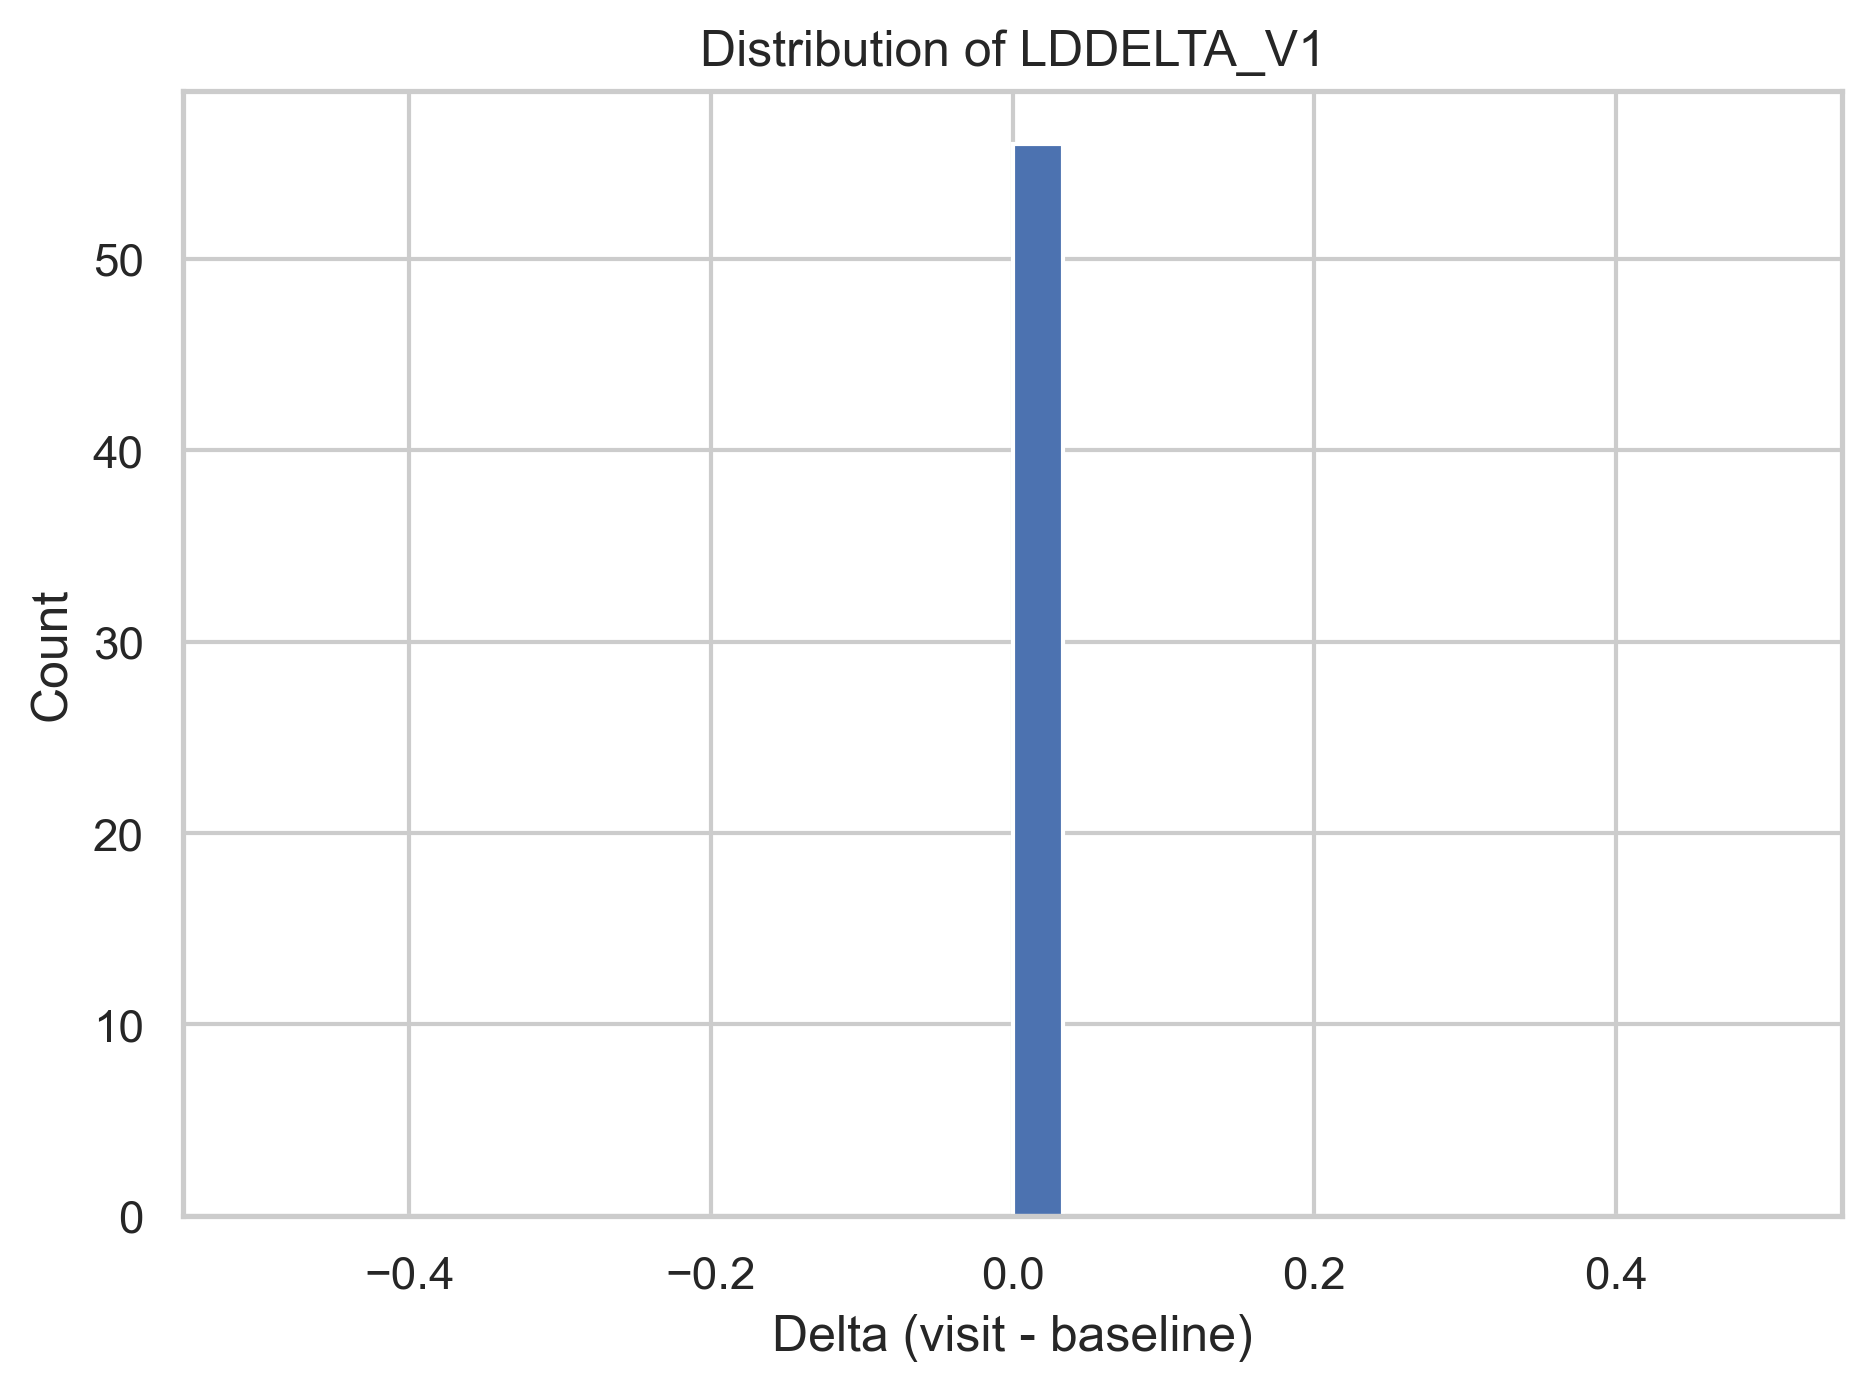

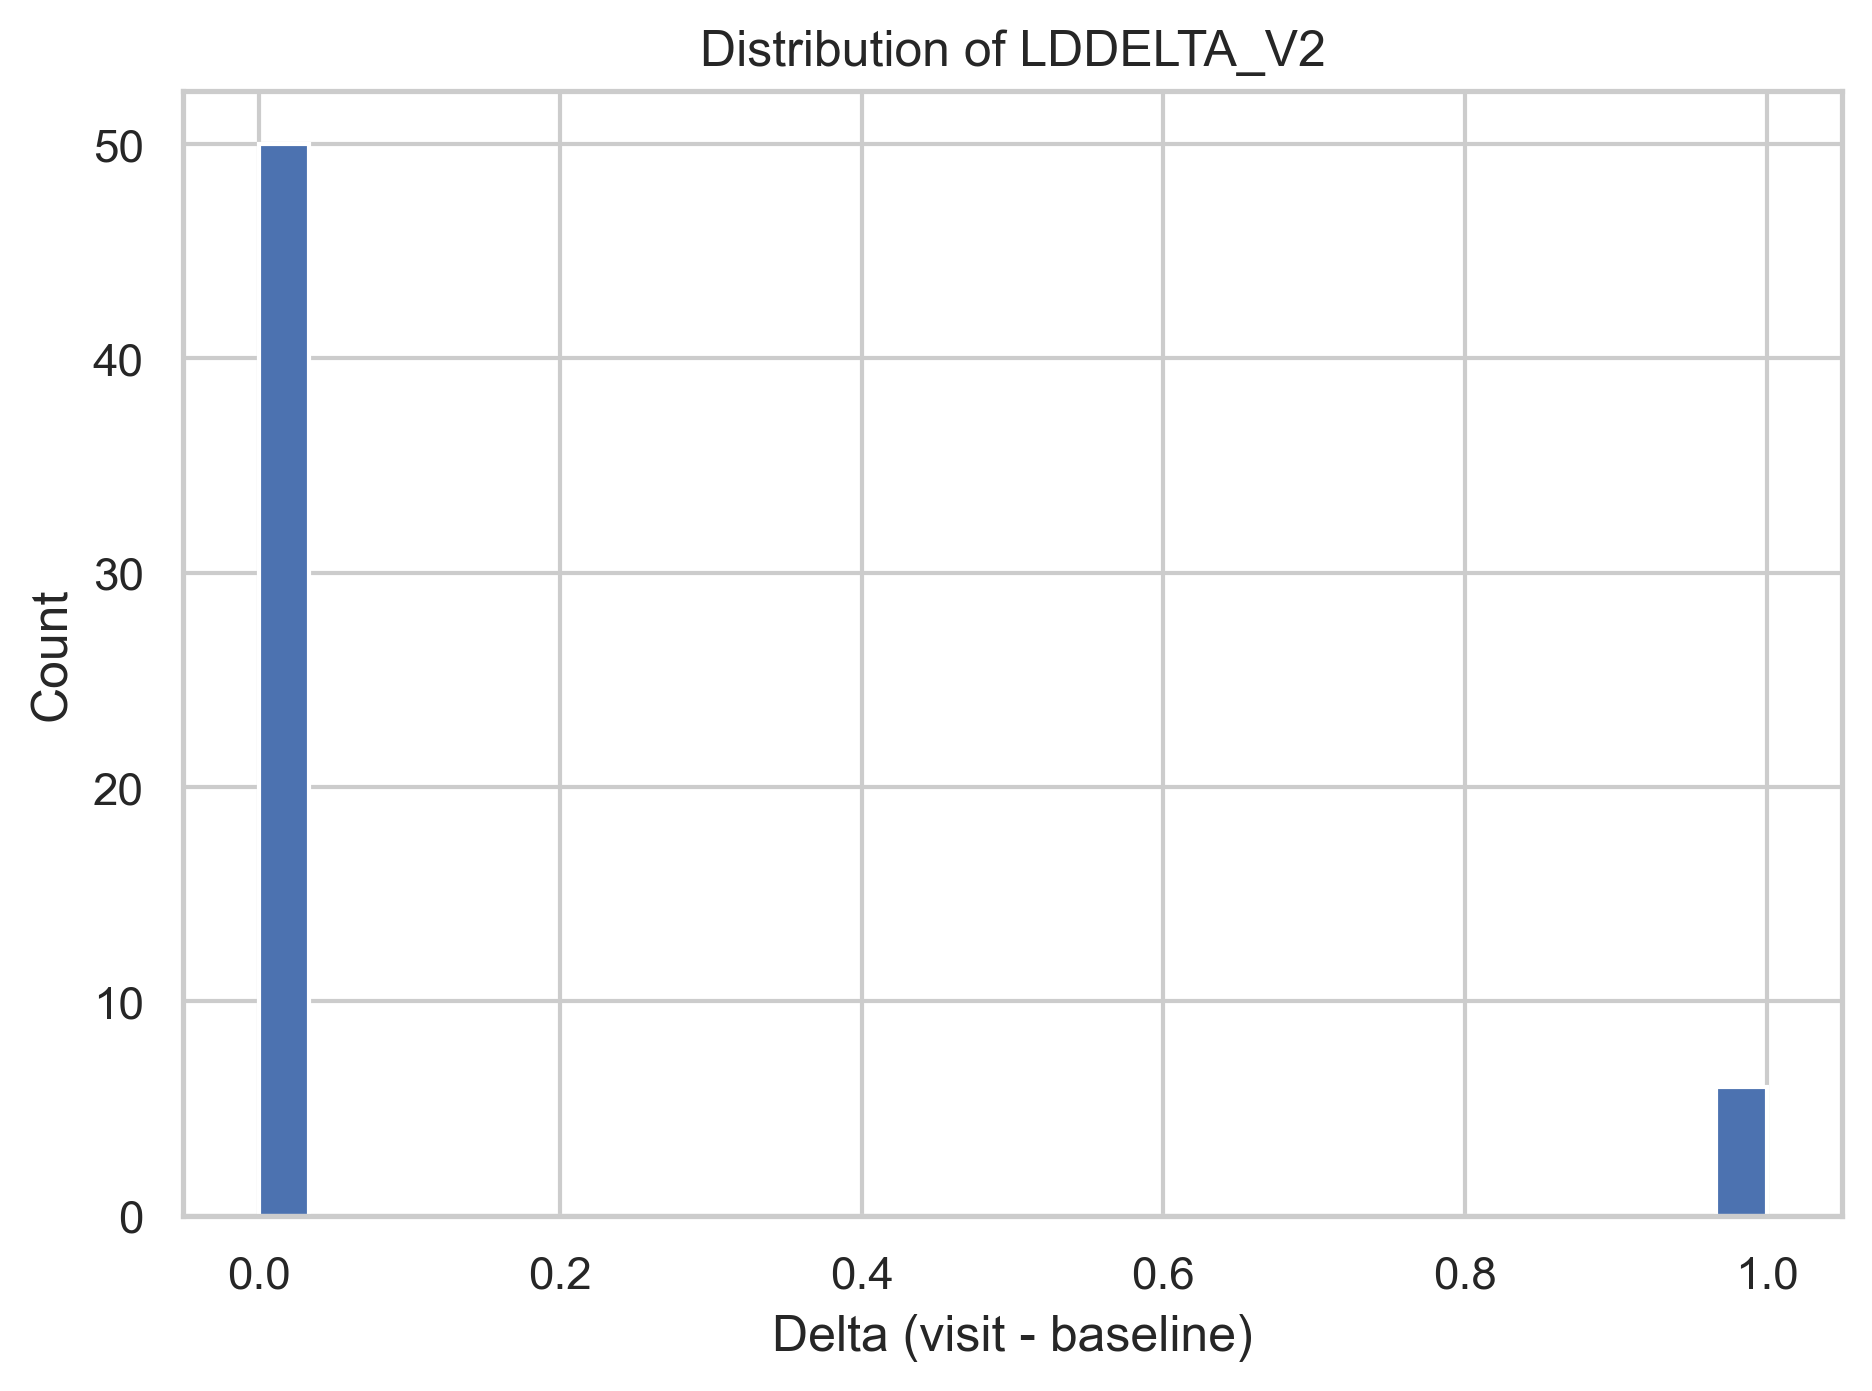

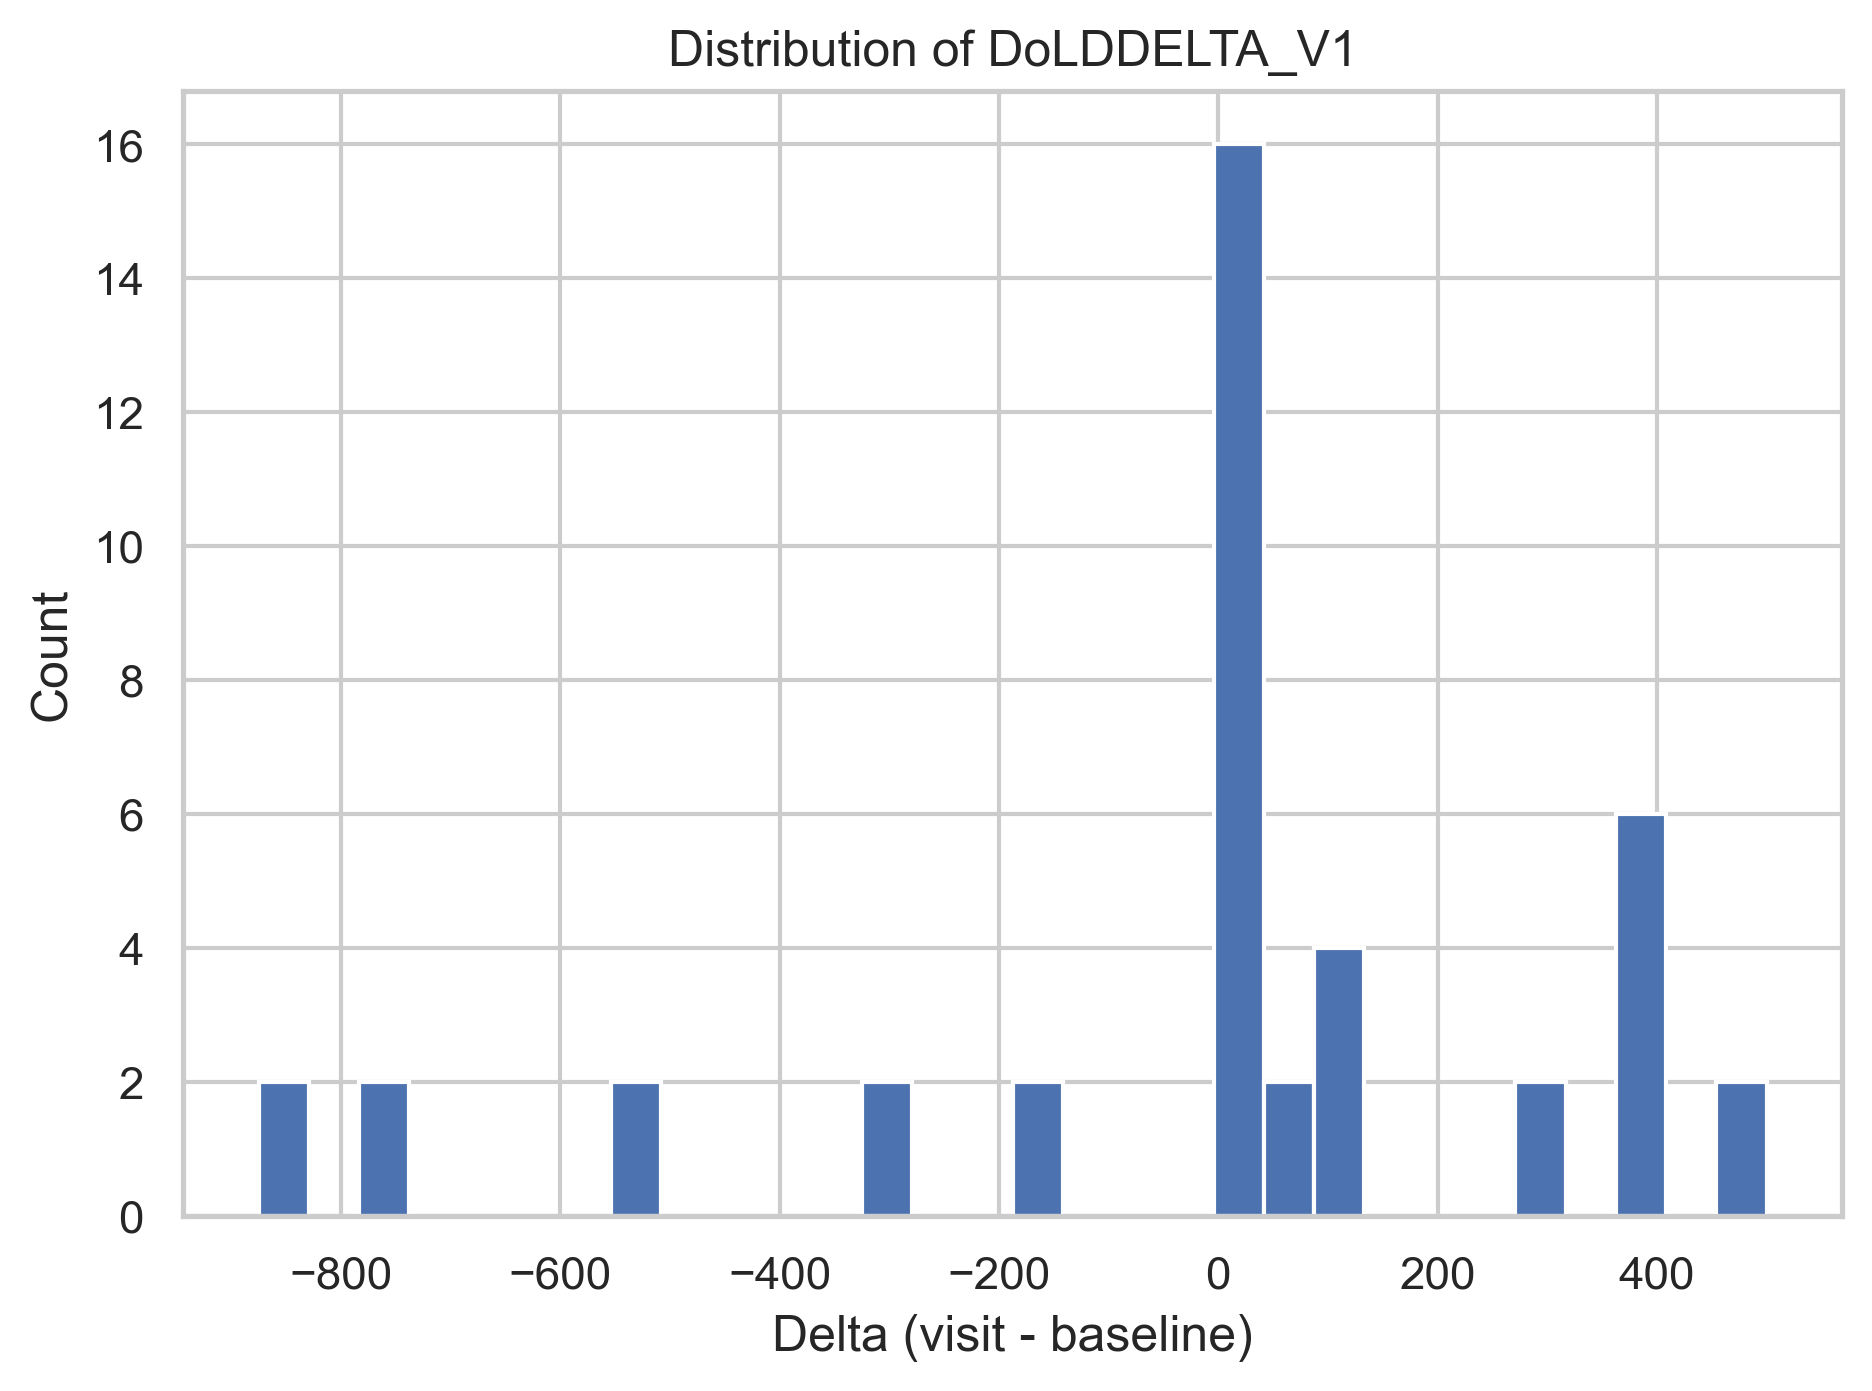

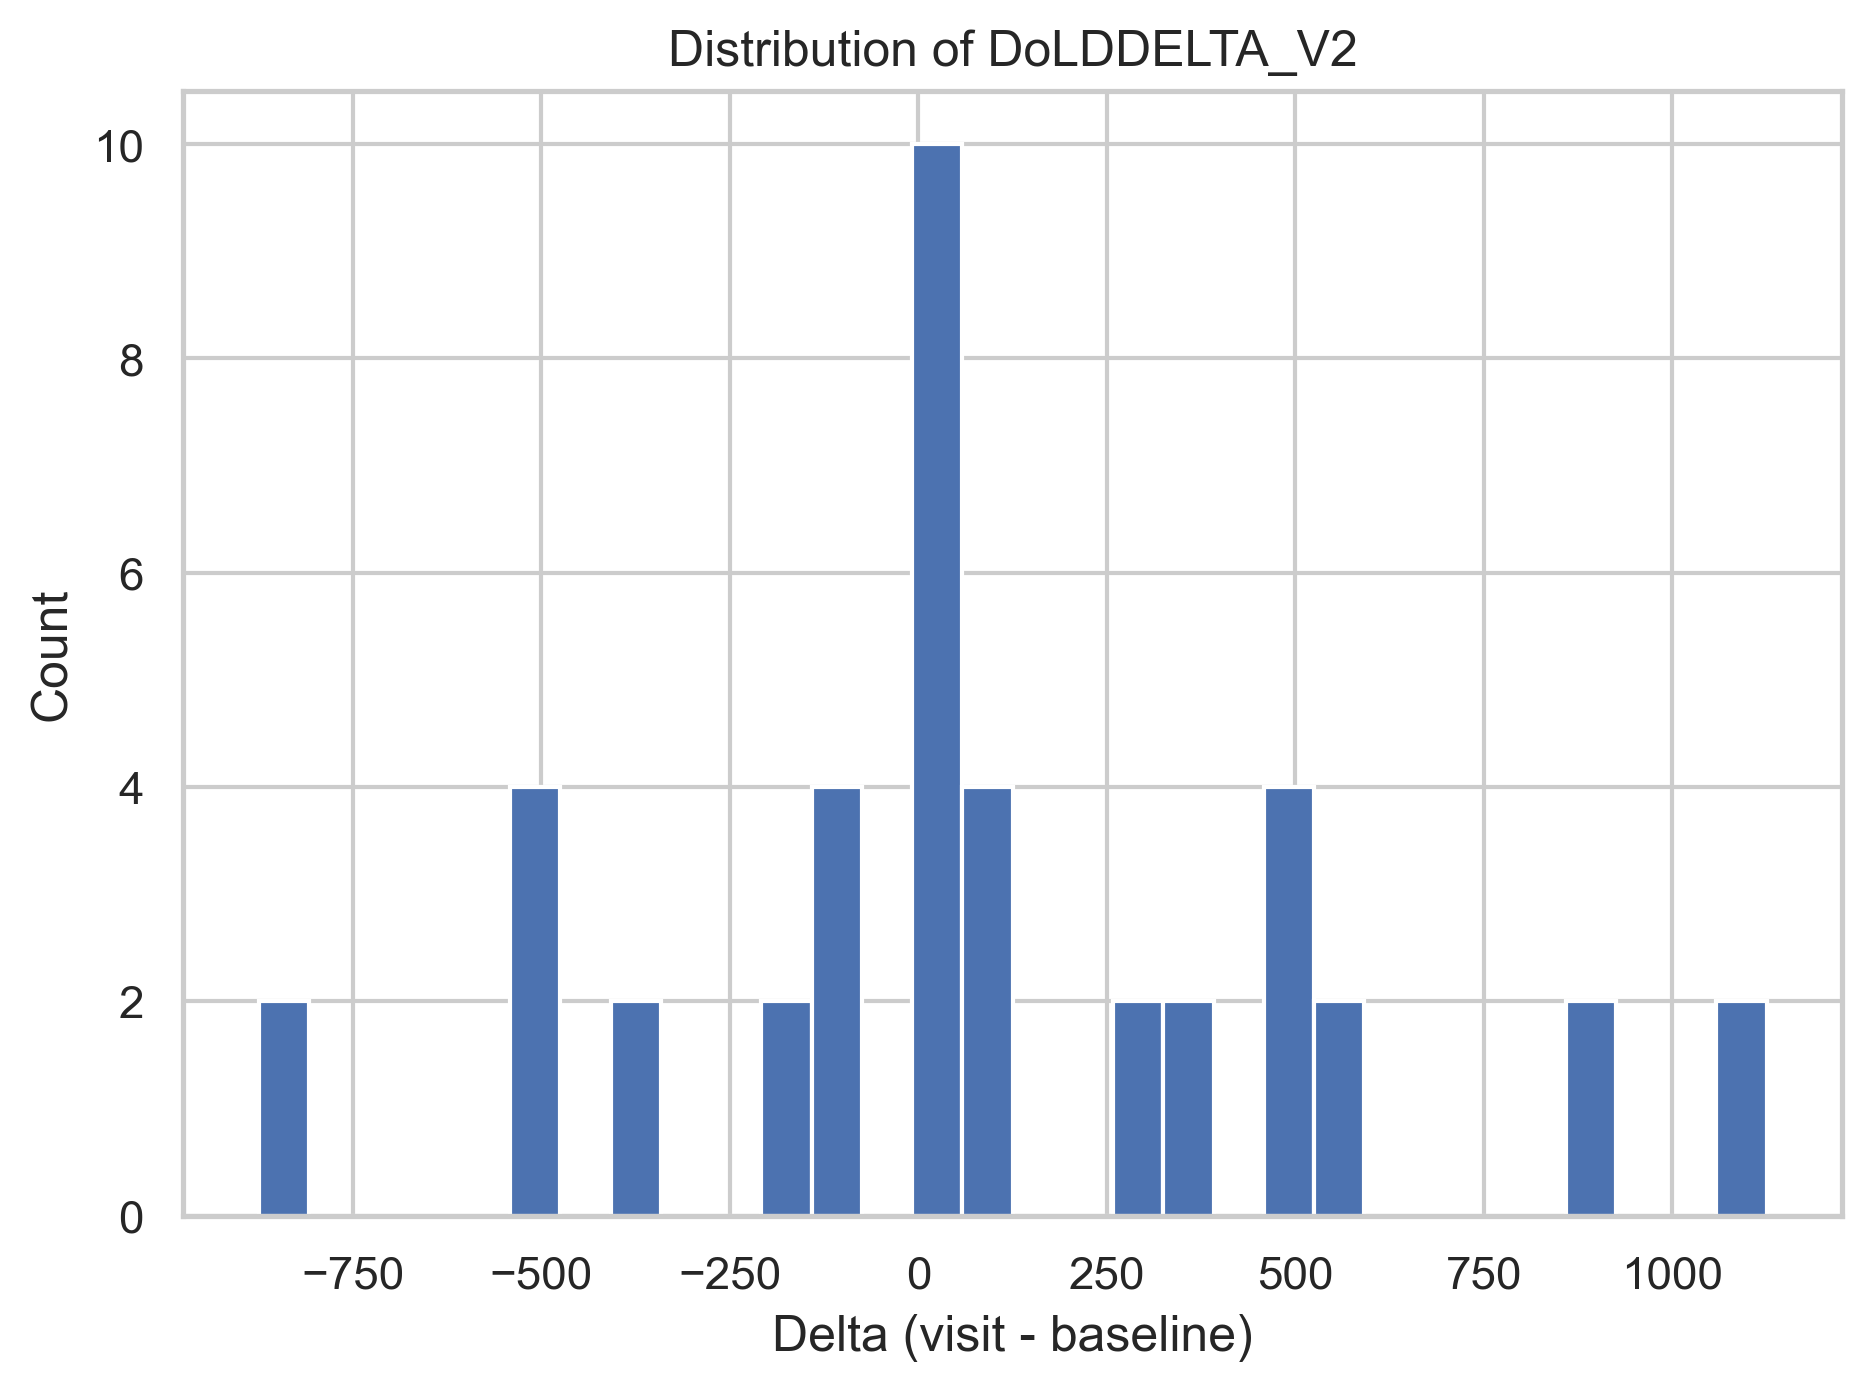

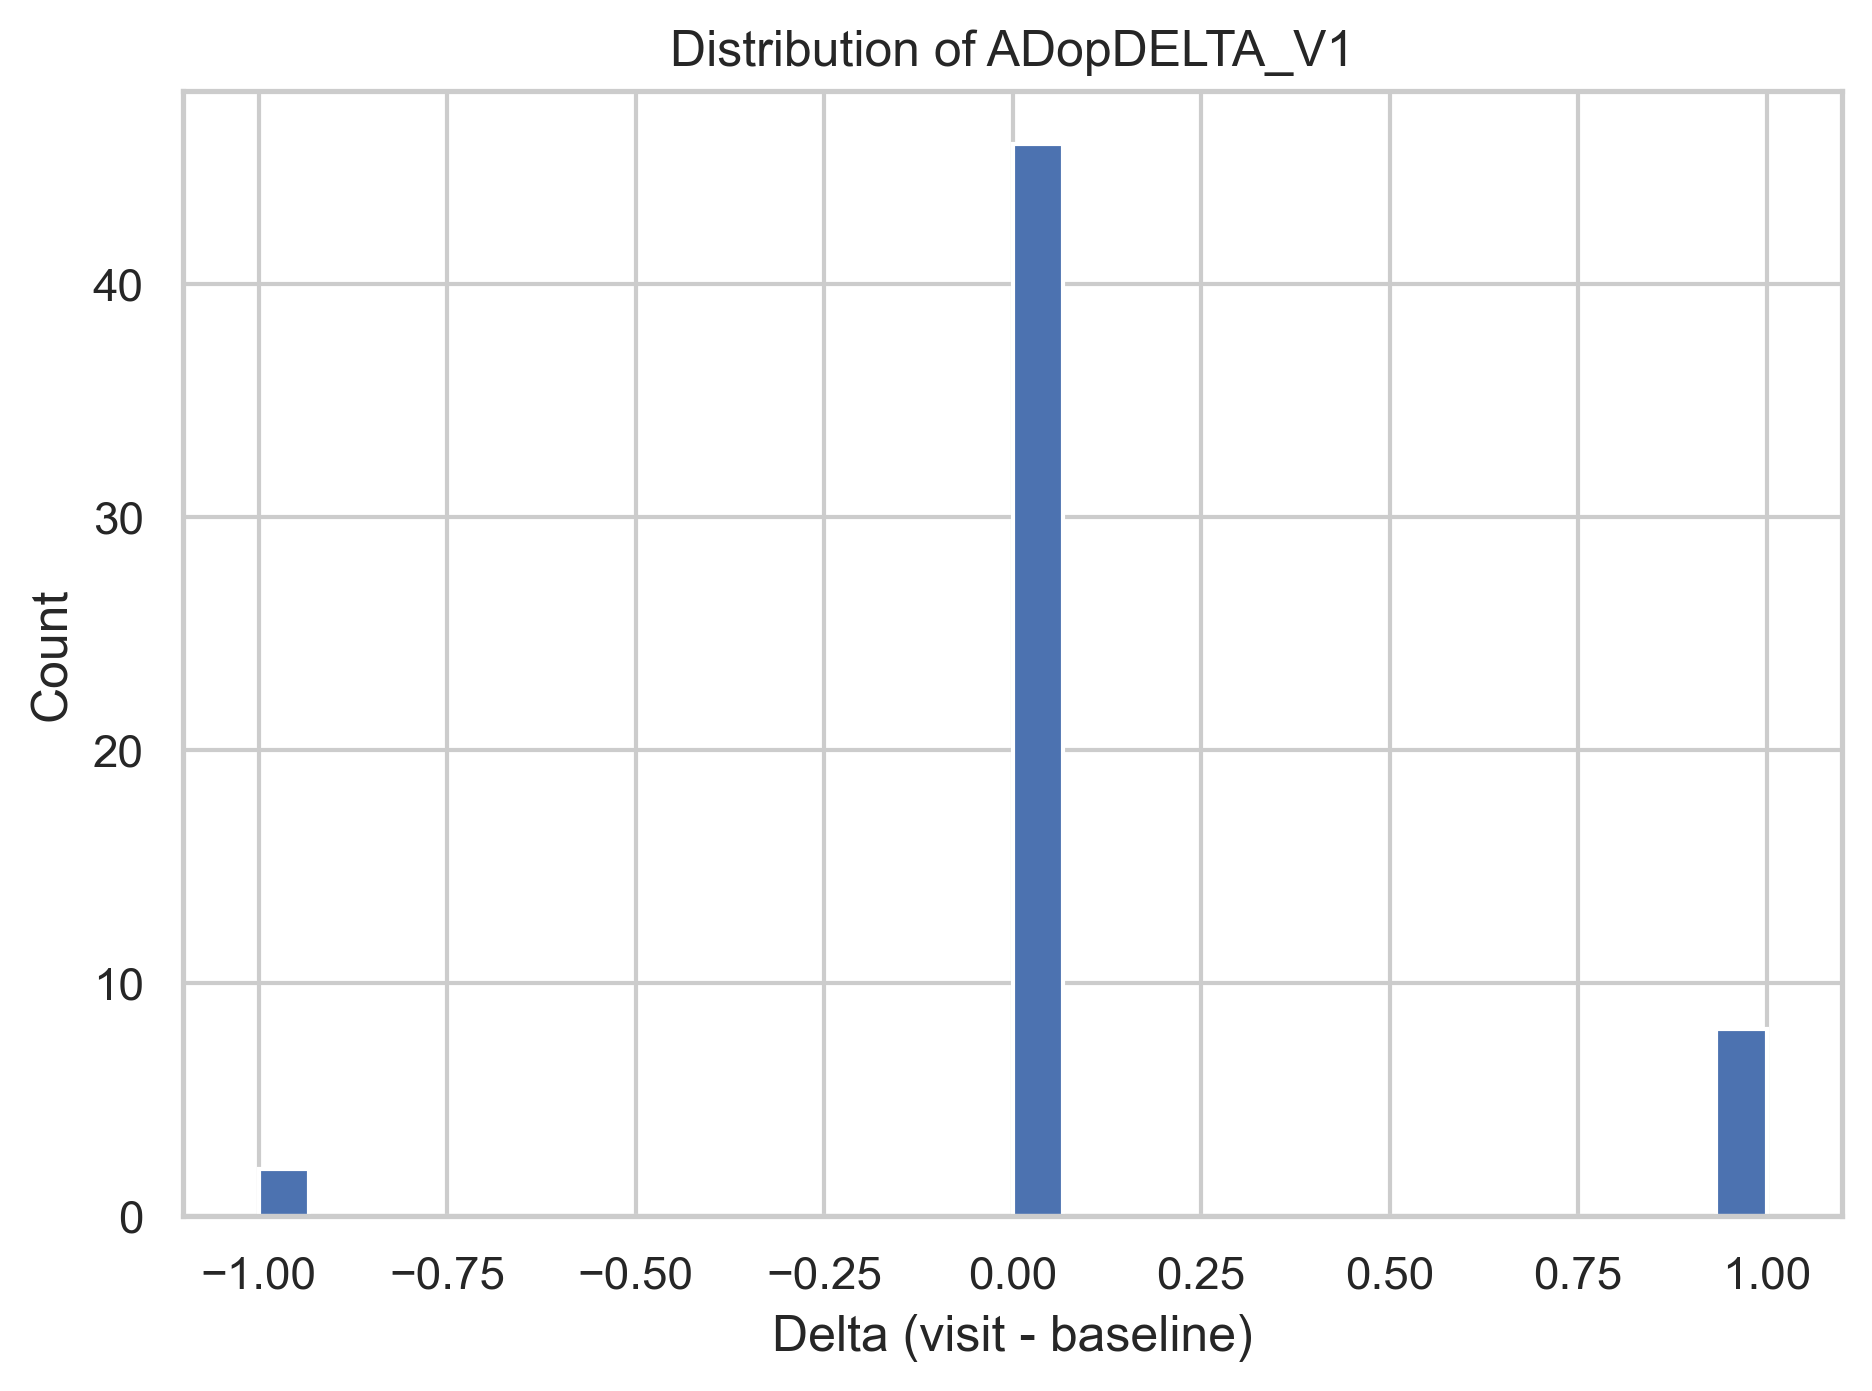

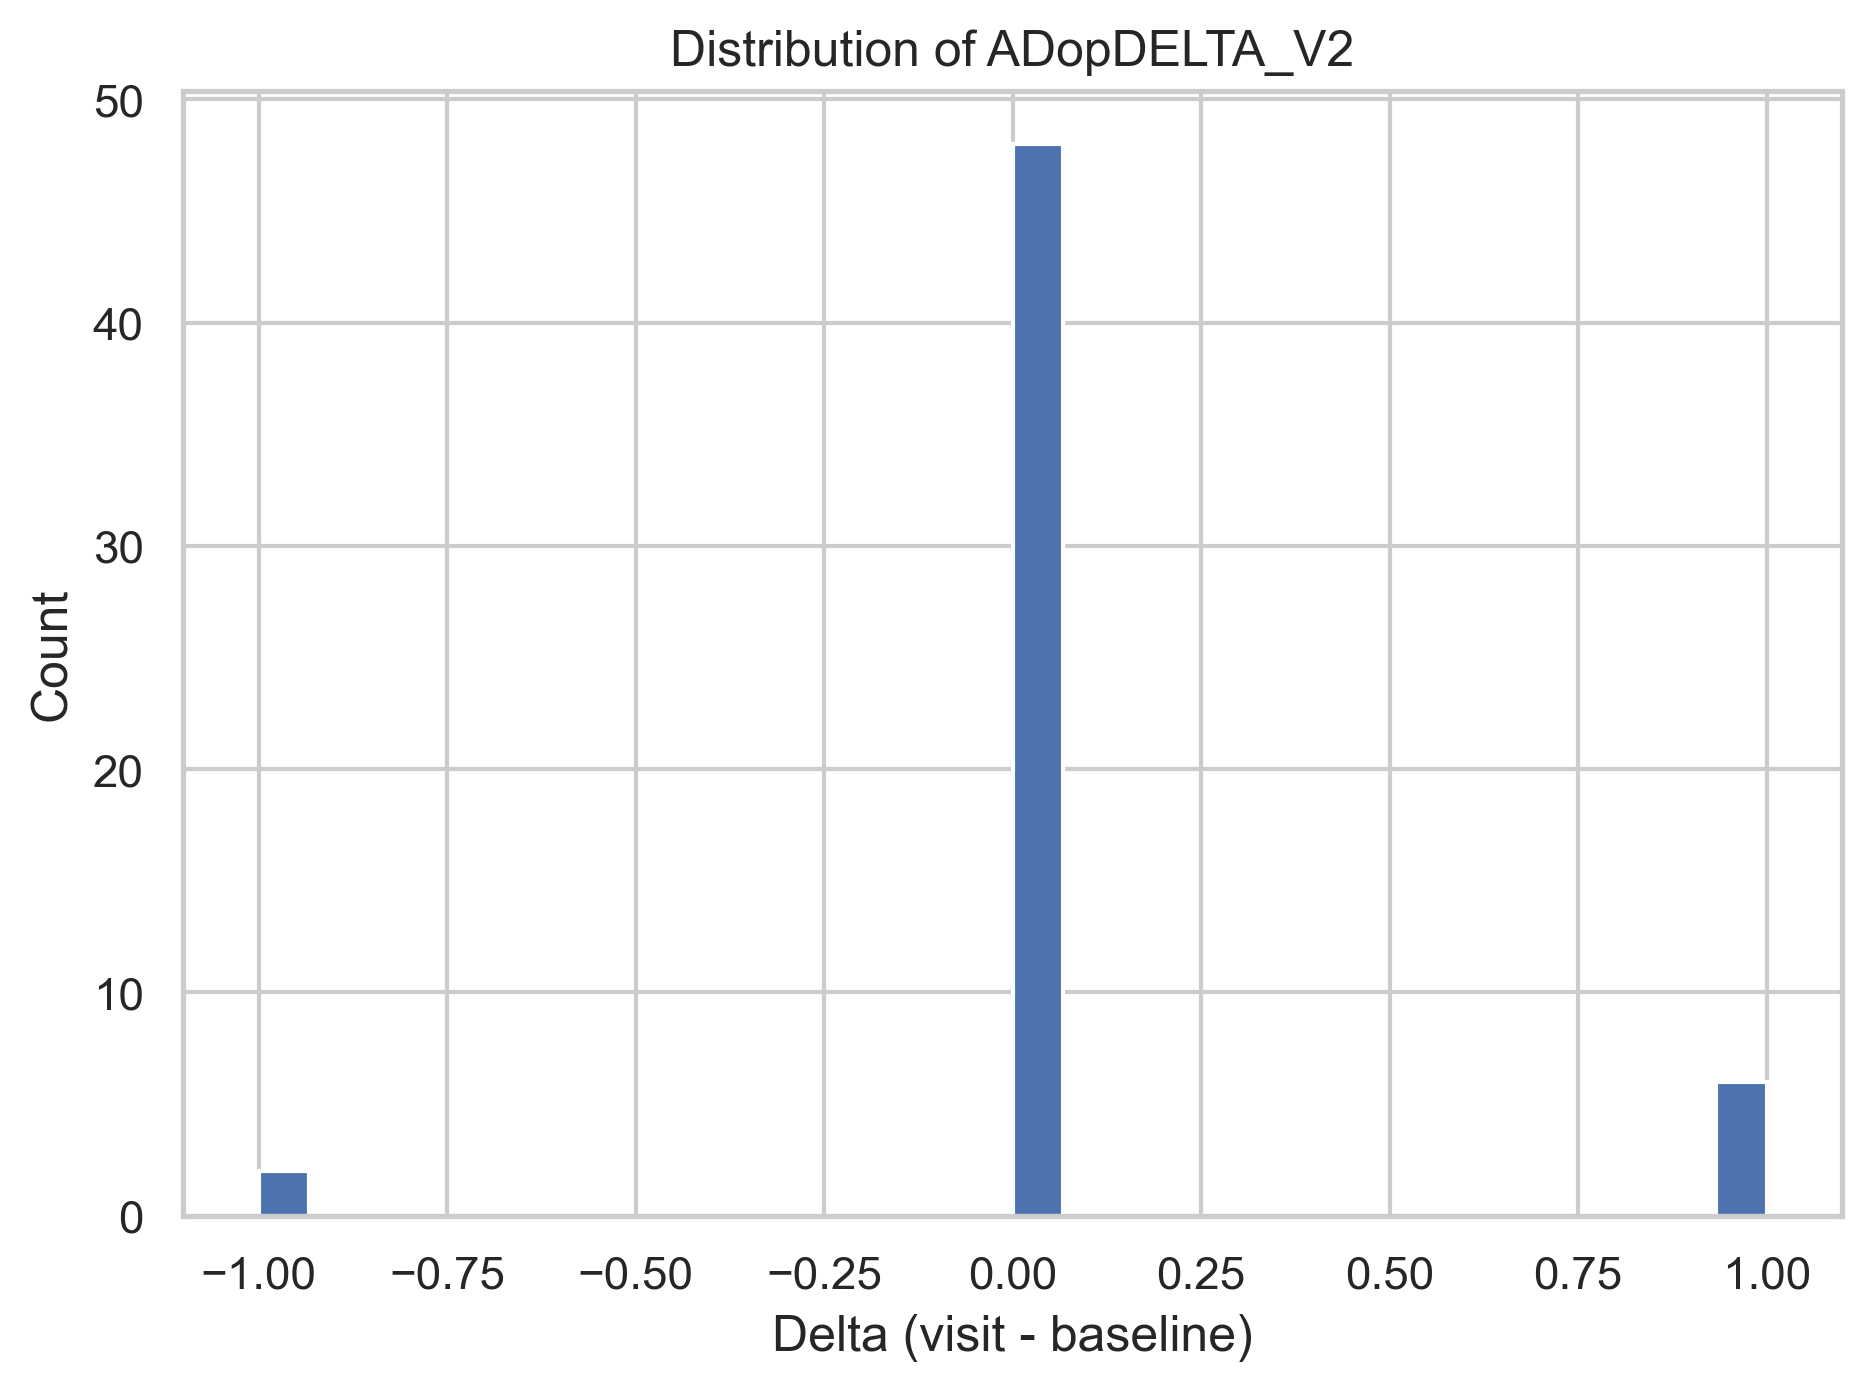

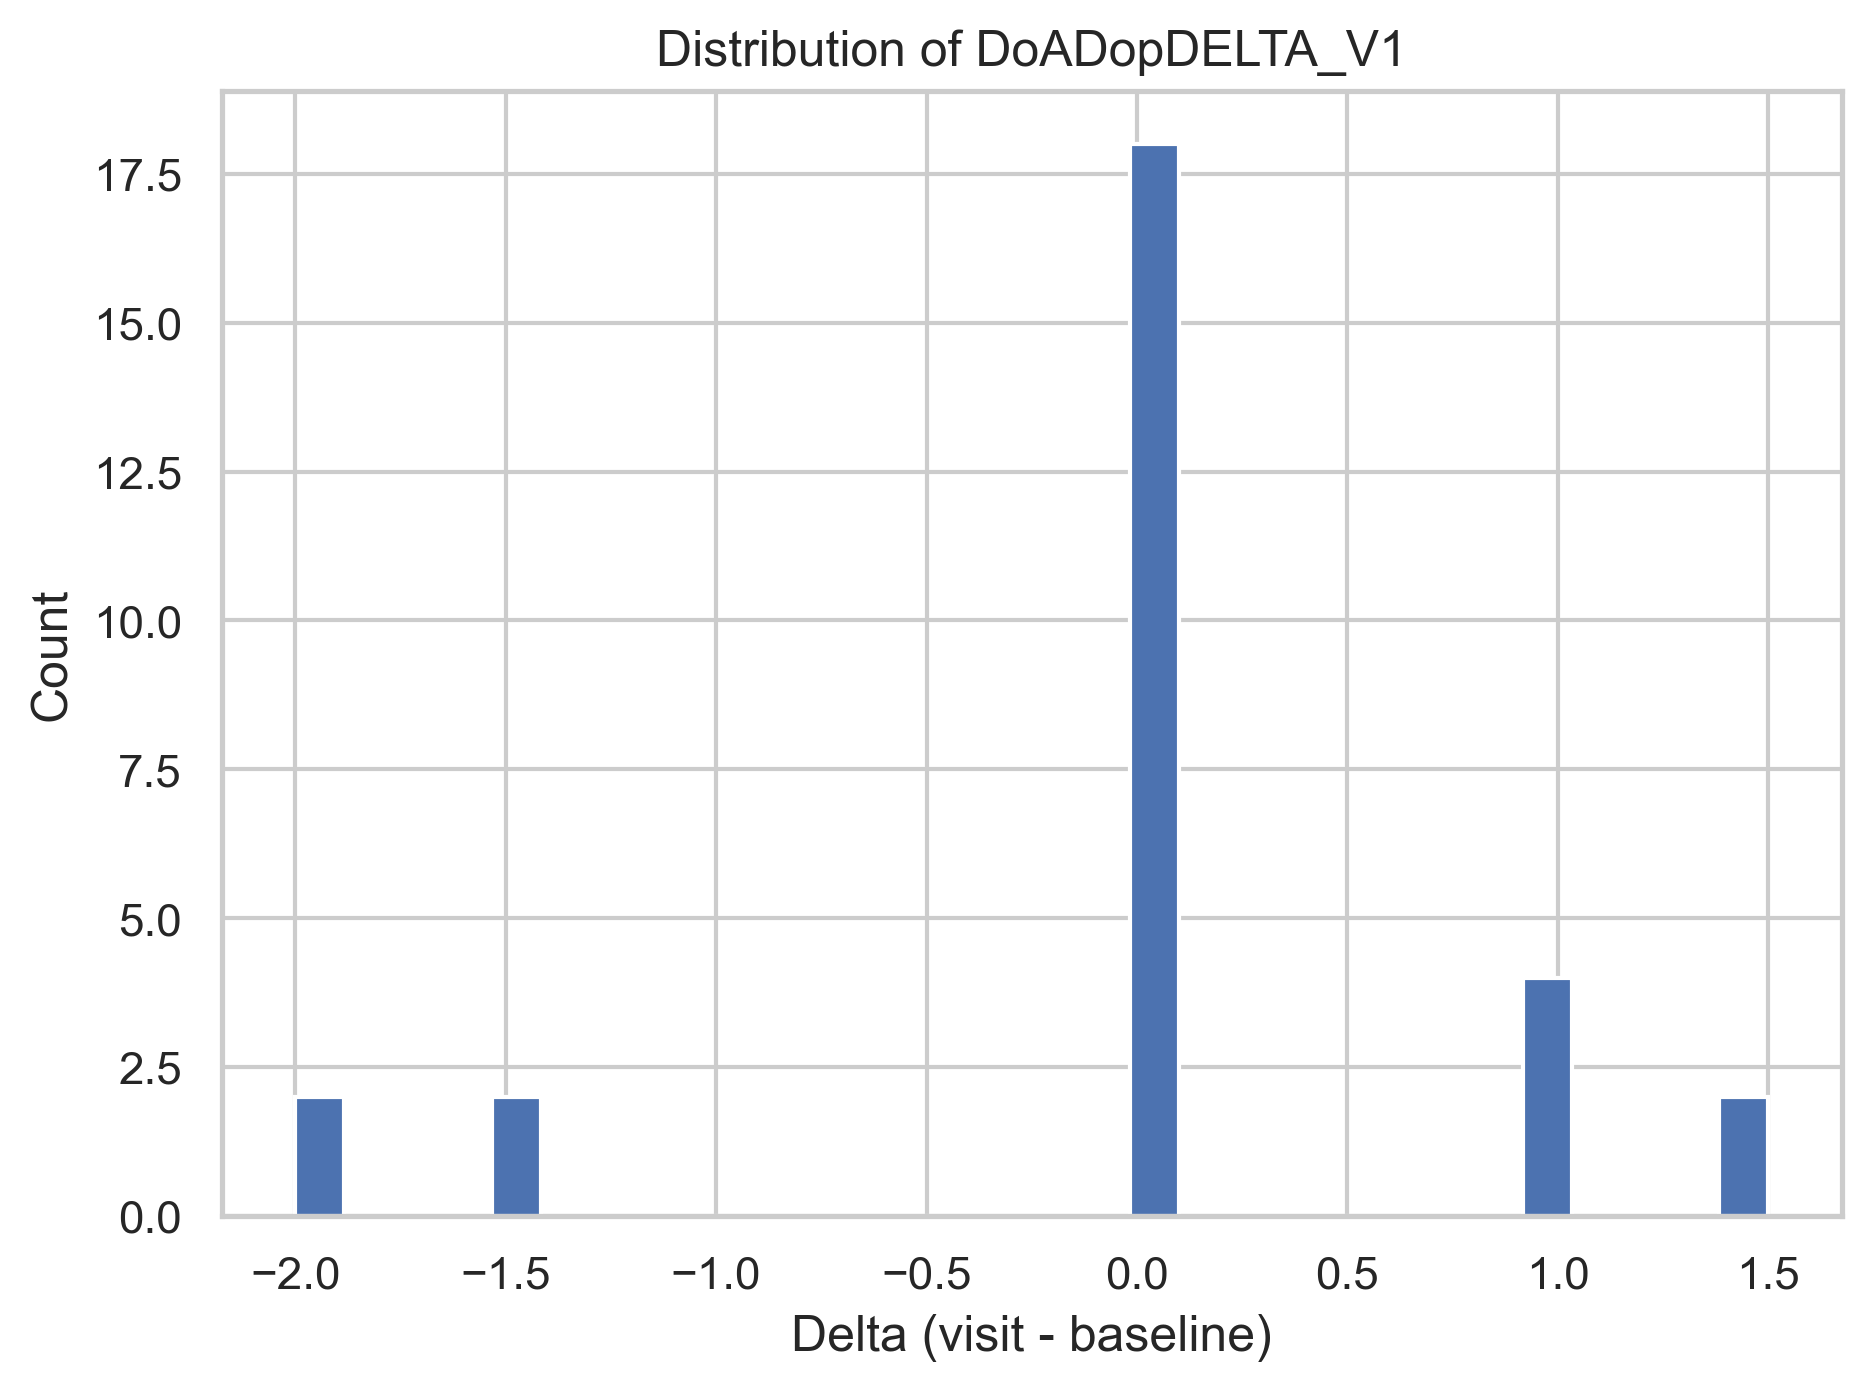

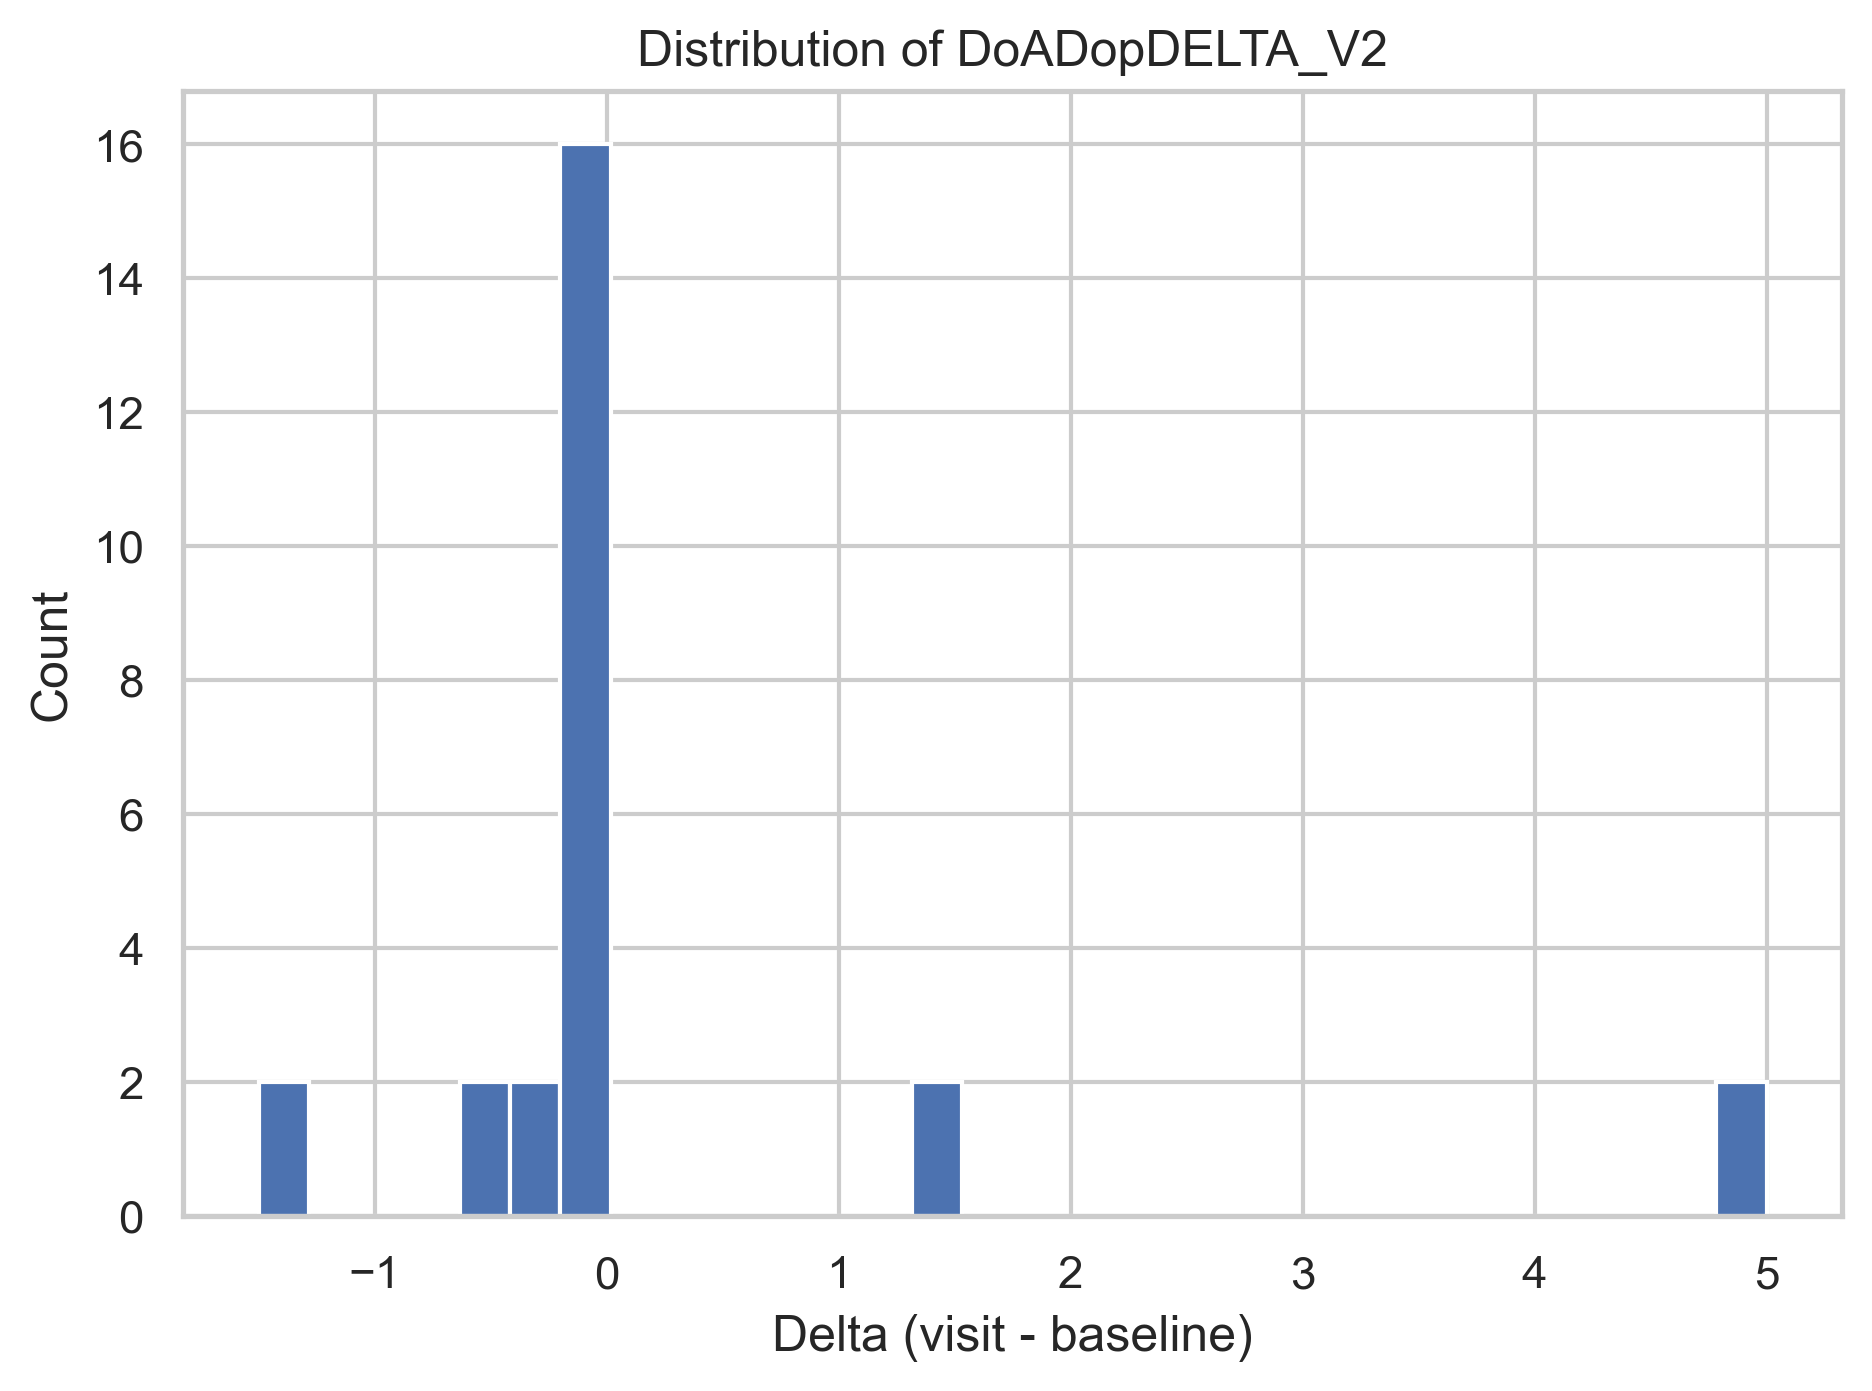

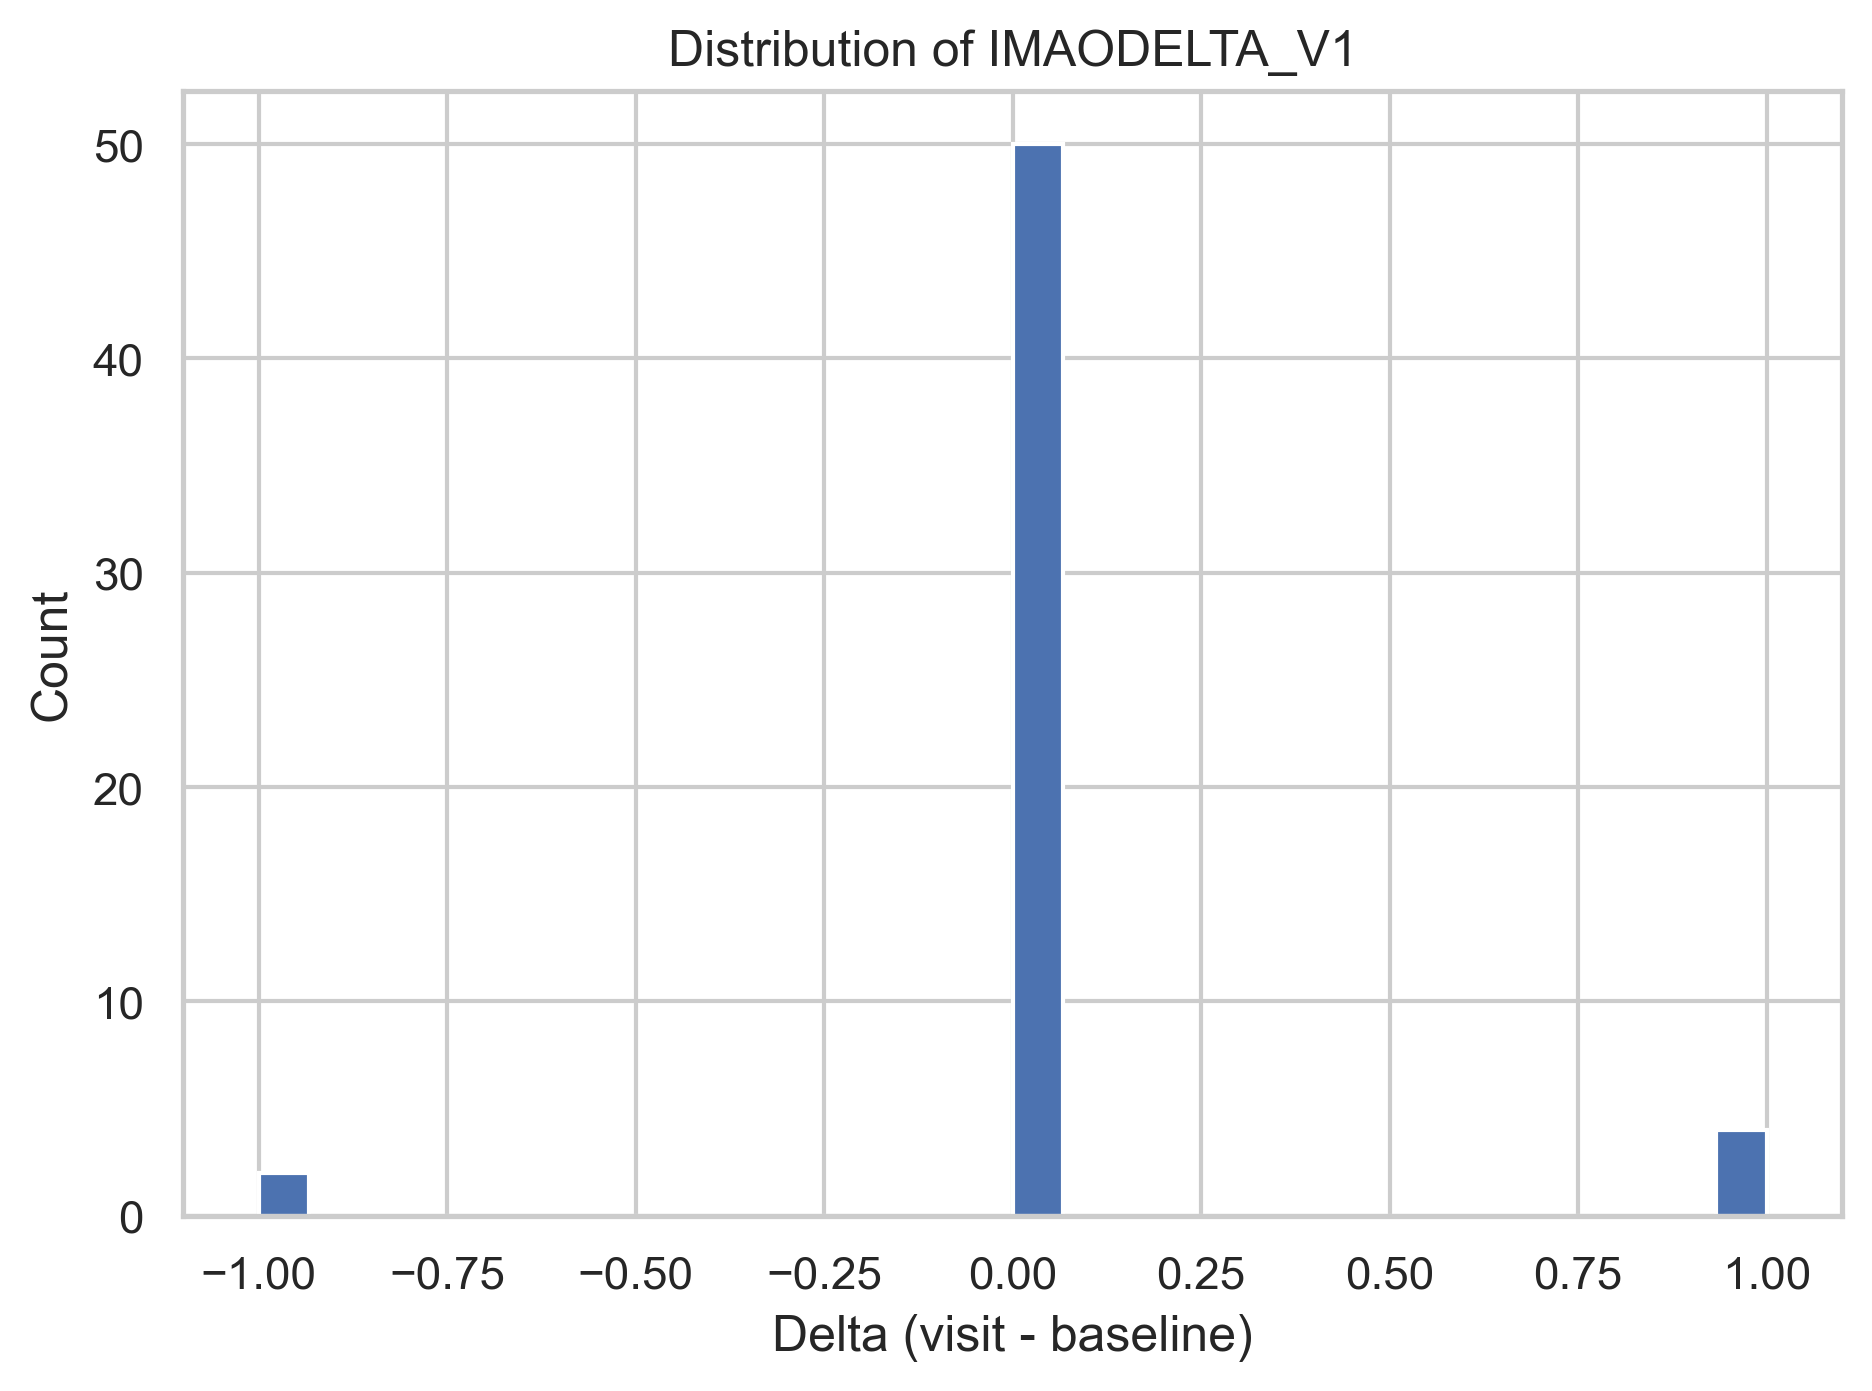

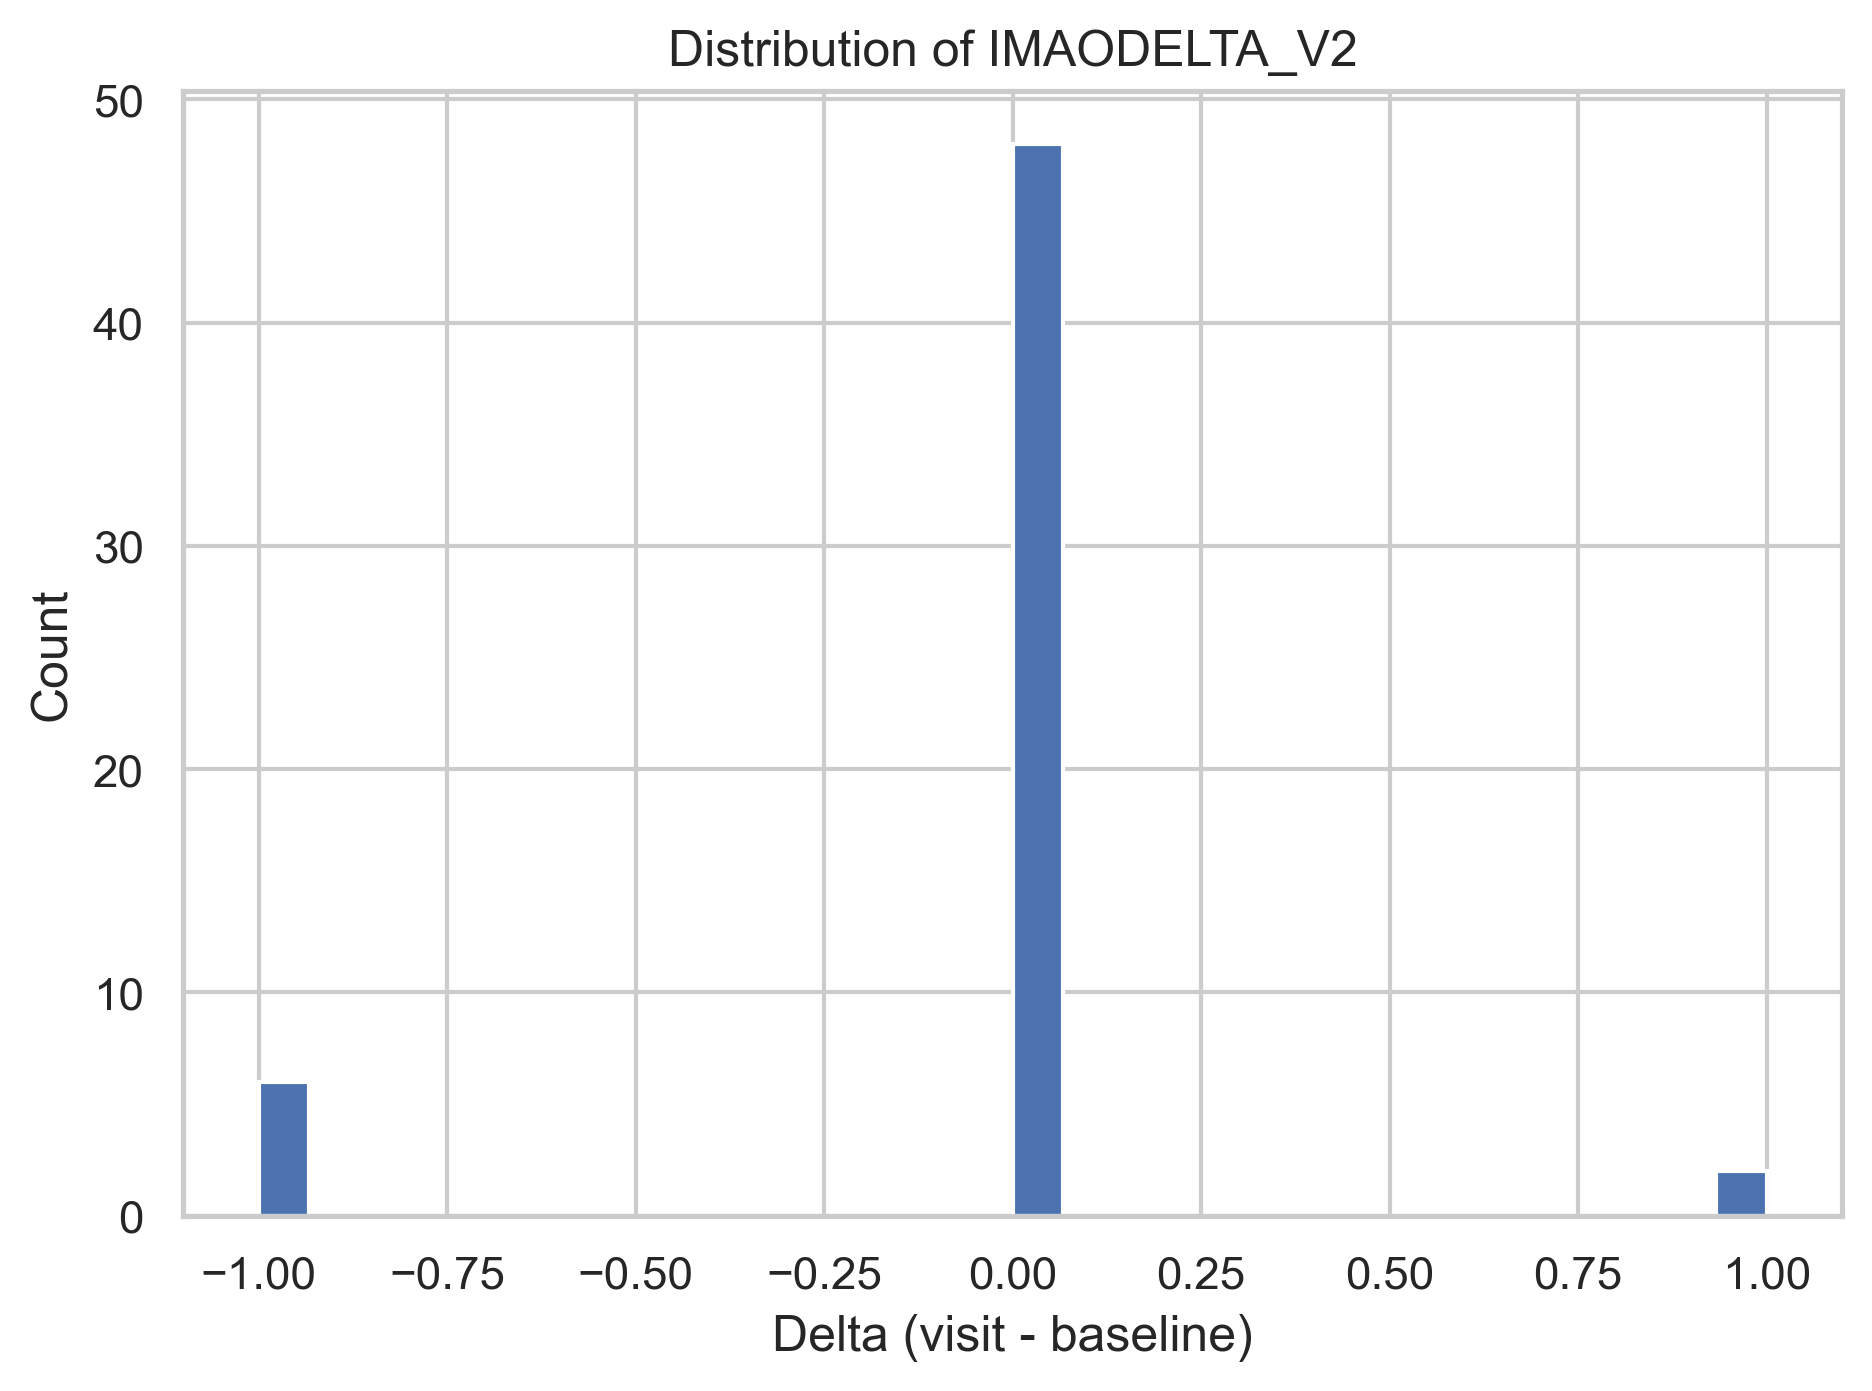

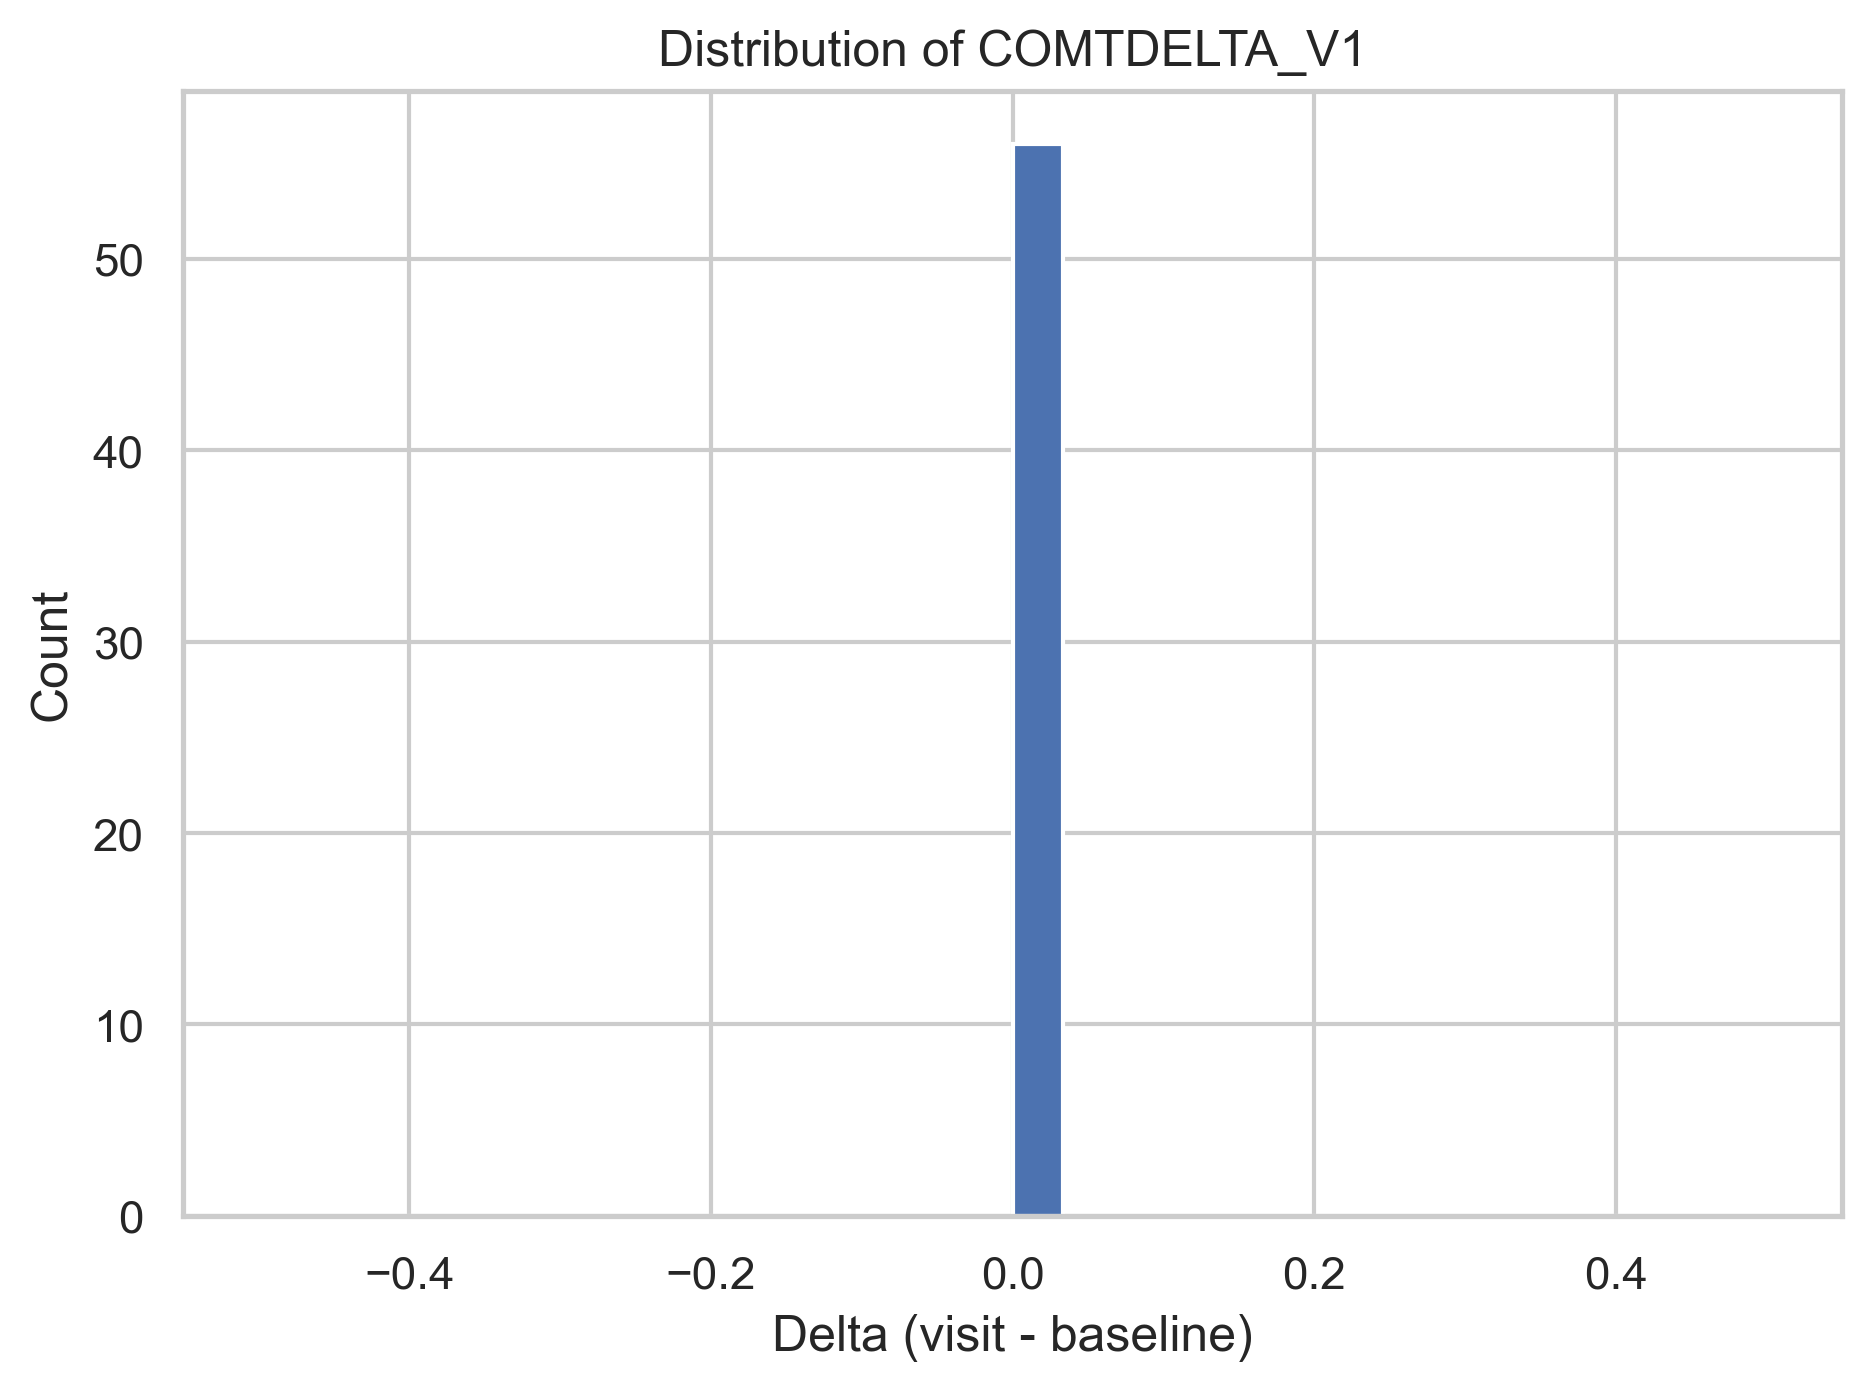

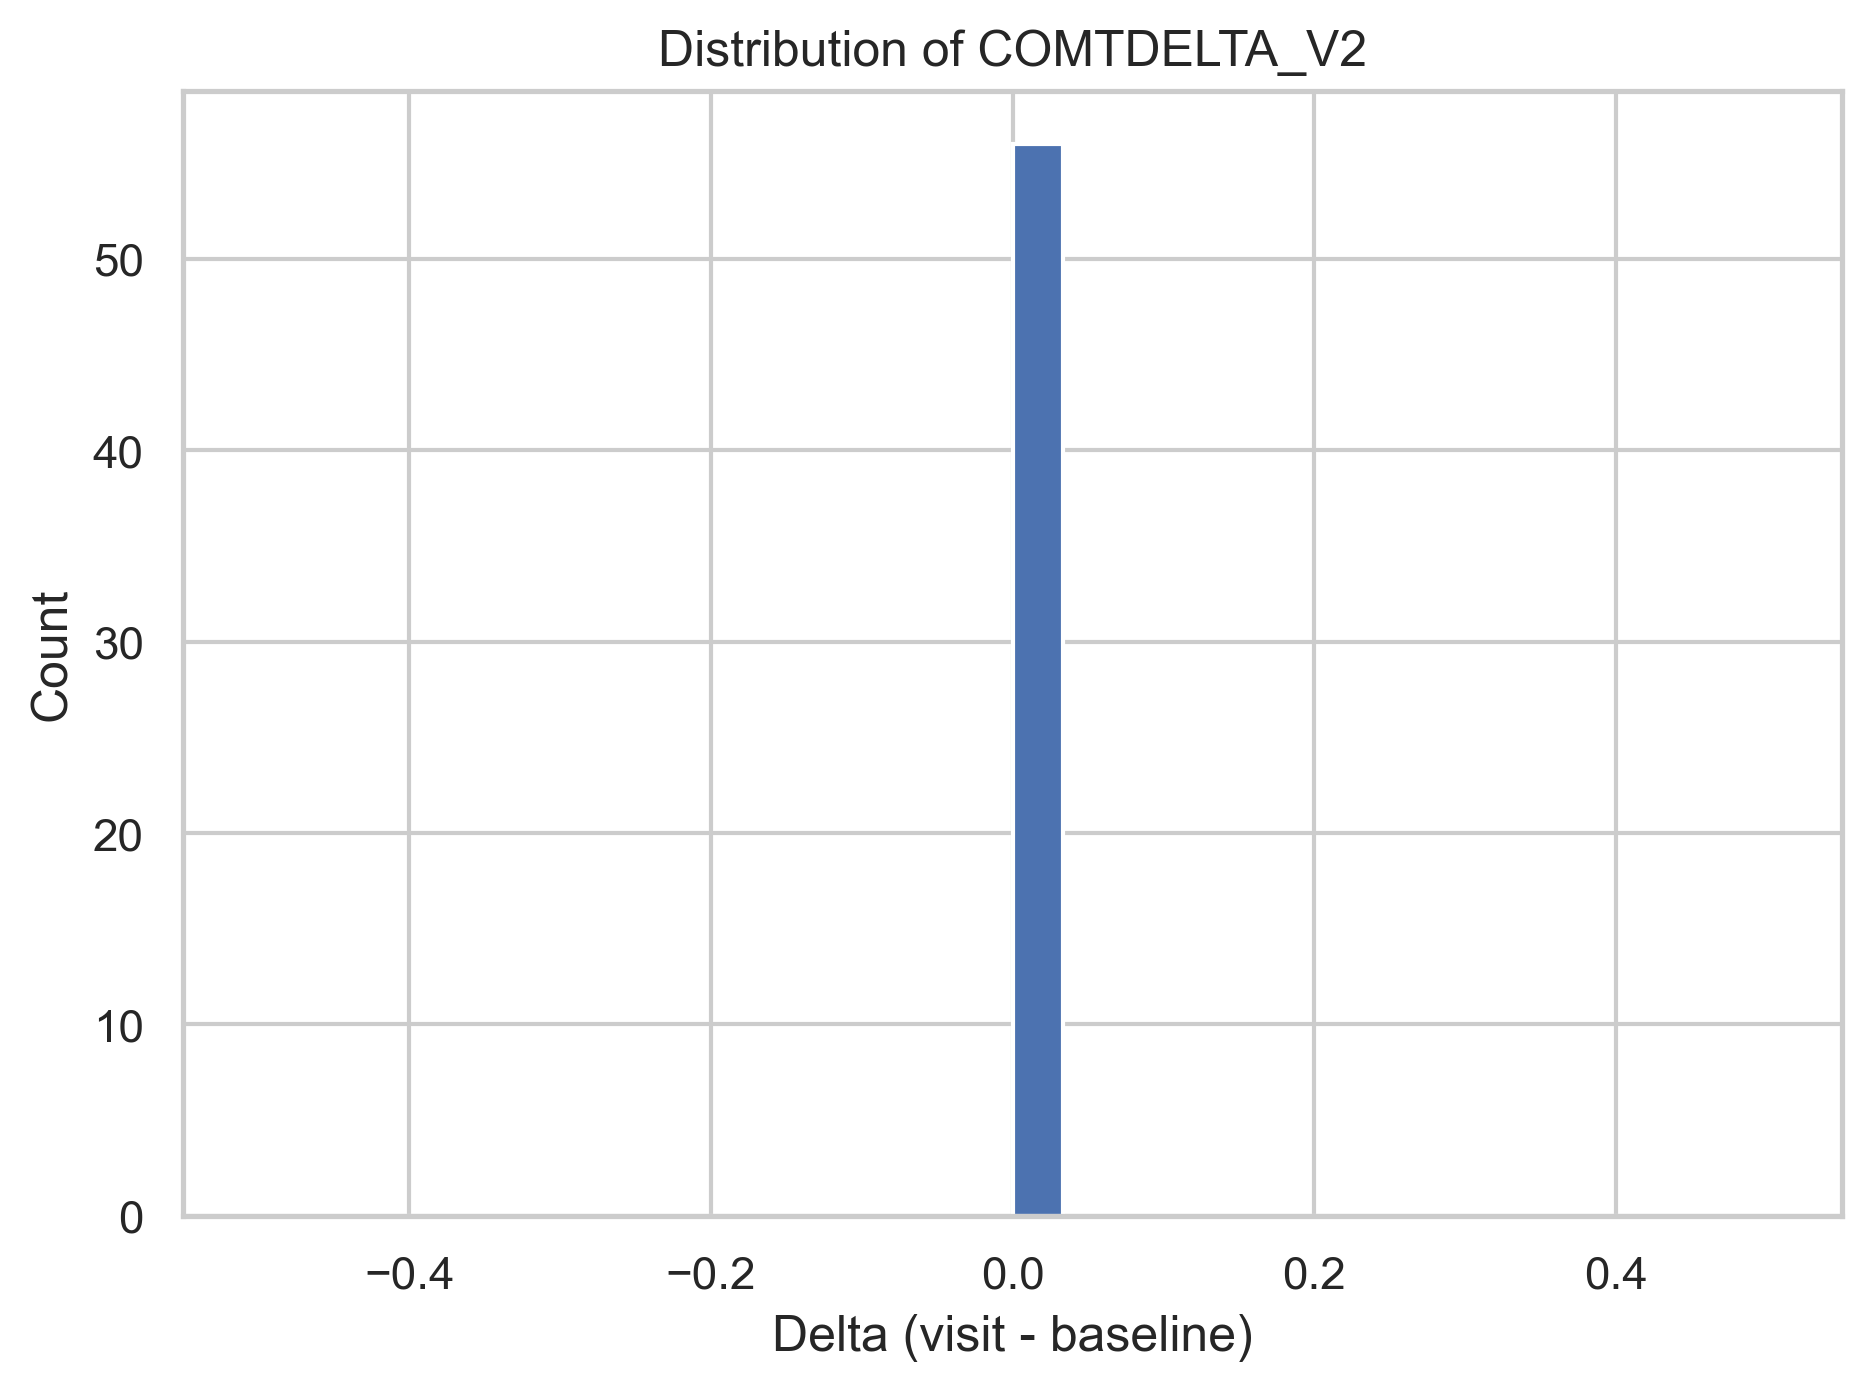

Done. Artifacts in: data/derived and figures


In [10]:
# Example histograms for the first 12 deltas
if not delta_df.empty:
    for col in list(delta_df.columns)[:12]:
        plt.figure()
        plt.hist(delta_df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel("Delta (visit - baseline)")
        plt.ylabel("Count")
        plt.tight_layout()
        fname = f"{OUT_FIGS}/hist_{safe_name(col)}.png"
        plt.savefig(fname)
        plt.show()
        # print("Saved:", fname)
else:
    print("No deltas to plot.")

print("Done. Artifacts in:", OUT_DERIVED, "and", OUT_FIGS)

<div id="screen" class="toc-anchor"></div>

## Feature selection (P1 / Pv0) + RF & ANOVA-F (with combined score)

=== All features ranked by Combined score ===


,RandomForestImportance,ANOVA_F_Score,ANOVA_pvalue,RF_norm,F_norm,Combined
PapPInfEPv0,0.084864,10.348416,0.002192,1.000000,1.000000,1.000000
PapDInfEPv0,0.038534,10.307187,0.002233,0.454071,0.996016,0.725043
PapDIntEPv0,0.019977,5.447421,0.023348,0.235398,0.526401,0.380900
DtotP1,0.043310,2.081421,0.154877,0.510346,0.201134,0.355740
PENasalP1,0.053514,0.132244,0.717536,0.630592,0.012779,0.321686
PapCircEPv0,0.025545,3.120728,0.082954,0.301018,0.301566,0.301292
PapDNasEPv0,0.020497,3.684307,0.060217,0.241529,0.356026,0.298778
PIinfP1,0.028492,2.087616,0.154276,0.335741,0.201733,0.268737
DINasP1,0.026767,2.182109,0.145432,0.315417,0.210864,0.263141
PapPNasEPv0,0.030320,1.725512,0.194539,0.357274,0.166742,0.262008


Saved: data/derived/feature_screening_P1_Pv0_RF_ANOVAF.csv


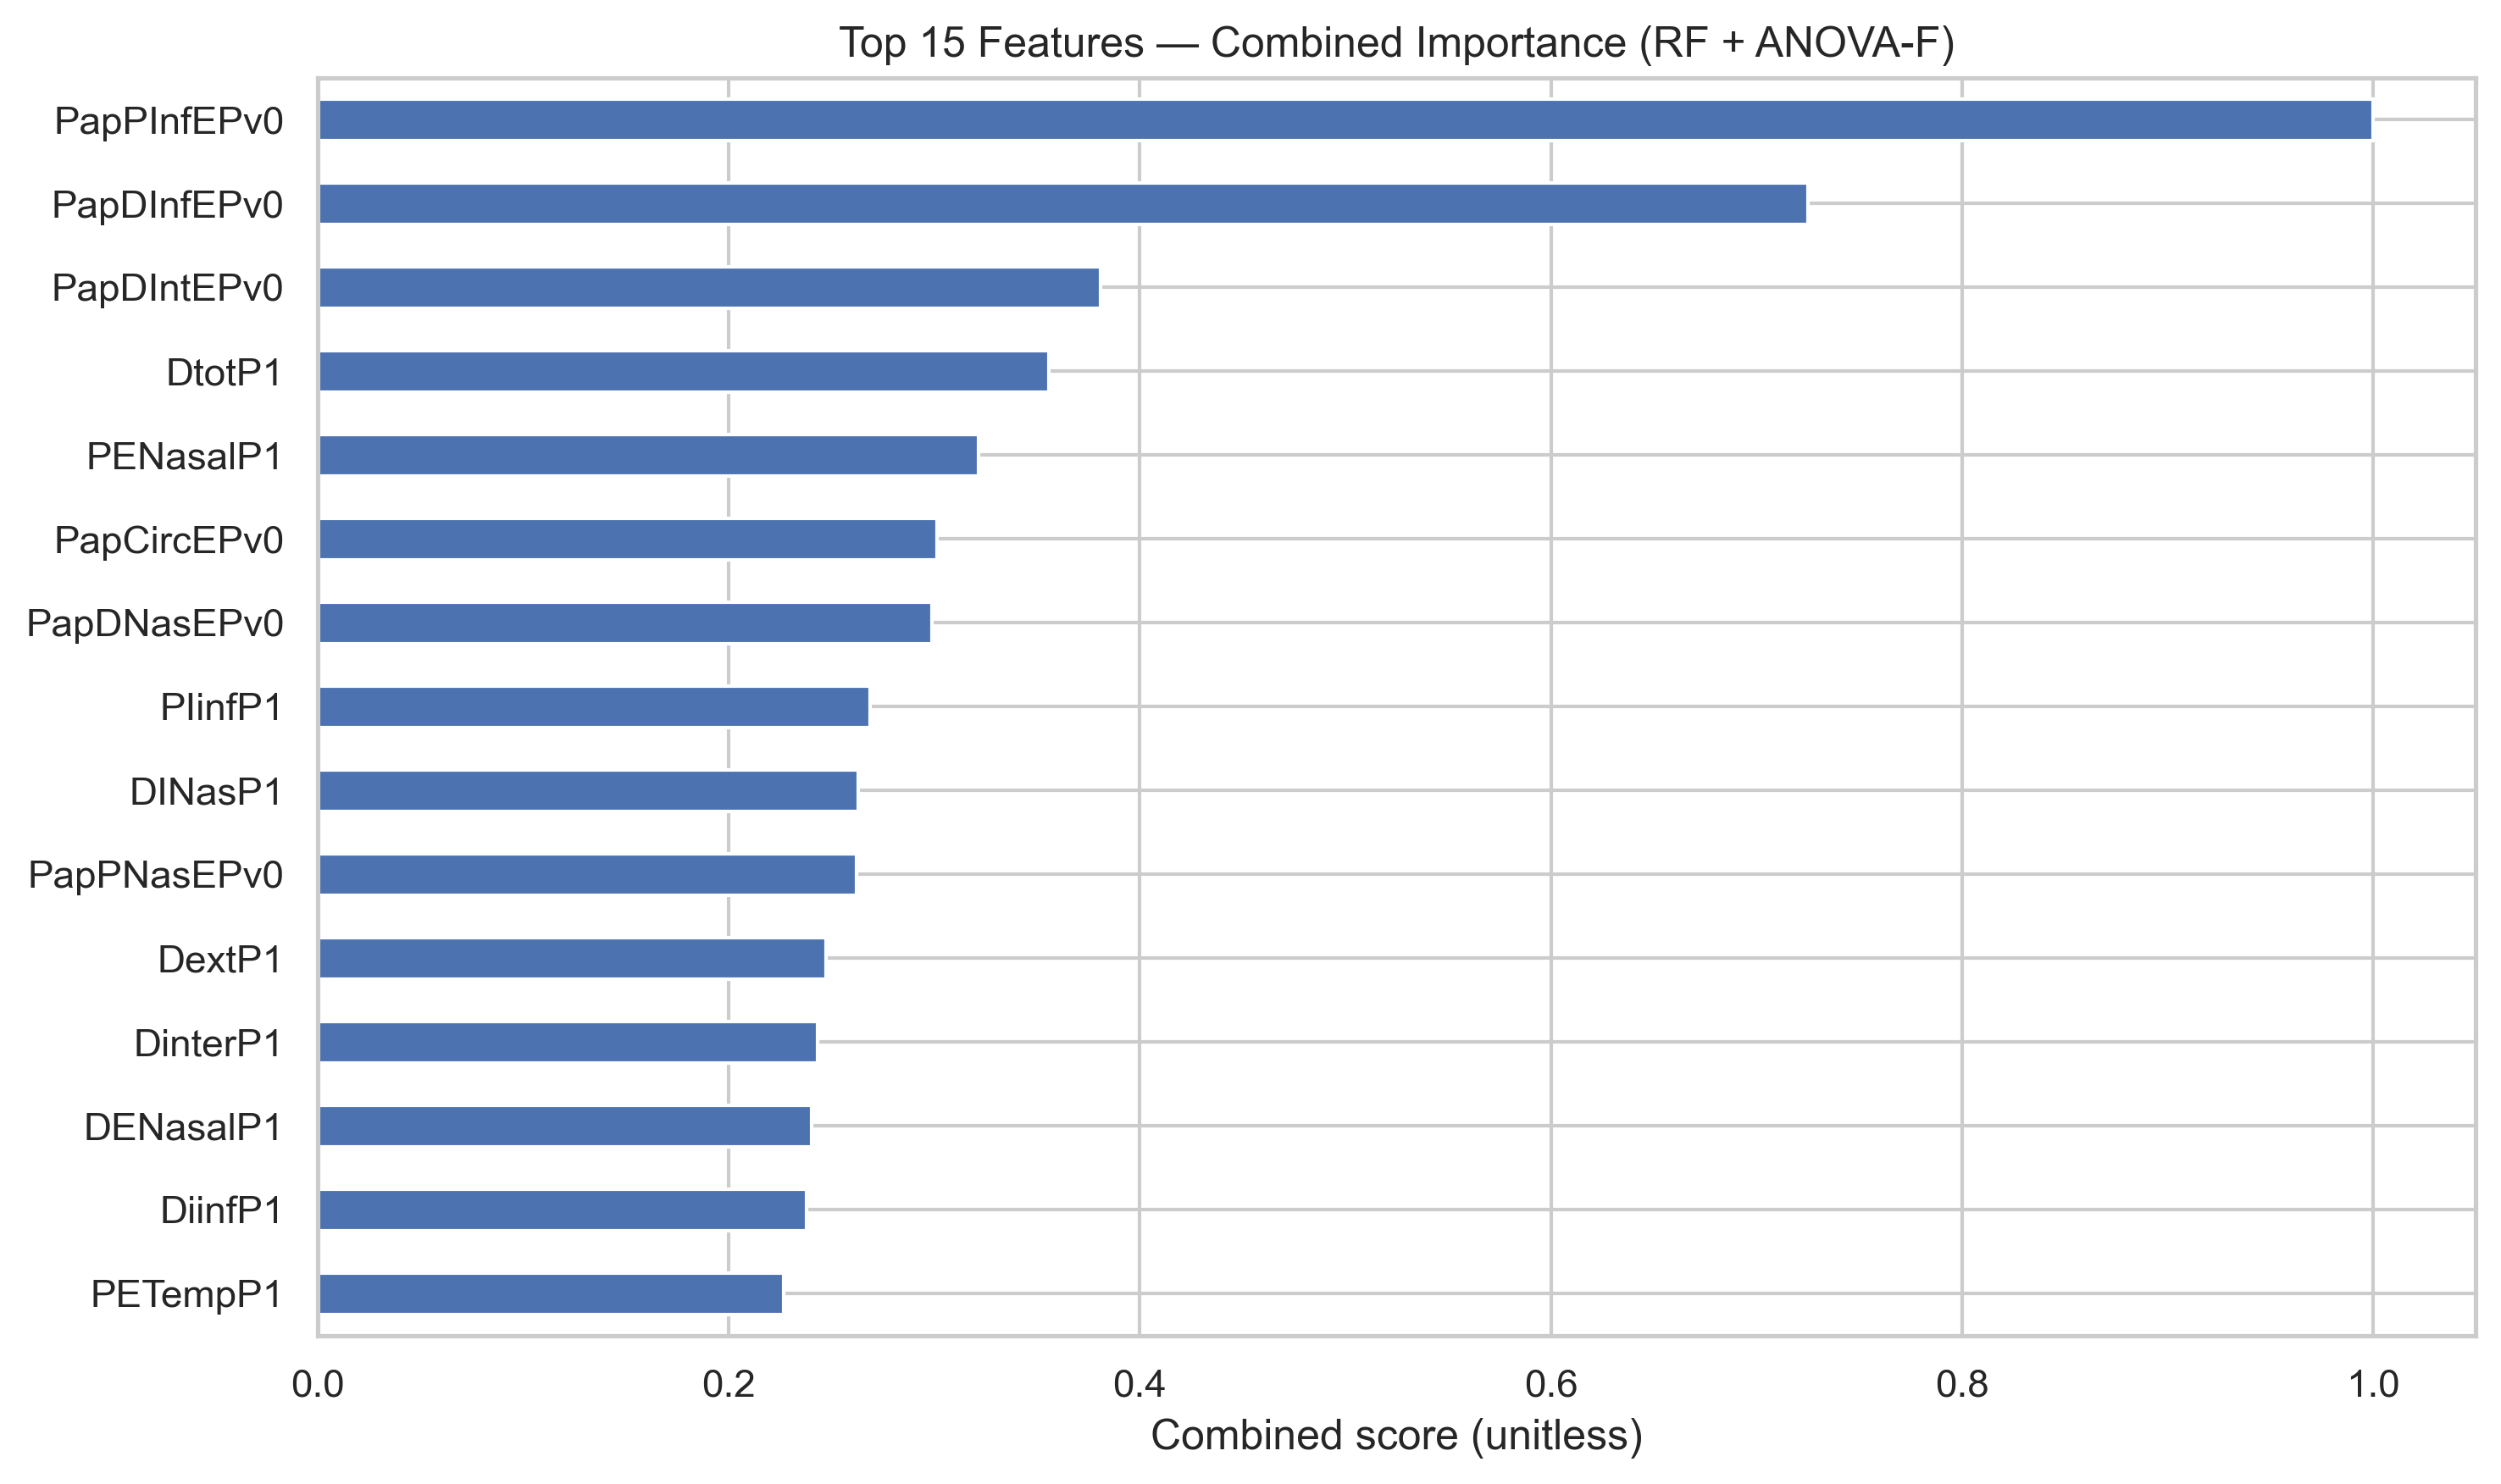

Saved: figures/top15_combined_RF_ANOVAF.png


In [11]:
"""
Feature screening using:
  - RandomForest feature importance (classifier, class_weight='balanced')
  - ANOVA F-score (f_classif)
We:
  1) Select columns ending with 'P1' or 'Pv0'
  2) Align features with the binary outcome 'progression_composite'
  3) Drop rows with any missing values (faithful to your original code)
  4) Standardize X for ANOVA (RF doesn't need scaling, but it's fine)
  5) Compute a combined score = mean( RF_importance_norm , F_score_norm )
  6) Save full table and plot Top-15

Notes:
- Set USE_IMPUTATION=True if you'd prefer median-imputation rather than drop rows.
- Ensure 'progression_composite' exists and is {0,1}.
"""

# Output folders (created if missing); keep consistent with the rest of the notebook
OUT_DERIVED = "data/derived"
OUT_FIGS    = "figures"
os.makedirs(OUT_DERIVED, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

# 1) Select features by suffix
cols_p1_v0 = [c for c in df.columns if c.endswith("P1") or c.endswith("Pv0")]
if not cols_p1_v0:
    raise ValueError("No columns ending with 'P1' or 'Pv0' were found. Check your dataframe.")

# 2) Build X/y, coerce to numeric and align with outcome
if "progression_composite" not in df.columns:
    raise KeyError("Column 'progression_composite' not found. Create it before running this cell.")

X = df[cols_p1_v0].apply(pd.to_numeric, errors="coerce").copy()
y = pd.to_numeric(df["progression_composite"], errors="coerce")

# Remove columns that are completely NaN (keeps code stable/public)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping {len(all_nan_cols)} all-NaN columns.")
    X = X.drop(columns=all_nan_cols)

# 3) Join and drop NA rows (faithful to your original approach)
df_model = pd.concat([X, y.rename("progression_composite")], axis=1).dropna()
X = df_model.drop(columns=["progression_composite"])
y = df_model["progression_composite"].astype(int)

# Optional alternative to preserve more rows:
# USE_IMPUTATION = False
# if USE_IMPUTATION:
#     imp = SimpleImputer(strategy="median")
#     X = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

if X.empty or y.empty:
    raise ValueError("After cleaning, X or y is empty. Check NaNs and outcome availability.")

# 4) Scale features (robust for ANOVA; harmless for RF)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 5a) RandomForest feature importances
rf = RandomForestClassifier(
    n_estimators=400,       # a bit larger for stability
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_scaled, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)

# 5b) ANOVA F-score
F_vals, p_vals = f_classif(X_scaled, y)
anova_importances = pd.Series(F_vals, index=X.columns)

# 6) Combine (normalized) RF + ANOVA-F
def _safe_norm(s: pd.Series) -> pd.Series:
    s = s.copy()
    mx = s.max()
    if not np.isfinite(mx) or mx == 0:
        return pd.Series(0.0, index=s.index)
    return s / mx

importance_df = pd.DataFrame({
    "RandomForestImportance": rf_importances,
    "ANOVA_F_Score": anova_importances,
    "ANOVA_pvalue": p_vals
})
importance_df["RF_norm"]   = _safe_norm(importance_df["RandomForestImportance"])
importance_df["F_norm"]    = _safe_norm(importance_df["ANOVA_F_Score"])
importance_df["Combined"]  = 0.5 * (importance_df["RF_norm"] + importance_df["F_norm"])

print("=== All features ranked by Combined score ===")
display(importance_df.sort_values("Combined", ascending=False))

# Save the full table
importance_path = f"{OUT_DERIVED}/feature_screening_P1_Pv0_RF_ANOVAF.csv"
importance_df.sort_values("Combined", ascending=False).to_csv(importance_path, index=True)
print("Saved:", importance_path)

# 7) Plot Top-15 features by Combined
top15 = importance_df.sort_values("Combined", ascending=False).head(15)
plt.figure(figsize=(10, 6))
top15["Combined"].sort_values().plot(kind="barh")
plt.title("Top 15 Features — Combined Importance (RF + ANOVA-F)")
plt.xlabel("Combined score (unitless)")
plt.tight_layout()
fig_path = f"{OUT_FIGS}/top15_combined_RF_ANOVAF.png"
plt.savefig(fig_path)
plt.show()
print("Saved:", fig_path)

<div id="vif-deltas" class="toc-anchor"></div>

## VIF check (multicollinearity) for your selected variables

In [12]:
"""
Variance Inflation Factor (VIF) to diagnose multicollinearity among a set of variables.
- Uses statsmodels' variance_inflation_factor over a design matrix with a constant.
- Drops rows with NaNs (VIF requires complete cases).
- If some variables are missing in df, we warn and use the intersection.

Tip: VIF > 5~10 suggests considerable collinearity (context dependent).
"""

vars_vif = [
    "PapPInfEPv0",
    "PapDInfEPv0",
    "PapDIntEPv0",
    "PapPSupEPv0",
    "PIinfP1",
    "PapDNasEPv0",
    "PapPNasEPv0",
    "PapCircEPv0",
    "PTotalP1",
    "DtotP1",
]

# Keep only variables present in df
present = [v for v in vars_vif if v in df.columns]
missing = sorted(set(vars_vif) - set(present))
if missing:
    print(f"[VIF] Missing variables (skipped): {missing}")

if len(present) < 2:
    print("[VIF] Not enough variables to compute VIF.")
else:
    X_vif = df[present].apply(pd.to_numeric, errors="coerce").dropna()
    # If nothing left after dropping NaNs, stop gracefully
    if X_vif.empty:
        print("[VIF] No complete cases after NA removal; cannot compute VIF.")
    else:
        X_vif_const = add_constant(X_vif, has_constant="add")
        vif_vals = []
        # variance_inflation_factor expects raw numpy array; index 0 is the constant
        for i in range(1, X_vif_const.shape[1]):  # skip constant at position 0
            vif_i = variance_inflation_factor(X_vif_const.values, i)
            vif_vals.append(vif_i)

        vif_df = pd.DataFrame({"Variable": X_vif.columns, "VIF": vif_vals})
        display(vif_df.sort_values("VIF", ascending=False))

        # Save for record
        vif_path = f"{OUT_DERIVED}/vif_p1_pv0_selection.csv"
        vif_df.sort_values("VIF", ascending=False).to_csv(vif_path, index=False)
        print("Saved:", vif_path)

,Variable,VIF
9,DtotP1,5.916594
5,PapDNasEPv0,5.044390
1,PapDInfEPv0,5.031908
8,PTotalP1,4.928013
2,PapDIntEPv0,4.722701
6,PapPNasEPv0,3.258793
0,PapPInfEPv0,3.081591
3,PapPSupEPv0,2.918789
4,PIinfP1,1.764153
7,PapCircEPv0,1.446857


Saved: data/derived/vif_p1_pv0_selection.csv


<!-- Patient-level logistic regression with covariates (per-variable models) -->
<div id="patientlogreg" class="toc-anchor"></div>

## Patient-level logistic regression with covariates (per-variable models)

In [13]:
"""
Patient-level logistic regression (statsmodels Logit)
Outcome: progression_composite
Design: one-predictor-at-a-time + optional covariates (Edad, AñosSx)

Assumptions:
- The dataset is already de-identified and contains a single ID column: 'PatientID'.
- Each row is an eye; we aggregate to patient-level: predictors/covariates = mean, outcome = max.
- We fit one Logit per predictor (with covariates if available), falling back to
  fit_regularized() if perfect separation occurs.
- Per-model coefficients are saved to: data/derived/logit_<var>_coef.csv
"""

# ---------------------------- config -----------------------------------------
OUT_DERIVED = "data/derived"
os.makedirs(OUT_DERIVED, exist_ok=True)

ID_COL = "PatientID"
OUTCOME = "progression_composite"

# Predictors and covariates you want to test at patient-level
vars_main = [
    "PapPInfEPv0",
    "PapDIntEPv0",
    "PapPSupEPv0",
    "PIinfP1",
    "PapPNasEPv0",
    "PapCircEPv0",
    "PTotalP1",
]
covariates_all = ["Edad", "AñosSx"]

def safe_name(s: str) -> str:
    """File-system safe name."""
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")

# ---------------------- 1) Ensure a clean PatientID column --------------------
df_for_logit = df.copy()

# If the index is named PatientID, move it to a column to avoid ambiguity
if df_for_logit.index.name == ID_COL:
    df_for_logit = df_for_logit.reset_index()

# Make sure the ID column exists; if not, create a deterministic placeholder
if ID_COL not in df_for_logit.columns:
    df_for_logit[ID_COL] = pd.Series(range(len(df_for_logit)), index=df_for_logit.index).astype(str)

# Outcome presence check
if OUTCOME not in df_for_logit.columns:
    raise KeyError(f"Outcome '{OUTCOME}' not found. Create it before running this cell.")

# Keep only predictors/covariates that actually exist
vars_main_present = [v for v in vars_main if v in df_for_logit.columns]
covariates_present = [c for c in covariates_all if c in df_for_logit.columns]
if not vars_main_present:
    raise KeyError("None of the main predictors are present in the DataFrame. Check column names.")

# ------------------ 2) Aggregate to patient level (eyes -> patient) ----------
# predictors/covariates: mean; outcome: max (binary OR across visits/eyes)
agg_dict = {c: "mean" for c in (vars_main_present + covariates_present)}
agg_dict[OUTCOME] = "max"

# Keep NaN-ID groups if any (requires pandas >= 1.1)
df_patient = (
    df_for_logit
    .groupby(ID_COL, dropna=False, as_index=False)
    .agg(agg_dict)
)

print(f"[AGG] Rows -> patients: {len(df_for_logit)} -> {len(df_patient)}")
print(f"[AGG] Predictors present: {len(vars_main_present)} | Covariates present: {len(covariates_present)}")

# ------------------ 3) Fit one Logit per predictor ---------------------------
for var in vars_main_present:
    title = f"{OUTCOME} ~ {var}" + ((" + " + " + ".join(covariates_present)) if covariates_present else "")
    print(f"\n=== Logit model: {title} ===")

    model_cols = [var] + covariates_present + [OUTCOME]
    df_m = df_patient[model_cols].apply(pd.to_numeric, errors="coerce").dropna()

    # Ensure binary outcome with >1 class
    if df_m[OUTCOME].nunique() < 2:
        print(f"[Logit] Skipping {var}: outcome has a single class after NA removal.")
        continue

    y = df_m[OUTCOME].astype(int)
    X = sm.add_constant(df_m.drop(columns=[OUTCOME]), has_constant="add")

    # Standard Logit; fallback to regularized on failure (e.g., perfect separation)
    try:
        model = sm.Logit(y, X).fit(disp=False)
    except Exception as e:
        print(f"[Logit] Standard fit failed for {var} ({e}); trying fit_regularized...")
        try:
            model = sm.Logit(y, X).fit_regularized(disp=False)
        except Exception as e2:
            print(f"[Logit] Could not fit model with {var}: {e2}")
            continue

    print(model.summary())

    # Save coefficients and basic stats
    params = model.params.rename("coef").to_frame()
    params["stderr"] = getattr(model, "bse", np.nan)
    params["z"] = getattr(model, "tvalues", np.nan)
    params["pvalue"] = getattr(model, "pvalues", np.nan)

    out_path = f"{OUT_DERIVED}/logit_{safe_name(var)}_coef.csv"
    params.to_csv(out_path)
    print("Saved:", out_path)

[AGG] Rows -> patients: 56 -> 28
[AGG] Predictors present: 7 | Covariates present: 2

=== Logit model: progression_composite ~ PapPInfEPv0 + Edad + AñosSx ===
                             Logit Regression Results                            
Dep. Variable:     progression_composite   No. Observations:                   28
Model:                             Logit   Df Residuals:                       24
Method:                              MLE   Df Model:                            3
Date:                   Sat, 27 Sep 2025   Pseudo R-squ.:                  0.3195
Time:                           16:31:14   Log-Likelihood:                -10.714
converged:                          True   LL-Null:                       -15.745
Covariance Type:               nonrobust   LLR p-value:                   0.01804
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -21.7183   

<!-- Sanity check: per-eye vs per-patient counts -->
<div id="sanity" class="toc-anchor"></div>

## Sanity check: per-eye vs per-patient counts (safe to publish)

In [14]:
"""
Sanity check for unit-of-analysis:
- Each row is an eye; patient-level ID may repeat (typically twice: OD/OS).
- This cell reports how many unique patients we have, distribution of eyes per patient,
  and lists patients with 1 or >2 eyes (if any).
"""

# Pick the ID column you actually use in your analysis.
# If you already standardized to 'NombrePaciente', keep it; otherwise pick the best available.
ID_CANDIDATES = ["NombrePaciente", "NombreControl", "Paciente", "PatientID", "Subject", "ID", "Nombre"]
id_col = next((c for c in ID_CANDIDATES if c in df.columns), None)
if id_col is None:
    # fallback: create a synthetic ID if nothing exists
    id_col = "PatientID"
    df[id_col] = np.arange(len(df))

# Normalize ID formatting (avoid spurious duplicates due to whitespace)
df[id_col] = df[id_col].astype(str).str.strip()

n_rows = len(df)
n_patients = df[id_col].nunique(dropna=True)
eyes_per_patient = df[id_col].value_counts(dropna=True).sort_values(ascending=False)

print(f"Total rows (eyes): {n_rows}")
print(f"Unique patients:  {n_patients}")
print("\nEyes per patient (top 10):")
display(eyes_per_patient.head(10).to_frame("n_eyes"))

# Flag patients not having exactly 2 eyes recorded (common causes: missing visit, data entry)
non_2 = eyes_per_patient[eyes_per_patient != 2]
if not non_2.empty:
    print("\nPatients with != 2 eyes (audit):")
    display(non_2.to_frame("n_eyes"))
else:
    print("\nAll patients have exactly 2 eyes recorded. ✅")

Total rows (eyes): 56
Unique patients:  28

Eyes per patient (top 10):


,n_eyes
PatientID,
ID_17D78676,2
ID_03B30771,2
ID_51B8AF89,2
ID_A2ED2747,2
ID_59CE2141,2
ID_E99B333B,2
ID_948B19AF,2
ID_F57D783B,2
ID_232EF9A7,2



All patients have exactly 2 eyes recorded. ✅


## If you ever want per-eye models with cluster-robust SEs

In [15]:
# -*- coding: utf-8 -*-
"""
Per-eye logistic regression with patient-clustered standard errors.
- No aggregation: each row is an eye.
- Cluster-robust inference by PatientID.
- Saves ORs (robust) to data/derived/.

Edit `eye_predictors` / `covariates` as needed.
"""

import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm

OUT_DERIVED = "data/derived"
os.makedirs(OUT_DERIVED, exist_ok=True)

# --- Config ------------------------------------------------------------------
ID_COL      = "PatientID"                 # de-identified ID at eye level
OUTCOME     = "progression_composite"     # binary 0/1 at eye level
eye_predictors = ["PapPInfEPv0", "PapDIntEPv0"]   # <-- edit to taste
covariates     = ["Edad", "AñosSx"]              # <-- edit to taste

def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")

# --- 1) Checks & selection ---------------------------------------------------
if ID_COL not in df.columns and df.index.name == ID_COL:
    # avoid ambiguity if ID is sitting in the index
    df_eye = df.reset_index().copy()
else:
    df_eye = df.copy()

if ID_COL not in df_eye.columns:
    raise KeyError(f"ID column '{ID_COL}' not found. Make sure your dataframe has it.")

if OUTCOME not in df_eye.columns:
    raise KeyError(f"Outcome '{OUTCOME}' not found. Create it before running this cell.")

# Keep only available variables
use_vars = [v for v in (eye_predictors + covariates) if v in df_eye.columns]
if not use_vars:
    raise KeyError("None of the requested predictors/covariates are present in the DataFrame.")

keep_cols = use_vars + [OUTCOME, ID_COL]
d = df_eye[keep_cols].copy()

# Coerce numeric where appropriate (do NOT coerce the ID)
numeric_cols = [c for c in use_vars + [OUTCOME] if c in d.columns]
d[numeric_cols] = d[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Drop rows with missing y or predictors/covariates
d = d.dropna(subset=numeric_cols + [ID_COL])

# --- 2) Basic diagnostics ----------------------------------------------------
n_eyes = len(d)
n_clusters = d[ID_COL].nunique(dropna=False)
print(f"[EYE] N eyes used: {n_eyes} | N patients (clusters): {n_clusters}")

if d[OUTCOME].nunique() < 2:
    raise ValueError("Outcome has a single class after cleaning; cannot fit per-eye model.")
if n_clusters < 2:
    raise ValueError("Need at least 2 clusters (patients) for cluster-robust SEs.")

# Optional: standardize predictors to aid convergence (comment out if undesired)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# d[use_vars] = scaler.fit_transform(d[use_vars])

# --- 3) Fit GLM Binomial with cluster-robust SEs -----------------------------
X = sm.add_constant(d[use_vars], has_constant="add")
y = d[OUTCOME].astype(int)

glm = sm.GLM(y, X, family=sm.families.Binomial())
# use_t=True -> t-stats with d.f. based on #clusters (recommended for cluster SEs)
res = glm.fit(cov_type="cluster", cov_kwds={"groups": d[ID_COL]}, use_t=True)

print(res.summary())

# --- 4) Odds ratios (robust) + 95% CI and save -------------------------------
params = res.params
conf   = res.conf_int()
conf.columns = ["2.5%", "97.5%"]

or_vals = np.exp(params)
or_ci   = np.exp(conf)

or_table = pd.concat([or_vals.rename("OR"), or_ci], axis=1)
print("\n=== Odds Ratios (cluster-robust) ===")
print(or_table)

tag = safe_name("per_eye_" + "_".join(use_vars))
out_path = f"{OUT_DERIVED}/per_eye_glm_cluster_OR_{tag}.csv"
or_table.to_csv(out_path)
print("Saved:", out_path)

[EYE] N eyes used: 56 | N patients (clusters): 28
                   Generalized Linear Model Regression Results                   
Dep. Variable:     progression_composite   No. Observations:                   56
Model:                               GLM   Df Residuals:                       51
Model Family:                   Binomial   Df Model:                            4
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -22.369
Date:                   Sat, 27 Sep 2025   Deviance:                       44.739
Time:                           16:31:15   Pearson chi2:                     54.7
No. Iterations:                        7   Pseudo R-squ. (CS):             0.2780
Covariance Type:                 cluster                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

<!-- Delta computation (P1–P3 y v0–v2) + audit -->
<div id="delta" class="toc-anchor"></div>

## Delta computation (P1−P3 y v0−v2) + audit

In [16]:
"""
Delta computation with robust pairing and reproducible, public-friendly outputs.

Creates:
- P1 vs P3 deltas:   delta_<lowercase(original_P1_column)>3
  e.g., DCentP1 → delta_dcentp13  =  DCentP1 - DCentP3

- v0 vs v2 deltas:   delta_<lowercase(original_base_column)>2
  for suffix families: V0→V2, v0→v2, EPv0→EPv2, Cv0→Cv2, .v0→.v2
  e.g., PapAreaEPv0 → delta_papareaepv02  =  PapAreaEPv0 - PapAreaEPv2

Notes:
- We keep your original naming style (`...p13`) for P1−P3 so downstream code works unchanged.
- For v0−v2, we log missing pairs so you can fix any column-name inconsistencies.
"""

OUT_DERIVED = "data/derived"
OUT_FIGS    = "figures"
os.makedirs(OUT_DERIVED, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

# ---------- Helpers ----------
def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

# ---------- P1 − P3 deltas (keeps your '...p13' naming) ----------
created_p13 = []
skipped_p13 = []

for col in df.columns:
    if str(col).upper().endswith("P1"):
        # Build the paired P3 column by replacing the last character '1' with '3'
        col_p3 = col[:-1] + "3"
        if col_p3 in df.columns:
            new_col = f"delta_{col.lower()}3"   # e.g., DCentP1 -> delta_dcentp13
            df[new_col] = pd.to_numeric(df[col], errors="coerce") - pd.to_numeric(df[col_p3], errors="coerce")
            created_p13.append((col, col_p3, new_col))
        else:
            skipped_p13.append((col, "missing P3", col_p3))

print(f"[P1-P3] Created {len(created_p13)} delta columns.")
if skipped_p13:
    print(f"[P1-P3] Skipped {len(skipped_p13)} (no P3 pair). Example:", skipped_p13[:3])

# ---------- v0 − v2 deltas over multiple suffix families ----------
SUFFIX_FAMILIES_V02 = {
    "V0":   "V2",
    "v0":   "v2",
    "EPv0": "EPv2",
    "Cv0":  "Cv2",
    ".v0":  ".v2",
}

created_v02 = []
skipped_v02 = []

cols = list(df.columns)
colset = set(cols)

def strip_suffix(name: str, suffix: str):
    return name[:-len(suffix)] if name.endswith(suffix) else None

for base_sfx, visit_sfx in SUFFIX_FAMILIES_V02.items():
    # iterate over columns that end with the base suffix
    base_cols = [c for c in cols if str(c).endswith(base_sfx)]
    for base_c in base_cols:
        prefix = strip_suffix(base_c, base_sfx)
        if prefix is None:
            continue
        visit_c = prefix + visit_sfx
        if visit_c in colset:
            new_col = f"delta_{base_c.lower()}2"  # e.g., PapAreaEPv0 -> delta_papareaepv02
            df[new_col] = pd.to_numeric(df[base_c], errors="coerce") - pd.to_numeric(df[visit_c], errors="coerce")
            created_v02.append((base_c, visit_c, new_col))
        else:
            skipped_v02.append((base_c, "missing visit", visit_c))

print(f"[v0-v2] Created {len(created_v02)} delta columns across families {list(SUFFIX_FAMILIES_V02.keys())}.")
if skipped_v02:
    # Save a full report to help spot typos like PapDTemEPv0 vs PapDTempEPv2
    rep = pd.DataFrame(skipped_v02, columns=["base_col", "reason", "expected_visit_col"])
    rep.to_csv(f"{OUT_DERIVED}/missing_v02_pairs.csv", index=False)
    print(f"[v0-v2] Missing pairs report saved to {OUT_DERIVED}/missing_v02_pairs.csv (first 5):")
    display(rep.head())

# ---------- Summary ----------
new_delta_cols = [c for c in df.columns if str(c).startswith("delta_")]
print(f"[SUMMARY] Total new delta columns: {len(new_delta_cols)}")

[P1-P3] Created 25 delta columns.
[v0-v2] Created 64 delta columns across families ['V0', 'v0', 'EPv0', 'Cv0', '.v0'].
[v0-v2] Missing pairs report saved to data/derived/missing_v02_pairs.csv (first 5):


,base_col,reason,expected_visit_col
0,PapDIntCV0,missing visit,PapDIntCV2
1,PapDTemEPv0,missing visit,PapDTemEPv2
2,PapPTemEPv0,missing visit,PapPTemEPv2
3,PapDTemCv0,missing visit,PapDTemCv2
4,PapPTemCv0,missing visit,PapPTemCv2


[SUMMARY] Total new delta columns: 67


<!-- Feature screening on P1–P3 deltas (RF + ANOVA F) -->
<div id="screen" class="toc-anchor"></div>

## Feature screening on P1−P3 deltas (RF + ANOVA F) with combined score

,RandomForestImportance,ANOVA_F_Score,ANOVA_pvalue,RF_norm,F_norm,Combined
delta_penasalp13,0.120114,12.354415,0.000899,1.000000,1.000000,1.000000
delta_ditempp13,0.087758,6.803386,0.011743,0.730627,0.550685,0.640656
delta_pcentralp13,0.070223,3.851419,0.054865,0.584637,0.311744,0.448191
delta_pinasalp13,0.053814,5.503153,0.022684,0.448025,0.445440,0.446733
delta_peinfp13,0.047571,5.649619,0.021033,0.396048,0.457296,0.426672
delta_pisupp13,0.038815,5.875044,0.018737,0.323151,0.475542,0.399347
delta_pexternap13,0.066011,2.171366,0.146407,0.549568,0.175756,0.362662
delta_ptotalp13,0.044496,3.945787,0.052074,0.370451,0.319383,0.344917
delta_petempp13,0.052752,3.022611,0.087810,0.439185,0.244658,0.341922
delta_dinasp13,0.030613,4.482332,0.038869,0.254870,0.362812,0.308841


Saved: data/derived/feature_screening_delta_p13_RF_ANOVAF.csv


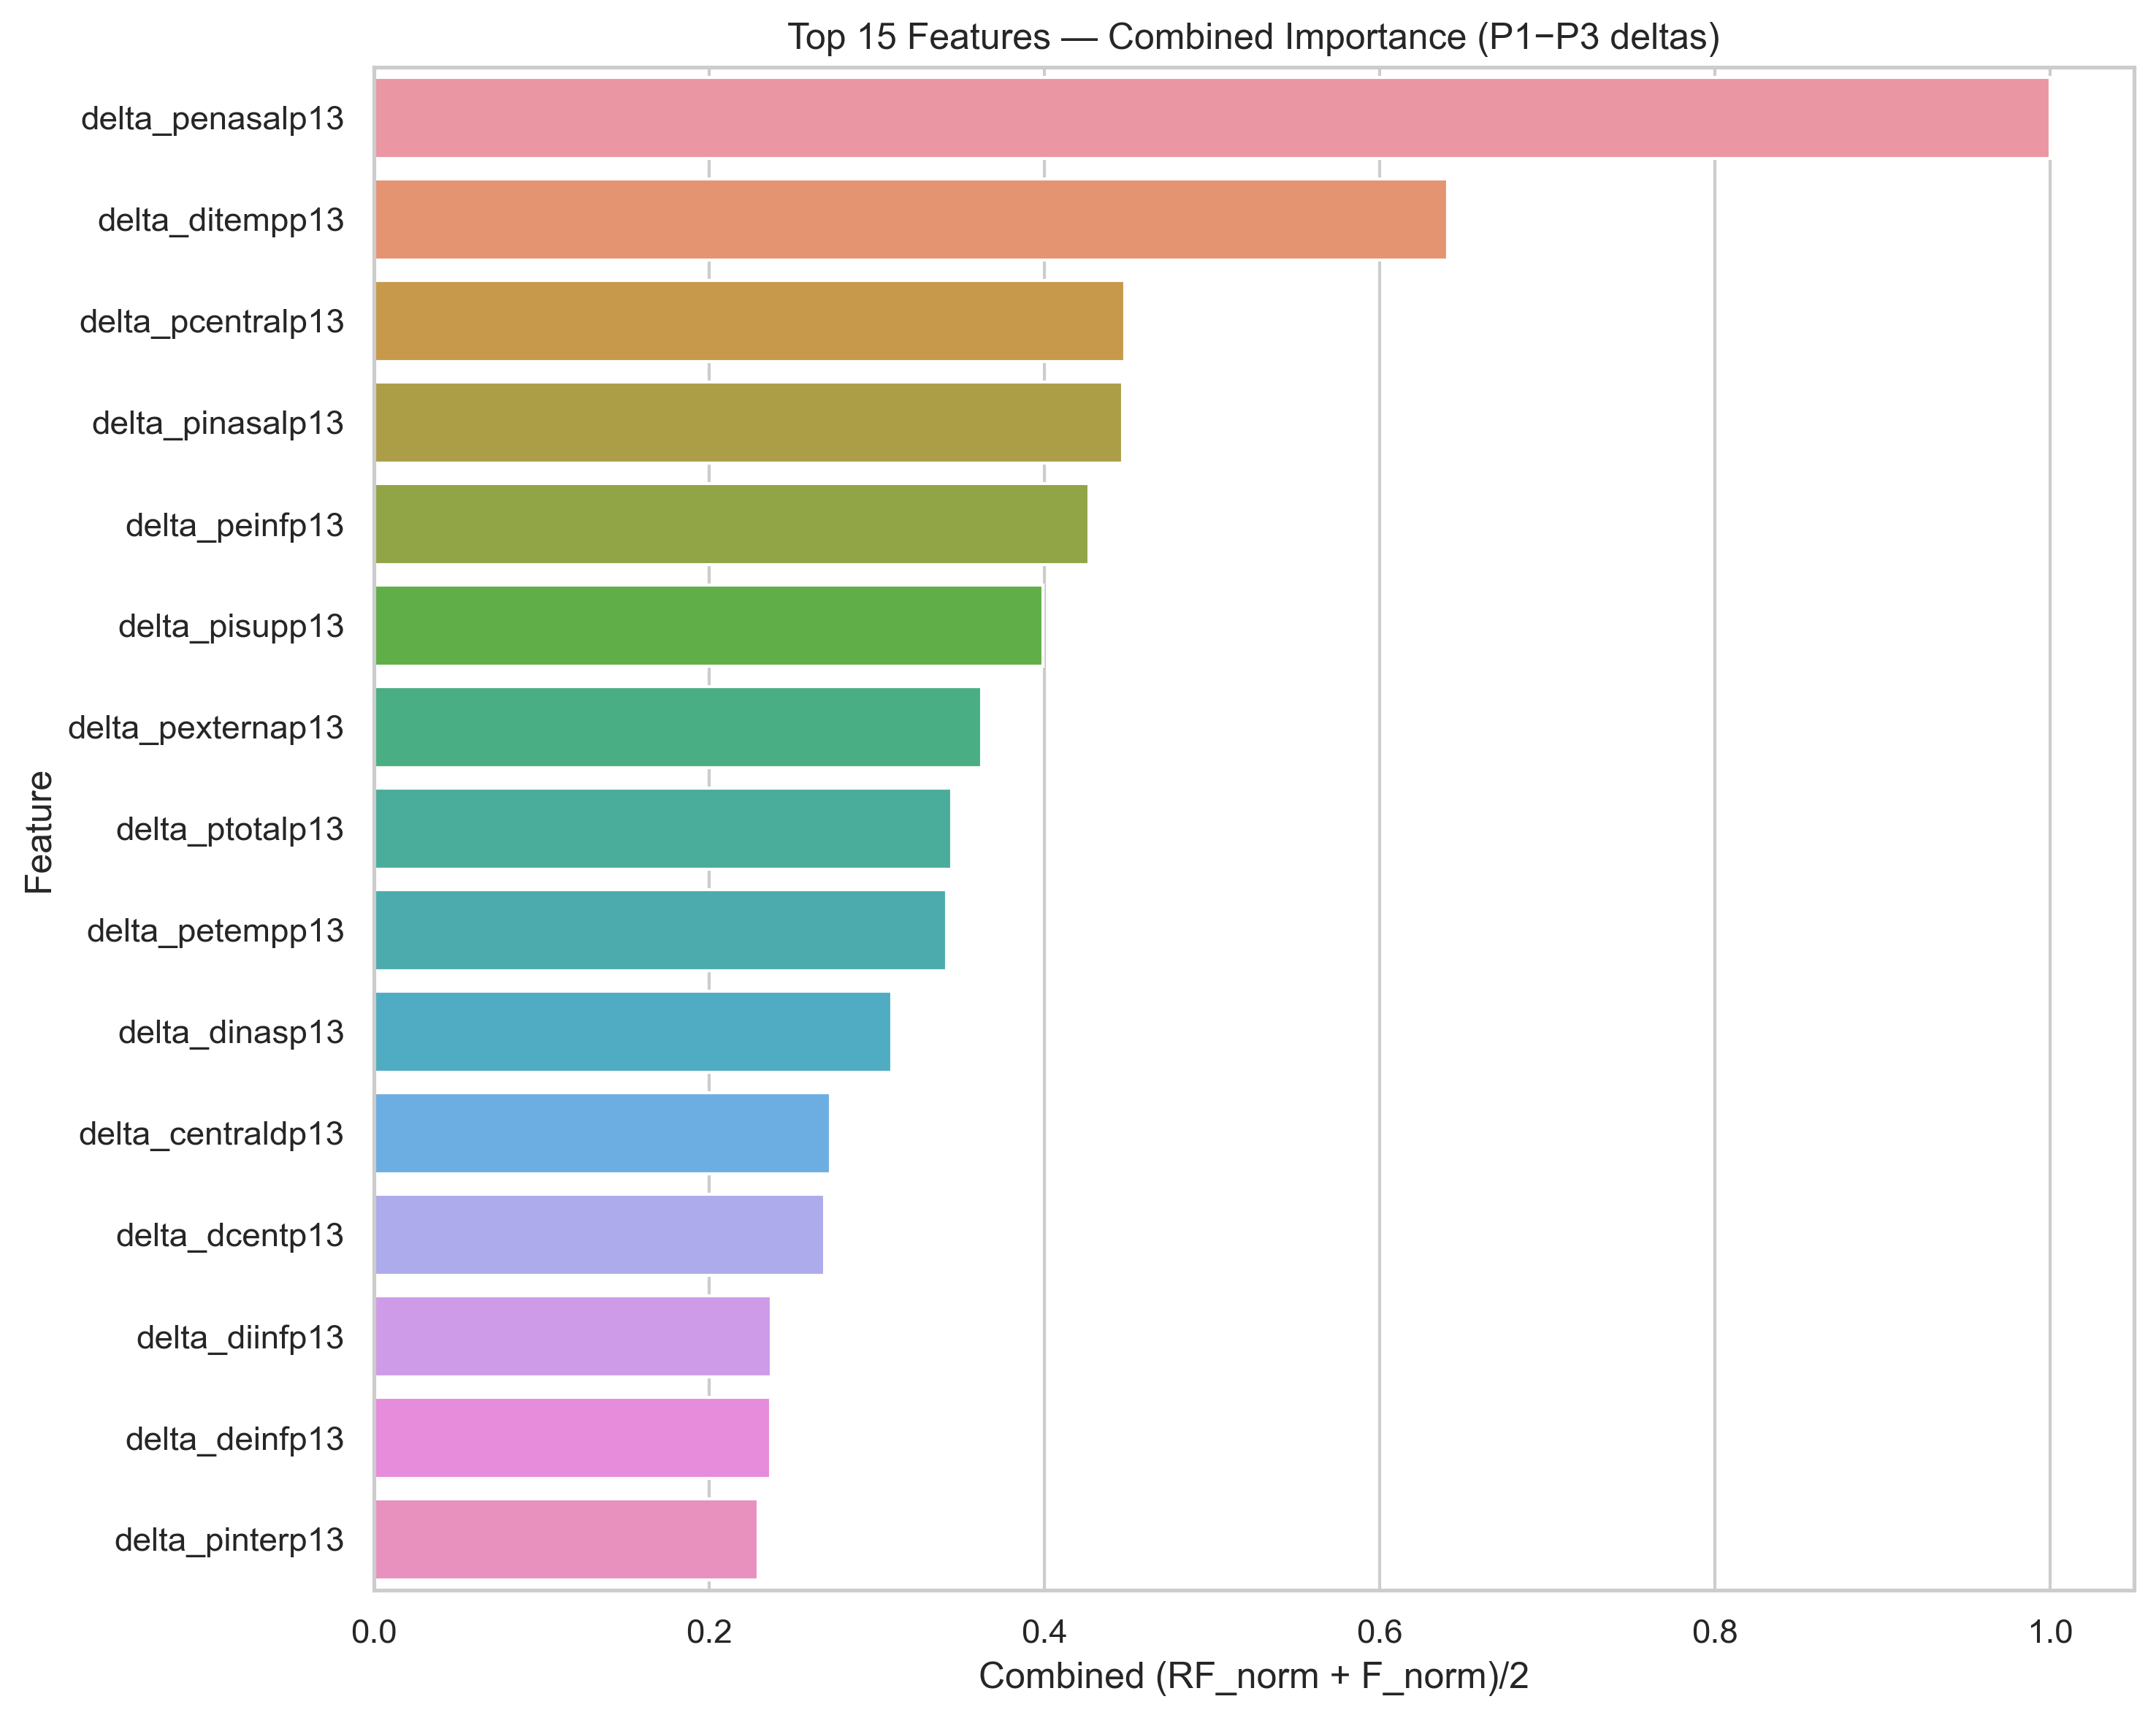

Saved: figures/top15_combined_delta_p13.png


In [17]:
"""
Feature screening on P1−P3 deltas:
- Collects all columns matching your 'delta_*p13' pattern (or falls back to your manual list).
- Standardizes X (helpful for ANOVA; harmless for RF).
- RF feature importance + ANOVA F, then a normalized Combined score.
- Saves full table and plots Top-15.
"""

# 1) Auto-detect P1−P3 delta vars
auto_delta_vars = [c for c in df.columns if c.startswith("delta_") and c.endswith("p13")]

# 2) Your original explicit list (kept for reproducibility)
manual_delta_vars = [
    'delta_dcentp13','delta_dinterp13','delta_dextp13','delta_dtotp13','delta_centraldp13',
    'delta_disupp13','delta_diinfp13','delta_dinasp13','delta_ditempp13','delta_desupp13',
    'delta_deinfp13','delta_denasalp13','delta_detempp13','delta_pcentralp13','delta_pinterp13',
    'delta_pexternap13','delta_ptotalp13','delta_pisupp13','delta_piinfp13','delta_pinasalp13',
    'delta_pitempp13','delta_pesupp13','delta_peinfp13','delta_penasalp13','delta_petempp13'
]

# 3) Choose variables: prefer auto (ensures they exist); if empty, use manual ∩ df
if auto_delta_vars:
    delta_vars = sorted(auto_delta_vars)
else:
    delta_vars = [v for v in manual_delta_vars if v in df.columns]
    if not delta_vars:
        raise ValueError("No 'delta_*p13' variables found. Check the delta generation cell.")

# 4) Build X/y and clean
if "progression_composite" not in df.columns:
    raise KeyError("Column 'progression_composite' not found. Create it before screening.")

df_fs = df[delta_vars + ["progression_composite"]].apply(pd.to_numeric, errors="coerce").dropna()
X = df_fs[delta_vars].copy()
y = df_fs["progression_composite"].astype(int)

# 5) Standardize features
scaler = StandardScaler()
Xz = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 6) RF importance
rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(Xz, y)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns)

# 7) ANOVA F
F_vals, p_vals = f_classif(Xz, y)
F_series = pd.Series(F_vals, index=X.columns)

# 8) Combine (normalized)
def _norm(s):
    s = s.copy()
    m = s.max()
    return s / m if np.isfinite(m) and m > 0 else pd.Series(0.0, index=s.index)

tbl = pd.DataFrame({
    "RandomForestImportance": rf_imp,
    "ANOVA_F_Score": F_series,
    "ANOVA_pvalue": p_vals
})
tbl["RF_norm"]  = _norm(tbl["RandomForestImportance"])
tbl["F_norm"]   = _norm(tbl["ANOVA_F_Score"])
tbl["Combined"] = 0.5 * (tbl["RF_norm"] + tbl["F_norm"])

tbl_sorted = tbl.sort_values("Combined", ascending=False)
display(tbl_sorted)

# 9) Save table + plot Top-15
out_csv = f"{OUT_DERIVED}/feature_screening_delta_p13_RF_ANOVAF.csv"
tbl_sorted.to_csv(out_csv)
print("Saved:", out_csv)

top15 = tbl_sorted.head(15)
plt.figure(figsize=(10, 8))
sns.barplot(x=top15["Combined"], y=top15.index, orient="h")
plt.title("Top 15 Features — Combined Importance (P1−P3 deltas)")
plt.xlabel("Combined (RF_norm + F_norm)/2")
plt.ylabel("Feature")
plt.tight_layout()
fig_pth = f"{OUT_FIGS}/top15_combined_delta_p13.png"
plt.savefig(fig_pth)
plt.show()
print("Saved:", fig_pth)


<!-- VIF on selected delta variables -->
<div id="vif-deltas" class="toc-anchor"></div>

## VIF on selected delta variables (with constant) + save

In [18]:
"""
Variance Inflation Factor (VIF) to diagnose multicollinearity among selected delta variables.
- Computes VIF on a standardized design matrix **with a constant**.
- Drops rows with any NA across the selected columns.
- Saves sorted VIF table to data/derived/.

Tip: VIF > ~5–10 can indicate substantial collinearity (interpretation depends on context).
"""

# Choose variables:
#  - Option A (recommended): take the Top-K from the screening table
#  - Option B: use your manual list below

USE_TOPK_FROM_SCREENING = True
TOPK = 20  # adjust as needed

if USE_TOPK_FROM_SCREENING:
    # Reuse 'tbl_sorted' from the previous cell
    if "tbl_sorted" not in globals():
        raise RuntimeError("Run the screening cell first to create 'tbl_sorted'.")
    vars_vif = list(tbl_sorted.head(TOPK).index)
else:
    vars_vif = [
        'delta_dcentp13','delta_dinterp13','delta_dextp13','delta_dtotp13','delta_centraldp13',
        'delta_disupp13','delta_diinfp13','delta_dinasp13','delta_ditempp13','delta_desupp13',
        'delta_deinfp13','delta_denasalp13','delta_detempp13','delta_pcentralp13','delta_pinterp13',
        'delta_pexternap13','delta_ptotalp13','delta_pisupp13','delta_piinfp13','delta_pinasalp13',
        'delta_pitempp13','delta_pesupp13','delta_peinfp13','delta_penasalp13','delta_petempp13'
    ]

# Keep only those present
vars_vif = [v for v in vars_vif if v in df.columns]
if len(vars_vif) < 2:
    raise ValueError("Not enough VIF variables available in df.")

# Build complete-case matrix
X_vif = df[vars_vif].apply(pd.to_numeric, errors="coerce").dropna()
if X_vif.empty or X_vif.shape[0] <= X_vif.shape[1]:
    print("[VIF] Not enough complete cases or observations < variables; consider reducing vars or imputing.")
else:
    # Standardize (optional; VIF is scale-invariant, standardization helps numerics)
    scaler = StandardScaler()
    Xz = pd.DataFrame(scaler.fit_transform(X_vif), columns=vars_vif, index=X_vif.index)

    # Add constant and compute VIF for each feature (skip the constant at index 0)
    Xc = add_constant(Xz, has_constant="add")
    vif_vals = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        vif_vals.append({"Variable": col, "VIF": variance_inflation_factor(Xc.values, i)})

    vif_df = pd.DataFrame(vif_vals).sort_values("VIF", ascending=False)
    display(vif_df)

    out_vif = f"{OUT_DERIVED}/vif_delta_p13.csv"
    vif_df.to_csv(out_vif, index=False)
    print("Saved:", out_vif)

,Variable,VIF
6,delta_pexternap13,13.437274
9,delta_dinasp13,7.407930
12,delta_diinfp13,6.741415
18,delta_desupp13,6.489075
13,delta_deinfp13,6.032636
7,delta_ptotalp13,5.911237
3,delta_pinasalp13,5.340205
10,delta_centraldp13,5.228106
5,delta_pisupp13,5.096445
15,delta_dtotp13,4.777381


Saved: data/derived/vif_delta_p13.csv


<!-- Setup (helpers, outputs) -->
<div id="setup" class="toc-anchor"></div>

## Setup (helpers, outputs)

In [19]:
"""
Final modeling section — clean, reproducible, public-friendly.

Includes:
- Patient-level aggregation (eye rows -> patient table)
- Per-variable logistic regressions with covariates
- A focused multivariable model (PapPInfEPv0 + age + disease duration)
- VIF check, odds ratios with 95% CIs
- ROC/AUC with Youden threshold, confusion matrices
- Logistic curve: probability vs. PapPInfEPv0 (holding covariates at mean)

Notes:
- Each row in the raw df corresponds to an eye. We aggregate to patient level for modeling.
- Outcome is 'progression_composite' (binary).
"""

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUT_DERIVED = "data/derived"
OUT_FIGS    = "figures"
os.makedirs(OUT_DERIVED, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

def safe_name(s: str) -> str:
    """Make a string safe for filenames."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

def to_num(df_or_s):
    """Coerce to numeric (errors -> NaN)."""
    if isinstance(df_or_s, pd.Series):
        return pd.to_numeric(df_or_s, errors="coerce")
    out = df_or_s.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

<!-- Build patient-level table (aggregation) -->
<div id="patient" class="toc-anchor"></div>

## Build patient-level table (aggregation)

In [20]:
"""
Build a patient-level table:
- Predictors & covariates: mean across eyes/rows per patient
- Outcome (progression_composite): max across rows (if any eye progressed → patient=1)
- Robust to ID naming: picks the best available ID column and unifies it as 'PatientID'
"""

ID_CANDIDATES = ["NombrePaciente", "NombreControl", "Paciente", "SubjectID", "Subject", "ID", "Nombre"]

def pick_best_id_column(frame: pd.DataFrame) -> str | None:
    present = [c for c in ID_CANDIDATES if c in frame.columns]
    if not present:
        return None
    scores = {c: frame[c].astype(str).str.strip().replace({"": np.nan}).nunique(dropna=True) for c in present}
    best = sorted(scores.items(), key=lambda kv: (-kv[1], present.index(kv[0])))[0][0]
    print("[ID] candidates nunique:", scores, "| selected:", best)
    return best

def build_patient_table(frame: pd.DataFrame,
                        vars_main: list[str],
                        covariates: list[str],
                        outcome: str = "progression_composite") -> pd.DataFrame:
    df_src = frame.copy()
    # Resolve ID
    best_id = pick_best_id_column(df_src)
    if best_id is None:
        # fall back: use index or sequential
        if df_src.index.dtype == "O" and df_src.index.nunique() >= len(df_src) * 0.5:
            df_src = df_src.reset_index().rename(columns={"index": "PatientID"})
        else:
            df_src["PatientID"] = np.arange(len(df_src))
    else:
        df_src["PatientID"] = df_src[best_id].astype(str).str.strip().replace({"": np.nan})
        # fill missing IDs with stable placeholders
        mask_na = df_src["PatientID"].isna()
        if mask_na.any():
            df_src.loc[mask_na, "PatientID"] = "UNK_" + df_src.index.astype(str)

    # Keep only required columns that exist
    req = [c for c in set(vars_main + covariates + [outcome, "PatientID"]) if c in df_src.columns]
    df_req = df_src[req].copy()

    # Aggregate: means for predictors/covariates; max for outcome
    agg_dict = {c: "mean" for c in vars_main + covariates if c in df_req.columns}
    if outcome in df_req.columns:
        agg_dict[outcome] = "max"
    df_pat = (
        df_req
        .groupby("PatientID", as_index=False, dropna=False)
        .agg(agg_dict)
    )

    # Coerce numeric for modeling columns
    for c in vars_main + covariates + [outcome]:
        if c in df_pat.columns:
            df_pat[c] = pd.to_numeric(df_pat[c], errors="coerce")

    # Diagnostics
    print(f"[AGG] Eyes (rows) in raw df: {len(df)} | Patients in model table: {len(df_pat)}")
    return df_pat

<!-- Per-variable logistic regression with covariates -->
<div id="perlogit" class="toc-anchor"></div>

## Per-variable logistic regression with covariates

In [21]:
"""
Patient-level (NOT per-eye) logistic regressions for delta features.

What this cell does
-------------------
1) Verifies we have a de-identified patient key: `PatientID`.
2) Aggregates eye-rows -> one row per patient:
     - Predictors & covariates: mean across eyes
     - Outcome (binary): max (i.e., OR across eyes)
3) Fits one Logit per delta-feature, adjusted for Age (Edad) and
   disease duration (AñosSx), using complete-case rows per model.
4) Falls back to fit_regularized() if perfect separation occurs.
5) Saves coefficients (and, if available, ORs+95% CI) to data/derived/.

This version is robust after de-identification: it does not rely on
'NombrePaciente' and will fail loudly if `PatientID` is missing
or unique per row (which would imply per-eye modeling).
"""

# ---------- configuration ----------
OUT_DERIVED = globals().get("OUT_DERIVED", "data/derived")
os.makedirs(OUT_DERIVED, exist_ok=True)

ID_COL   = "PatientID"                 # de-identified key (must repeat across a patient's eyes)
OUTCOME  = "progression_composite"     # binary 0/1
COVARS   = ["Edad", "AñosSx"]          # adjusters

# Main delta features (P1−P3) to scan
VARS_MAIN = [
    "delta_dcentp13","delta_dinterp13","delta_dextp13","delta_dtotp13","delta_centraldp13",
    "delta_disupp13","delta_diinfp13","delta_dinasp13","delta_ditempp13","delta_desupp13",
    "delta_deinfp13","delta_denasalp13","delta_detempp13","delta_pcentralp13","delta_pinterp13",
    "delta_pexternap13","delta_ptotalp13","delta_pisupp13","delta_piinfp13","delta_pinasalp13",
    "delta_pitempp13","delta_pesupp13","delta_peinfp13","delta_penasalp13","delta_petempp13"
]

def safe_name(s: str) -> str:
    """Make a filesystem-safe token from an arbitrary string."""
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")

# ---------- 1) Sanity checks on ID/Outcome ----------
df_lvl = df.copy()
# If PatientID lives in the index, move it into a column to avoid ambiguity
if df_lvl.index.name == ID_COL and ID_COL not in df_lvl.columns:
    df_lvl = df_lvl.reset_index()

if ID_COL not in df_lvl.columns:
    raise KeyError(f"'{ID_COL}' not found. Run the de-identification cell that creates PatientID before this.")

if OUTCOME not in df_lvl.columns:
    raise KeyError(f"Outcome '{OUTCOME}' not found. Create it before running this cell.")

# Ensure PatientID actually groups eyes (i.e., not unique per row)
eye_counts = df_lvl[ID_COL].value_counts(dropna=False)
if eye_counts.max() == 1:
    raise ValueError(
        f"'{ID_COL}' is unique per row → you'd be modeling per eye. "
        "Check de-identification so both eyes share the same PatientID."
    )

print(f"[CHECK] rows (eyes) = {len(df_lvl)} | unique patients = {df_lvl[ID_COL].nunique(dropna=False)}")
print("[CHECK] #patients by #eyes (e.g., '2: 28' means 28 patients with 2 eyes):")
print(eye_counts.value_counts().sort_index())

# ---------- 2) Aggregate to *patient level* ----------
pred_present = [v for v in VARS_MAIN if v in df_lvl.columns]
cov_present  = [c for c in COVARS    if c in df_lvl.columns]
if not pred_present:
    raise KeyError("None of the requested delta features exist in the DataFrame. Check names.")

# Build aggregation mapping: mean for X, max for outcome (binary OR)
agg = {c: "mean" for c in (pred_present + cov_present)}
agg[OUTCOME] = "max"

keep_cols = [ID_COL] + pred_present + cov_present + [OUTCOME]
df_pat = (
    df_lvl[keep_cols]
    # Do NOT coerce PatientID to numeric
    .assign(**{c: pd.to_numeric(df_lvl[c], errors="coerce") for c in pred_present + cov_present + [OUTCOME] if c in df_lvl})
    .groupby(ID_COL, as_index=False, dropna=False)
    .agg(agg)
)

print(f"[AGG] eyes → patients: {len(df_lvl)} → {len(df_pat)} (expected {df_lvl[ID_COL].nunique(dropna=False)})")
assert df_pat[ID_COL].is_unique, "Patient-level table must have one row per PatientID."

# ---------- 3) Per-variable Logit (patient-level) ----------
for var in pred_present:
    # Model columns available for this predictor
    cols = [c for c in [var] + cov_present + [OUTCOME] if c in df_pat.columns]
    dm = df_pat[cols].apply(pd.to_numeric, errors="coerce").dropna()

    title = f"{OUTCOME} ~ {var}" + ((" + " + " + ".join(cov_present)) if cov_present else "")
    print(f"\n=== Logit (patient-level): {title} ===")
    print(f"[N] patients used after NA-drop: {len(dm)}")

    # Outcome must be binary with >1 class
    if dm[OUTCOME].nunique() < 2:
        print(f"[Skip] Outcome has a single class after NA removal for {var}.")
        continue

    y = dm[OUTCOME].astype(int)
    X = sm.add_constant(dm.drop(columns=[OUTCOME]), has_constant="add")

    # Fit; fall back to regularized if needed (e.g., separation)
    try:
        model = sm.Logit(y, X).fit(disp=False, maxiter=200)
        fit_tag = "MLE"
    except Exception as e:
        print(f"[Info] Standard Logit failed for {var}: {e} → trying fit_regularized()")
        try:
            model = sm.Logit(y, X).fit_regularized(disp=False)
            fit_tag = "REG"
        except Exception as e2:
            print(f"[Fail] Could not fit model for {var}: {e2}")
            continue

    print(model.summary())

    # ----- Save coefficients -----
    params = model.params.rename("coef").to_frame()
    params["stderr"] = getattr(model, "bse", np.nan)      # may be NaN for regularized fits
    params["z"]      = getattr(model, "tvalues", np.nan)
    params["pvalue"] = getattr(model, "pvalues", np.nan)

    out_coef = f"{OUT_DERIVED}/logit_patient_{safe_name(var)}_{fit_tag}.csv"
    params.to_csv(out_coef)
    print("Saved coef:", out_coef)

    # ----- Save OR table (if CI available) -----
    try:
        ci = model.conf_int()
        ci.columns = ["2.5%", "97.5%"]
        or_tbl = pd.concat([np.exp(model.params).rename("OR"), np.exp(ci)], axis=1)
        out_or = f"{OUT_DERIVED}/logit_patient_OR_{safe_name(var)}_{fit_tag}.csv"
        or_tbl.to_csv(out_or)
        print("Saved OR :", out_or)
    except Exception:
        print("[Warn] Could not compute CIs (regularized fits may not expose them).")

[CHECK] rows (eyes) = 56 | unique patients = 28
[CHECK] #patients by #eyes (e.g., '2: 28' means 28 patients with 2 eyes):
count
2    28
Name: count, dtype: int64
[AGG] eyes → patients: 56 → 28 (expected 28)

=== Logit (patient-level): progression_composite ~ delta_dcentp13 + Edad + AñosSx ===
[N] patients used after NA-drop: 28
                             Logit Regression Results                            
Dep. Variable:     progression_composite   No. Observations:                   28
Model:                             Logit   Df Residuals:                       24
Method:                              MLE   Df Model:                            3
Date:                   Sat, 27 Sep 2025   Pseudo R-squ.:                  0.1251
Time:                           16:31:16   Log-Likelihood:                -13.776
converged:                          True   LL-Null:                       -15.745
Covariance Type:               nonrobust   LLR p-value:                    0.2682
              

<!-- Focused multivariable model (PapPInfEPv0 + covariates): VIF + ORs -->
<div id="focus" class="toc-anchor"></div>

## Focused multivariable model (PapPInfEPv0 + covariates): VIF + ORs

In [22]:
"""
Focused model (fixed):
  Logit( progression_composite ) ~ PapPInfEPv0 + Edad + AñosSx

This cell rebuilds a patient-level table that explicitly includes PapPInfEPv0,
so the predictor is not silently dropped. It also computes VIF for features
(excluding the constant), fits the model, and exports ORs with 95% CIs.
"""

# 1) Rebuild a grouped table that includes the focused predictor
focus_vars = ["PapPInfEPv0", "Edad", "AñosSx"]
outcome = "progression_composite"

# Reuse build_patient_table from earlier; it aggregates mean for predictors/covariates and max for outcome
df_grouped_focus = build_patient_table(
    df,
    vars_main=["PapPInfEPv0"],   # <-- ensure this predictor is present after aggregation
    covariates=["Edad", "AñosSx"],
    outcome=outcome
)

# 2) Prepare modeling dataframe
present = [v for v in focus_vars + [outcome] if v in df_grouped_focus.columns]
dm = df_grouped_focus[present].apply(pd.to_numeric, errors="coerce").dropna()

if dm[outcome].nunique() < 2:
    raise ValueError("Outcome has a single class after NA removal; cannot fit the focused model.")

y = dm[outcome].astype(int)
X_feats = dm[[v for v in focus_vars if v in dm.columns]]
X = add_constant(X_feats, has_constant="add")  # for the model

# 3) VIF (features only; exclude constant from the printed table)
X_vif = add_constant(X_feats, has_constant="add")
vifs = []
for i, name in enumerate(X_vif.columns):
    if name == "const":
        continue
    vifs.append({"Variable": name, "VIF": variance_inflation_factor(X_vif.values, i)})
vif_tbl = pd.DataFrame(vifs).sort_values("VIF", ascending=False)
print("\n=== VIF (features only, before model) ===")
display(vif_tbl)

# 4) Fit model (fallback to regularized if needed)
try:
    model_focus = sm.Logit(y, X).fit(disp=False, maxiter=200)
except Exception as e:
    print(f"[Info] Standard Logit failed: {e} → trying fit_regularized()")
    model_focus = sm.Logit(y, X).fit_regularized(disp=False)

print(model_focus.summary())

# 5) ORs and 95% CI (exclude constant for interpretability)
params = model_focus.params.drop(labels=["const"], errors="ignore")
conf = model_focus.conf_int().rename(columns={0: "2.5%", 1: "97.5%"}).drop(index=["const"], errors="ignore")

or_vals = np.exp(params).rename("OR")
or_ci = np.exp(conf)
or_table = pd.concat([or_vals, or_ci], axis=1)

display(or_table)

out_or = f"{OUT_DERIVED}/OR_table_focus_PapPInfEPv0.csv"
or_table.to_csv(out_or)
print("Saved:", out_or)

[AGG] Eyes (rows) in raw df: 56 | Patients in model table: 56

=== VIF (features only, before model) ===


,Variable,VIF
1,Edad,1.229798
0,PapPInfEPv0,1.152290
2,AñosSx,1.118872


                             Logit Regression Results                            
Dep. Variable:     progression_composite   No. Observations:                   56
Model:                             Logit   Df Residuals:                       52
Method:                              MLE   Df Model:                            3
Date:                   Sat, 27 Sep 2025   Pseudo R-squ.:                  0.2578
Time:                           16:31:16   Log-Likelihood:                -23.374
converged:                          True   LL-Null:                       -31.491
Covariance Type:               nonrobust   LLR p-value:                  0.001015
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -16.5144      6.190     -2.668      0.008     -28.646      -4.383
PapPInfEPv0     0.2930      0.100      2.929      0.003       0.097       0.489
Edad            0.0754  

,OR,2.5%,97.5%
PapPInfEPv0,1.340458,1.101792,1.630821
Edad,1.078359,0.966183,1.203560
AñosSx,1.211253,0.983762,1.491350


Saved: data/derived/OR_table_focus_PapPInfEPv0.csv


<!-- ROC/AUC + Youden threshold + confusion matrices -->
<div id="roc" class="toc-anchor"></div>

## ROC/AUC + Youden threshold + confusion matrices

[PATIENT-LEVEL] N patients used: 28


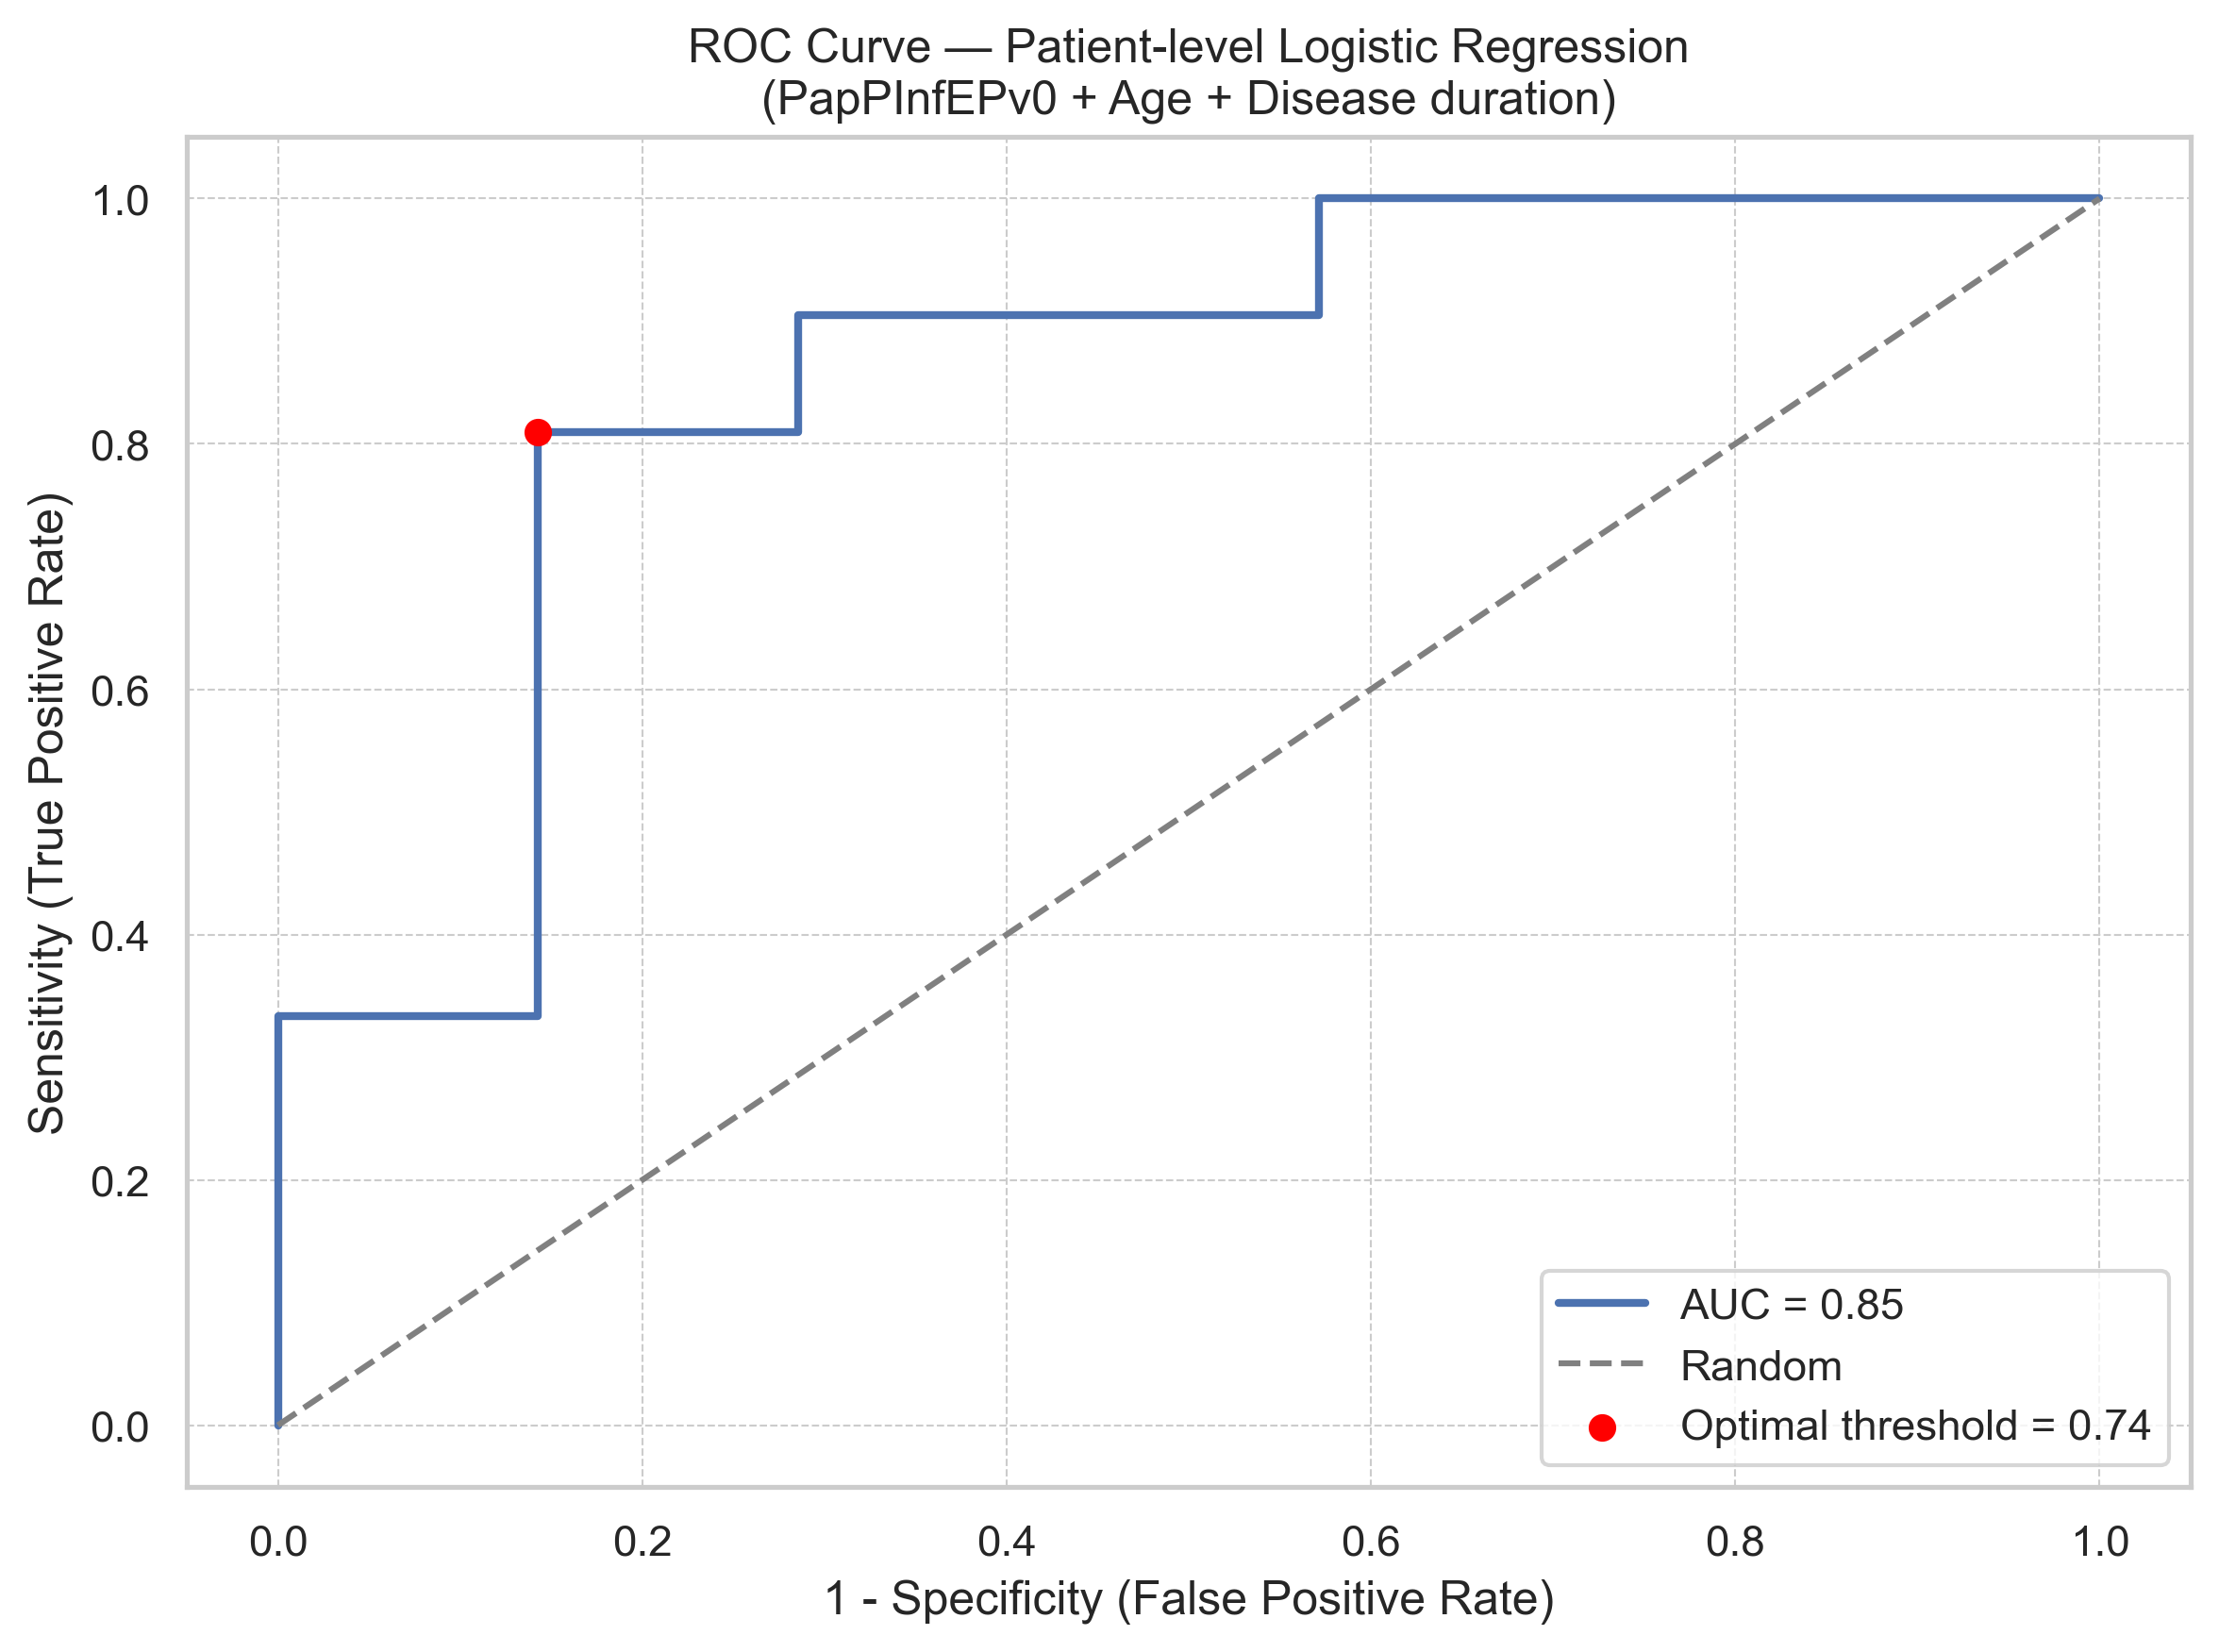

Saved: figures/roc_focus_PapPInfEPv0.png

=== Confusion @ threshold=0.50 (0p50) — PATIENT-LEVEL ===
Accuracy: 0.786
[[ 3  4]
 [ 2 19]] (sum=28)
Saved: data/derived/confusion_focus_0p50_patient.csv

=== Confusion @ threshold=0.74 (optimal) — PATIENT-LEVEL ===
Accuracy: 0.821
[[ 6  1]
 [ 4 17]] (sum=28)
Saved: data/derived/confusion_focus_optimal_patient.csv


In [23]:
"""
ROC/AUC for the focused *patient-level* model (PapPInfEPv0 + Edad + AñosSx).
- Forces eye→patient aggregation (mean for X/covariates; max for binary outcome).
- Computes ROC, AUC, Youden's J optimal cutoff, and confusion matrices
  at 0.50 and at the optimal threshold.
- Saves the ROC figure and both confusion matrices.
NOTE: This is apparent performance (in-sample). Use CV/holdout for unbiased estimates.
"""

# ---------------- config & helpers ----------------
ID_COL    = "PatientID"
OUTCOME   = "progression_composite"
VAR       = "PapPInfEPv0"
COVARS    = ["Edad", "AñosSx"]

OUT_FIGS    = globals().get("OUT_FIGS", "figures")
OUT_DERIVED = globals().get("OUT_DERIVED", "data/derived")
os.makedirs(OUT_FIGS, exist_ok=True)
os.makedirs(OUT_DERIVED, exist_ok=True)

def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")

def to_patient_level(frame: pd.DataFrame, var: str, covars: list[str], outcome: str) -> pd.DataFrame:
    """Aggregate eyes → one row per patient: mean for predictors/covars; max for binary outcome."""
    g = frame.copy()
    if g.index.name == ID_COL and ID_COL not in g.columns:
        g = g.reset_index()

    needed = [c for c in [ID_COL, var, outcome] + covars if c in g.columns]
    if ID_COL not in needed:
        raise KeyError(f"'{ID_COL}' not found. Ensure your de-identification cell created it.")
    if var not in needed:      raise KeyError(f"'{var}' not found in the DataFrame.")
    if outcome not in needed:  raise KeyError(f"Outcome '{outcome}' not found in the DataFrame.")

    # numeric coercion for model vars (NOT for the ID)
    for c in [var, outcome] + covars:
        if c in g.columns:
            g[c] = pd.to_numeric(g[c], errors="coerce")

    agg = {c: "mean" for c in [var] + covars}
    agg[outcome] = "max"
    gp = (g[needed].groupby(ID_COL, as_index=False, dropna=False).agg(agg))

    if gp[ID_COL].duplicated().any():
        raise ValueError("Patient-level table still has duplicate PatientIDs.")
    return gp

# ---------------- build patient-level design ----------------
# Prefer an existing patient-level table if already built
if "df_grouped" in globals() and {VAR, OUTCOME, *COVARS}.issubset(df_grouped.columns):
    df_pat = df_grouped[[ID_COL, VAR, *COVARS, OUTCOME]].copy()
else:
    df_pat = to_patient_level(df, VAR, COVARS, OUTCOME)

dm = df_pat[[c for c in [VAR] + COVARS + [OUTCOME] if c in df_pat.columns]].dropna()
if dm[OUTCOME].nunique() < 2:
    raise ValueError("Outcome has a single class after NA removal; cannot compute ROC at patient level.")

y_true_pat = dm[OUTCOME].astype(int)
X_pat = sm.add_constant(dm[[c for c in [VAR] + COVARS if c in dm.columns]], has_constant="add")

# ---------------- fit (or refit) focused model at patient level --------------
# We fit anew to be 100% sure this is patient-level.
try:
    model_focus_pat = sm.Logit(y_true_pat, X_pat).fit(disp=False, maxiter=200)
except Exception:
    model_focus_pat = sm.Logit(y_true_pat, X_pat).fit_regularized(disp=False)

y_prob_pat = model_focus_pat.predict(X_pat)

print(f"[PATIENT-LEVEL] N patients used: {len(dm)}")

# ---------------- ROC / AUC / Youden J --------------------------------------
fpr, tpr, thr = roc_curve(y_true_pat, y_prob_pat)
auc = roc_auc_score(y_true_pat, y_prob_pat)

j_scores = tpr - fpr
j_idx    = int(np.argmax(j_scores))
thr_opt  = float(thr[j_idx])
tpr_opt  = float(tpr[j_idx])
fpr_opt  = float(fpr[j_idx])

# ---------------- plot -------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.scatter(fpr_opt, tpr_opt, color="red", zorder=10, label=f"Optimal threshold = {thr_opt:.2f}")

plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve — Patient-level Logistic Regression\n(PapPInfEPv0 + Age + Disease duration)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()

roc_path = f"{OUT_FIGS}/roc_focus_{safe_name(VAR)}.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", roc_path)

# ---------------- confusion matrices (0.50 and optimal) ----------------------
for thr_use, tag in [(0.50, "0p50"), (thr_opt, "optimal")]:
    y_pred = (y_prob_pat >= thr_use).astype(int)
    acc = accuracy_score(y_true_pat, y_pred)
    cm  = confusion_matrix(y_true_pat, y_pred)

    print(f"\n=== Confusion @ threshold={thr_use:.2f} ({tag}) — PATIENT-LEVEL ===")
    print("Accuracy:", f"{acc:.3f}")
    print(cm, f"(sum={cm.sum()})")

    cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
    cm_path = f"{OUT_DERIVED}/confusion_focus_{tag}_patient.csv"
    cm_df.to_csv(cm_path)
    print("Saved:", cm_path)

<!-- (Eye-level) t-test for PapPInfEPv0 (optional) -->
<div id="ttest-eye" class="toc-anchor"></div>

## (Eye-level) t-test for PapPInfEPv0 (optional)

In [24]:
"""
Two-sample t-test for PapPInfEPv0 by progression status at the EYE level (raw df).
If you prefer patient-level consistency, rerun with df_grouped instead of df.
"""

if "PapPInfEPv0" in df.columns and "progression_composite" in df.columns:
    g0 = to_num(df.loc[df["progression_composite"] == 0, "PapPInfEPv0"]).dropna()
    g1 = to_num(df.loc[df["progression_composite"] == 1, "PapPInfEPv0"]).dropna()
    if len(g0) > 1 and len(g1) > 1:
        stat, p = ttest_ind(g0, g1, equal_var=False)
        print(f"T-test (eye-level) PapPInfEPv0: p = {p:.4f} (Welch)")
    else:
        print("Not enough data for t-test at eye level.")
else:
    print("Required columns not found in df for t-test.")

T-test (eye-level) PapPInfEPv0: p = 0.0076 (Welch)


<!-- Logistic curve: probability vs PapPInfEPv0 -->
<div id="curve" class="toc-anchor"></div>

## Logistic curve: probability vs PapPInfEPv0 (holding covariates at mean)

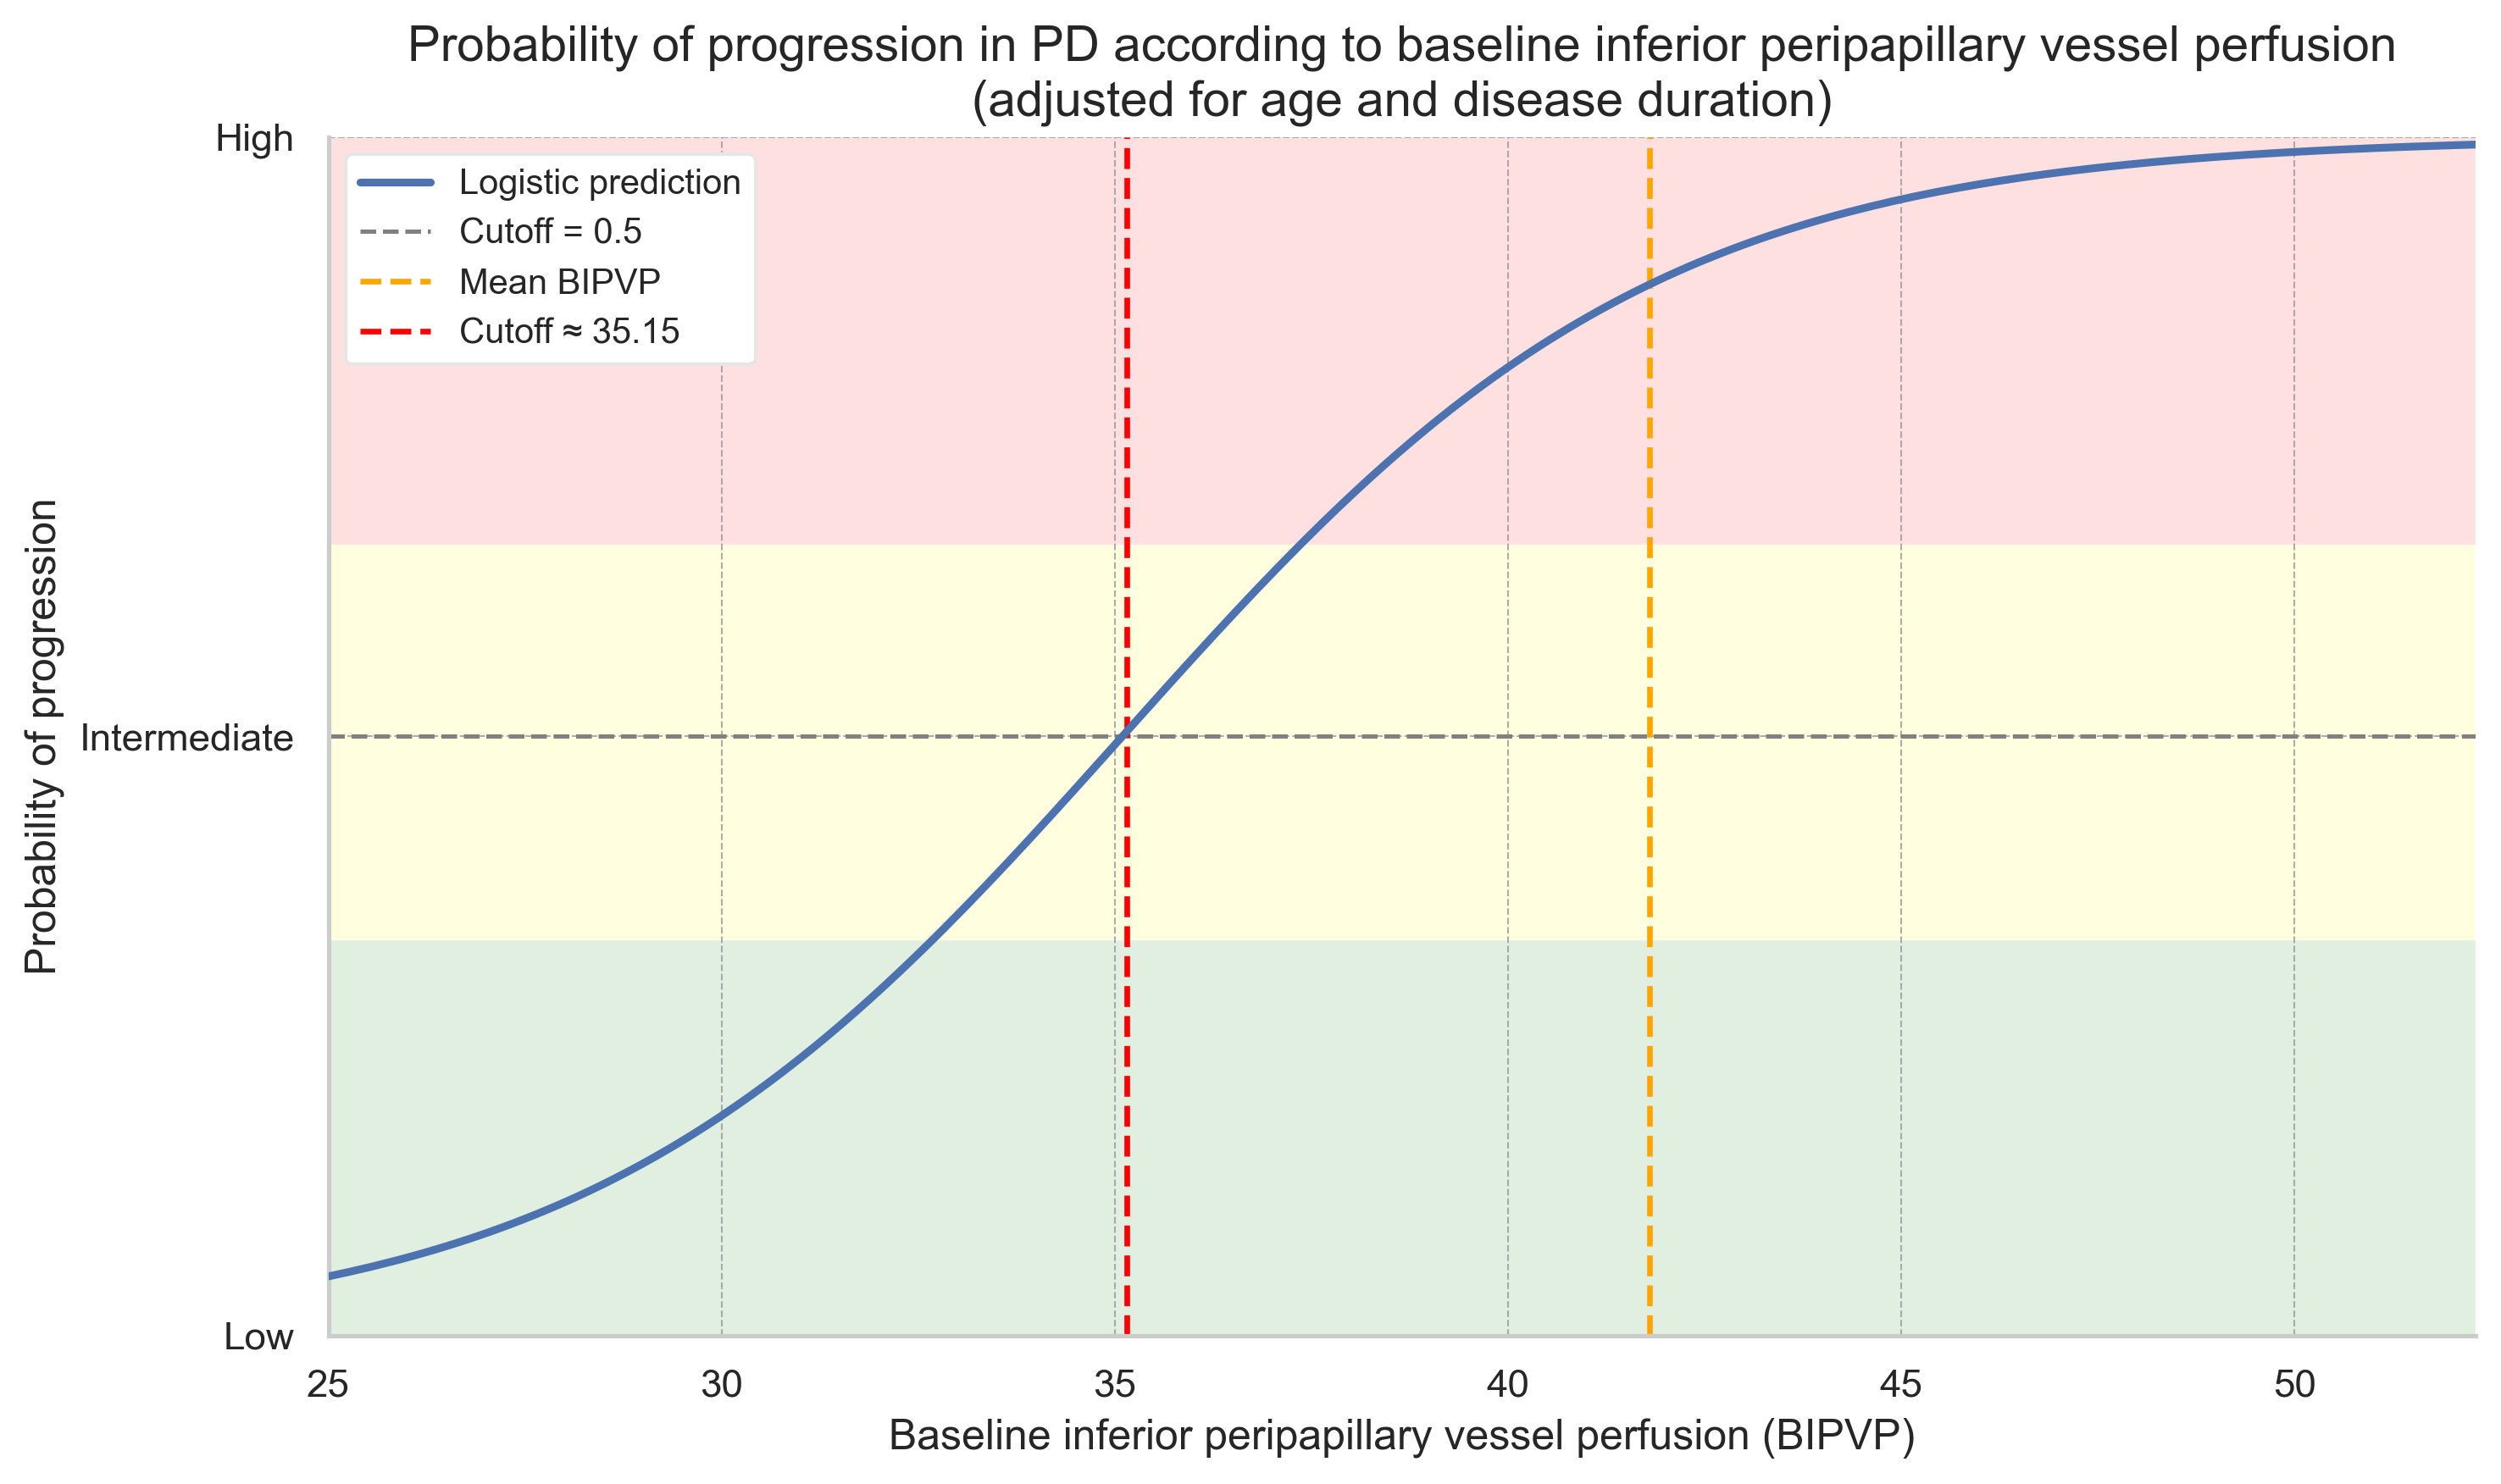

Saved: figures/logistic_curve_PapPInfEPv0.png


In [25]:
"""
Logistic curve (patient-level) for PapPInfEPv0 adjusted by Age (Edad) and disease duration (AñosSx).

What this does
--------------
- Guarantees patient-level data (eyes -> patient aggregation).
- Fits/uses a focused Logit: progression_composite ~ PapPInfEPv0 + Edad + AñosSx.
- Predicts probabilities across the observed range of PapPInfEPv0.
- Marks the 0.5 horizontal cutoff, the mean of the predictor, and the x where p≈0.5.
- Saves a publication-style figure to OUT_FIGS.
"""

# -------------------- config --------------------
ID_COL   = "PatientID"
OUTCOME  = "progression_composite"
VAR      = "PapPInfEPv0"
COVARS   = ["Edad", "AñosSx"]
OUT_FIGS = globals().get("OUT_FIGS", "figures")
os.makedirs(OUT_FIGS, exist_ok=True)

def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")

def to_patient_level(frame: pd.DataFrame, var: str, covars: list[str], outcome: str) -> pd.DataFrame:
    """
    Aggregate eyes -> patient:
      - predictors/covariates: mean
      - outcome (binary): max
    """
    g = frame.copy()
    # If PatientID lives in the index, move it to a column
    if g.index.name == ID_COL and ID_COL not in g.columns:
        g = g.reset_index()

    needed = [c for c in [ID_COL, var, outcome] + covars if c in g.columns]
    if ID_COL not in needed:   raise KeyError(f"'{ID_COL}' not found; run de-identification first.")
    if var not in needed:      raise KeyError(f"'{var}' not found in DataFrame.")
    if outcome not in needed:  raise KeyError(f"Outcome '{outcome}' not found in DataFrame.")

    # Numeric coercion for model variables (NOT for the ID)
    for c in [var, outcome] + covars:
        if c in g.columns:
            g[c] = pd.to_numeric(g[c], errors="coerce")

    agg = {c: "mean" for c in [var] + covars}
    agg[outcome] = "max"
    gp = g[needed].groupby(ID_COL, as_index=False, dropna=False).agg(agg)

    if gp[ID_COL].duplicated().any():
        raise ValueError("Patient-level table still has duplicate PatientIDs.")
    return gp

# -------------------- obtain patient-level table --------------------
# Prefer an existing patient-level table if already built
if "df_grouped" in globals() and {VAR, OUTCOME, *COVARS}.issubset(df_grouped.columns):
    df_pat = df_grouped[[ID_COL, VAR, *COVARS, OUTCOME]].copy()
else:
    df_pat = to_patient_level(df, VAR, COVARS, OUTCOME)

# Modeling data (complete cases)
dm = df_pat[[c for c in [VAR] + COVARS + [OUTCOME] if c in df_pat.columns]].dropna()
if dm.empty:
    raise ValueError("No complete cases for the focused model.")
# Outcome must be binary with both classes present
if dm[OUTCOME].nunique() < 2:
    raise ValueError("Outcome has a single class after NA removal; cannot fit the focused model.")

# -------------------- fit (or reuse) model --------------------
# If you already fit `model_focus` earlier *on patient-level*, we can reuse it;
# otherwise, fit here to be self-contained.
reuse = "model_focus" in globals()
if reuse:
    try:
        reuse = {"const", VAR, *COVARS}.issubset(set(model_focus.params.index))
    except Exception:
        reuse = False

if not reuse:
    y = dm[OUTCOME].astype(int)
    X = sm.add_constant(dm[[VAR] + [c for c in COVARS if c in dm.columns]], has_constant="add")
    try:
        model_focus = sm.Logit(y, X).fit(disp=False, maxiter=200)
    except Exception:
        # Separation fallback
        model_focus = sm.Logit(y, X).fit_regularized(disp=False)

# -------------------- prediction grid --------------------
x_min = 25.0                                                     # <- start X at 25
x_max = float(dm[VAR].max())
if x_max <= x_min:                                               # guard in case data min/max are tight
    x_max = x_min + 1.0

x_vals = np.linspace(x_min, x_max, 200)
#x_vals = np.linspace(float(dm[VAR].min()), float(dm[VAR].max()), 200)
X_mean = dm[COVARS].mean()

X_plot = pd.DataFrame({"const": 1.0, VAR: x_vals, **{c: X_mean[c] for c in COVARS}})
# Ensure column order matches the fitted model
X_plot = X_plot[model_focus.params.index]

y_hat = model_focus.predict(X_plot)

# -------------------- figure --------------------
# Clamp probabilities to [0,1] for numerical safety
y_hat_plot = np.clip(y_hat, 0, 1)
mean_val   = float(dm[VAR].mean())
idx_cut    = int(np.argmin(np.abs(y_hat_plot - 0.5)))
x_cut      = float(x_vals[idx_cut])

fig, ax = plt.subplots(figsize=(10, 6))

# Background probability bands
ax.axhspan(0.00, 0.33, facecolor='green',  alpha=0.12, zorder=0)
ax.axhspan(0.33, 0.66, facecolor='yellow', alpha=0.12, zorder=0)
ax.axhspan(0.66, 1.00, facecolor='red',    alpha=0.12, zorder=0)

# Logistic curve
ax.plot(x_vals, y_hat_plot, linewidth=2.2, label="Logistic prediction", zorder=3)

# Guides
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label="Cutoff = 0.5", zorder=1)
ax.axvline(mean_val, color='orange', linestyle='--', linewidth=1.6, label="Mean BIPVP", zorder=2)
ax.axvline(x_cut,    color='red',    linestyle='--', linewidth=1.6, label=f"Cutoff ≈ {x_cut:.2f}", zorder=2)

# Axes & labels
ax.set_xlim(float(x_vals.min()), float(x_vals.max()))
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["Low", "Intermediate", "High"])
ax.set_xlabel("Baseline inferior peripapillary vessel perfusion (BIPVP)", fontsize=12)
ax.set_ylabel("Probability of progression", fontsize=12)
ax.set_title(
    "Probability of progression in PD according to baseline inferior peripapillary vessel perfusion\n"
    "(adjusted for age and disease duration)",
    fontsize=14
)

# Style
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='0.6', alpha=0.8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
leg = ax.legend(loc="upper left", fontsize=10, frameon=True)
leg.get_frame().set_edgecolor("0.9")
leg.get_frame().set_alpha(1.0)

plt.tight_layout()
fig_path = f"{OUT_FIGS}/logistic_curve_{safe_name(VAR)}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", fig_path)